# COMP0264 GenAI Coursework - Group 4

**Group members:**
1. Guotong Ma zczqgm1@ucl.ac.uk
2. Bangxu Tian zczqbt1@ucl.ac.uk
3. Qingqing Liu zczqq26@ucl.ac.uk 
4. Letian Zhang zczql34@ucl.ac.uk
5. Feiyang Hu zcqshux@ucl.ac.uk
6. Yuan Ji ucabjid@ucl.ac.uk

# PartA Q1

In [2]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
PartA_Q1 Baseline Inference Recorder (COMP0264 style)

Part A - Q1: Baseline Inference

Required by coursework:
1. Load the base model
2. Create a prompt template suitable for the model
3. Run 3 inference examples

Deliverable:
- Report memory usage (VRAM)
- Report generated text
"""

import os
import json
import time
import platform
from datetime import datetime
from typing import Dict, List, Any

import torch
import pandas as pd
from transformers import AutoTokenizer, AutoModelForCausalLM


# -----------------------------
# User settings
# -----------------------------
MODEL_PATH = "/workspace/tbx/Llama-3.2-3B-Instruct/"

QUESTIONS = [
    "who sang what in the world's come over you",
    "where did they film diary of a wimpy kid",
    "when did fosters home for imaginary friends start",
]

GEN_CONFIG = {
    "max_new_tokens": 128,
    "temperature": 0.0,   # deterministic baseline
    "top_p": 1.0,
}

OUT_ROOT = "./PartA_Q1_outputs"   # renamed from Q1_records


# -----------------------------
# Helpers
# -----------------------------
def ensure_dir(path: str) -> None:
    os.makedirs(path, exist_ok=True)


def get_env_info() -> Dict[str, Any]:
    info = {
        "timestamp_utc": datetime.utcnow().strftime("%Y-%m-%d %H:%M:%S"),
        "python": platform.python_version(),
        "platform": platform.platform(),
        "torch_version": torch.__version__,
        "cuda_available": torch.cuda.is_available(),
    }

    try:
        import transformers
        info["transformers_version"] = transformers.__version__
    except Exception:
        info["transformers_version"] = "unknown"

    if torch.cuda.is_available():
        info.update({
            "cuda_device_count": torch.cuda.device_count(),
            "cuda_device_name_0": torch.cuda.get_device_name(0),
            "cuda_capability_0": torch.cuda.get_device_capability(0),
            "cuda_total_vram_mb_0": round(
                torch.cuda.get_device_properties(0).total_memory / (1024**2), 1
            ),
        })
    return info


def build_messages(question: str) -> List[Dict[str, str]]:
    """
    Prompt template suitable for an instruction-tuned chat model.
    """
    system = (
        "You are a helpful assistant. Answer the user's question accurately, "
        "concisely, and factually. If you are unsure, say so briefly."
    )
    user = f"Question: {question}"
    return [
        {"role": "system", "content": system},
        {"role": "user", "content": user},
    ]


def get_prompt_template_description() -> str:
    return (
        "Prompt template used for PartA_Q1 baseline inference:\n"
        "- System role: instructs the model to answer accurately, concisely, and factually\n"
        "- User role: provides the question in the format 'Question: <text>'\n"
        "- Chat template: tokenizer.apply_chat_template(..., add_generation_prompt=True)"
    )


@torch.no_grad()
def run_one(
    model,
    tokenizer,
    question: str,
    max_new_tokens: int = 128,
    temperature: float = 0.0,
    top_p: float = 1.0,
) -> Dict[str, Any]:
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

    messages = build_messages(question)
    prompt_text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(prompt_text, return_tensors="pt")
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    do_sample = temperature > 0.0

    t0 = time.time()
    outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=do_sample,
        temperature=temperature if do_sample else None,
        top_p=top_p if do_sample else None,
        pad_token_id=tokenizer.eos_token_id,
    )
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t1 = time.time()

    gen_ids = outputs[0][inputs["input_ids"].shape[-1]:]
    gen_text = tokenizer.decode(gen_ids, skip_special_tokens=True).strip()

    peak_vram_mb = None
    if torch.cuda.is_available():
        peak_vram_mb = round(torch.cuda.max_memory_allocated() / (1024**2), 2)

    return {
        "question": question,
        "prompt": prompt_text,
        "prompt_preview_400": prompt_text[:400] + ("..." if len(prompt_text) > 400 else ""),
        "generated_text": gen_text,
        "latency_s": round(t1 - t0, 4),
        "peak_vram_mb": peak_vram_mb,
    }


def write_json(path: str, obj: Any) -> None:
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)


def write_jsonl(path: str, rows: List[Dict[str, Any]]) -> None:
    with open(path, "w", encoding="utf-8") as f:
        for r in rows:
            f.write(json.dumps(r, ensure_ascii=False) + "\n")


def write_text(path: str, text: str) -> None:
    with open(path, "w", encoding="utf-8") as f:
        f.write(text)


# -----------------------------
# Main
# -----------------------------
def main():
    # Create output folder
    run_id = datetime.utcnow().strftime("PartA_Q1_%Y%m%d_%H%M%S_UTC")
    out_dir = os.path.join(OUT_ROOT, run_id)
    ensure_dir(out_dir)

    # Save environment + config
    env_info = get_env_info()
    config = {
        "coursework_part": "Part A",
        "question": "Q1",
        "question_title": "Baseline Inference",
        "model_path": MODEL_PATH,
        "questions": QUESTIONS,
        "generation_config": GEN_CONFIG,
        "deliverable": [
            "Report the memory usage (VRAM)",
            "Report the generated text"
        ],
        "notes": "Baseline inference to verify the base model runs correctly on available hardware."
    }
    write_json(os.path.join(out_dir, "env_info.json"), env_info)
    write_json(os.path.join(out_dir, "run_config.json"), config)
    write_text(os.path.join(out_dir, "prompt_template.txt"), get_prompt_template_description())

    # Load tokenizer/model
    tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, use_fast=True)

    if torch.cuda.is_available() and torch.cuda.get_device_capability(0)[0] >= 8:
        dtype = torch.bfloat16
    else:
        dtype = torch.float16

    model = AutoModelForCausalLM.from_pretrained(
        MODEL_PATH,
        torch_dtype=dtype,
        device_map="auto",
    )
    model.eval()

    # Run 3 inference examples
    results = []
    for q in QUESTIONS:
        r = run_one(
            model=model,
            tokenizer=tokenizer,
            question=q,
            max_new_tokens=GEN_CONFIG["max_new_tokens"],
            temperature=GEN_CONFIG["temperature"],
            top_p=GEN_CONFIG["top_p"],
        )
        results.append(r)

    # Save raw results
    write_jsonl(os.path.join(out_dir, "partA_q1_results.jsonl"), results)

    # Save summary CSV focused on deliverable
    df = pd.DataFrame([{
        "question": r["question"],
        "generated_text": r["generated_text"],
        "latency_s": r["latency_s"],
        "peak_vram_mb": r["peak_vram_mb"],
    } for r in results])
    df.to_csv(
        os.path.join(out_dir, "partA_q1_results.csv"),
        index=False,
        encoding="utf-8"
    )

    # Save a concise markdown report for notebook / PDF export support
    lines = []
    lines.append("# Part A - Q1: Baseline Inference\n")
    lines.append(f"- **Run ID:** `{run_id}`")
    lines.append(f"- **Model path:** `{MODEL_PATH}`")
    lines.append(f"- **Dtype:** `{str(dtype)}`")
    lines.append(f"- **Generation config:** `{GEN_CONFIG}`\n")

    lines.append("## What was done\n")
    lines.append("1. Loaded the base model.")
    lines.append("2. Created a prompt template suitable for the chat model.")
    lines.append("3. Ran 3 inference examples.\n")

    lines.append("## Deliverable required by Q1\n")
    lines.append("- Memory usage (VRAM)")
    lines.append("- Generated text\n")

    lines.append("## Environment\n")
    for k, v in env_info.items():
        lines.append(f"- **{k}**: {v}")

    lines.append("\n## Prompt template\n")
    lines.append("```")
    lines.append(get_prompt_template_description())
    lines.append("```")

    lines.append("\n## Summary table\n")
    lines.append(df.to_markdown(index=False))

    lines.append("\n## Per-example outputs\n")
    for i, r in enumerate(results, 1):
        pv = "N/A" if r["peak_vram_mb"] is None else f"{r['peak_vram_mb']:.2f}"
        lines.append(f"\n### Example {i}\n")
        lines.append(f"**Question:** {r['question']}\n")
        lines.append(f"**Peak VRAM (MB):** {pv}\n")
        lines.append(f"**Latency (s):** {r['latency_s']:.4f}\n")
        lines.append("**Generated text:**")
        lines.append("```")
        lines.append(r["generated_text"])
        lines.append("```")

    write_text(os.path.join(out_dir, "PartA_Q1_report.md"), "\n".join(lines))

    # Save full prompts separately for auditability
    prompts_dir = os.path.join(out_dir, "prompts_full")
    ensure_dir(prompts_dir)
    for idx, r in enumerate(results, 1):
        write_text(os.path.join(prompts_dir, f"partA_q1_prompt_{idx:02d}.txt"), r["prompt"])

    # Console printout aligned to coursework deliverable
    print("=" * 90)
    print("COMP0264 - Part A - Q1: Baseline Inference")
    print("=" * 90)
    print(f"Output folder: {out_dir}")
    print(f"Model: {MODEL_PATH}")
    print(f"Dtype: {dtype}")
    print()

    print("Deliverable for submission:")
    print("1. Memory usage (VRAM)")
    print("2. Generated text")
    print()

    for i, r in enumerate(results, 1):
        pv = "N/A" if r["peak_vram_mb"] is None else f"{r['peak_vram_mb']:.2f} MB"
        print(f"[Example {i}]")
        print(f"Question      : {r['question']}")
        print(f"Peak VRAM     : {pv}")
        print(f"Latency       : {r['latency_s']:.4f} s")
        print(f"Generated text: {r['generated_text']}")
        print("-" * 90)

    print("Files created:")
    print(" - env_info.json")
    print(" - run_config.json")
    print(" - prompt_template.txt")
    print(" - partA_q1_results.jsonl")
    print(" - partA_q1_results.csv")
    print(" - PartA_Q1_report.md")
    print(" - prompts_full/partA_q1_prompt_*.txt")
    print("=" * 90)


if __name__ == "__main__":
    main()

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

COMP0264 - Part A - Q1: Baseline Inference
Output folder: ./PartA_Q1_outputs/PartA_Q1_20260320_164354_UTC
Model: /workspace/tbx/Llama-3.2-3B-Instruct/
Dtype: torch.bfloat16

Deliverable for submission:
1. Memory usage (VRAM)
2. Generated text

[Example 1]
Question      : who sang what in the world's come over you
Peak VRAM     : 1901.37 MB
Latency       : 1.6258 s
Generated text: I couldn't find any information on a well-known song called "The World's Come Over You." Could you provide more context or details about the song, such as the genre, era, or artist?
------------------------------------------------------------------------------------------
[Example 2]
Question      : where did they film diary of a wimpy kid
Peak VRAM     : 1901.39 MB
Latency       : 0.8482 s
Generated text: The Diary of a Wimpy Kid film series was primarily filmed in Vancouver, British Columbia, Canada.
------------------------------------------------------------------------------------------
[Example 3]
Questi

# PartA Q2

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Adding EOS to train dataset:   0%|          | 0/648 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/648 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/648 [00:00<?, ? examples/s]

...

Truncating eval dataset:   0%|          | 0/72 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009, 'pad_token_id': 128009}.


{'loss': '3.748', 'grad_norm': '2.419', 'learning_rate': '6e-05', 'entropy': '1.65', 'num_tokens': '3472', 'mean_token_accuracy': '0.4953', 'epoch': '0.06173'}
{'loss': '2.945', 'grad_norm': '2.156', 'learning_rate': '0.0001267', 'entropy': '1.848', 'num_tokens': '6949', 'mean_token_accuracy': '0.5627', 'epoch': '0.1235'}
{'loss': '1.609', 'grad_norm': '1.517', 'learning_rate': '0.0001933', 'entropy': '1.533', 'num_tokens': '1.04e+04', 'mean_token_accuracy': '0.7398', 'epoch': '0.1852'}
{'loss': '0.863', 'grad_norm': '0.8082', 'learning_rate': '0.0001961', 'entropy': '0.8969', 'num_tokens': '1.388e+04', 'mean_token_accuracy': '0.8807', 'epoch': '0.2469'}
{'loss': '0.7546', 'grad_norm': '0.7445', 'learning_rate': '0.0001917', 'entropy': '0.7332', 'num_tokens': '1.737e+04', 'mean_token_accuracy': '0.8851', 'epoch': '0.3086'}
{'eval_loss': '0.7483', 'eval_runtime': '1.921', 'eval_samples_per_second': '37.47', 'eval_steps_per_second': '9.368', 'eval_entropy': '0.6895', 'eval_num_tokens': '

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
Caching is incompatible with gradient checkpointing in LlamaDecoderLayer. Setting `past_key_values=None`.


{'train_runtime': '214.4', 'train_samples_per_second': '9.069', 'train_steps_per_second': '2.267', 'train_loss': '0.6935', 'entropy': '0.442', 'num_tokens': '1.686e+05', 'mean_token_accuracy': '0.9153', 'epoch': '3'}


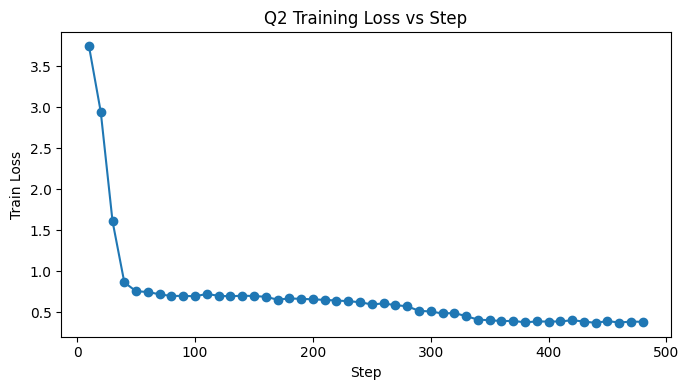

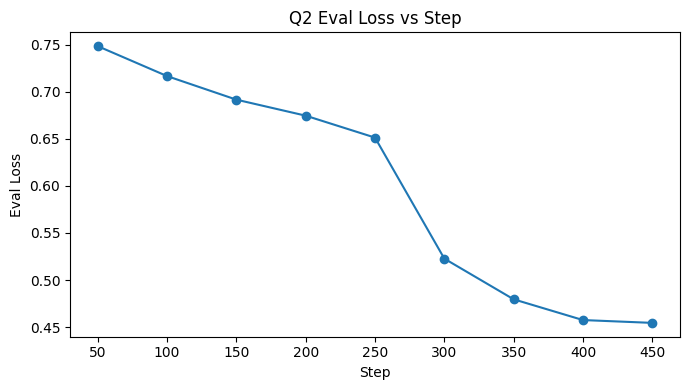

## Q2 Deliverable 1: Training Loss vs Steps

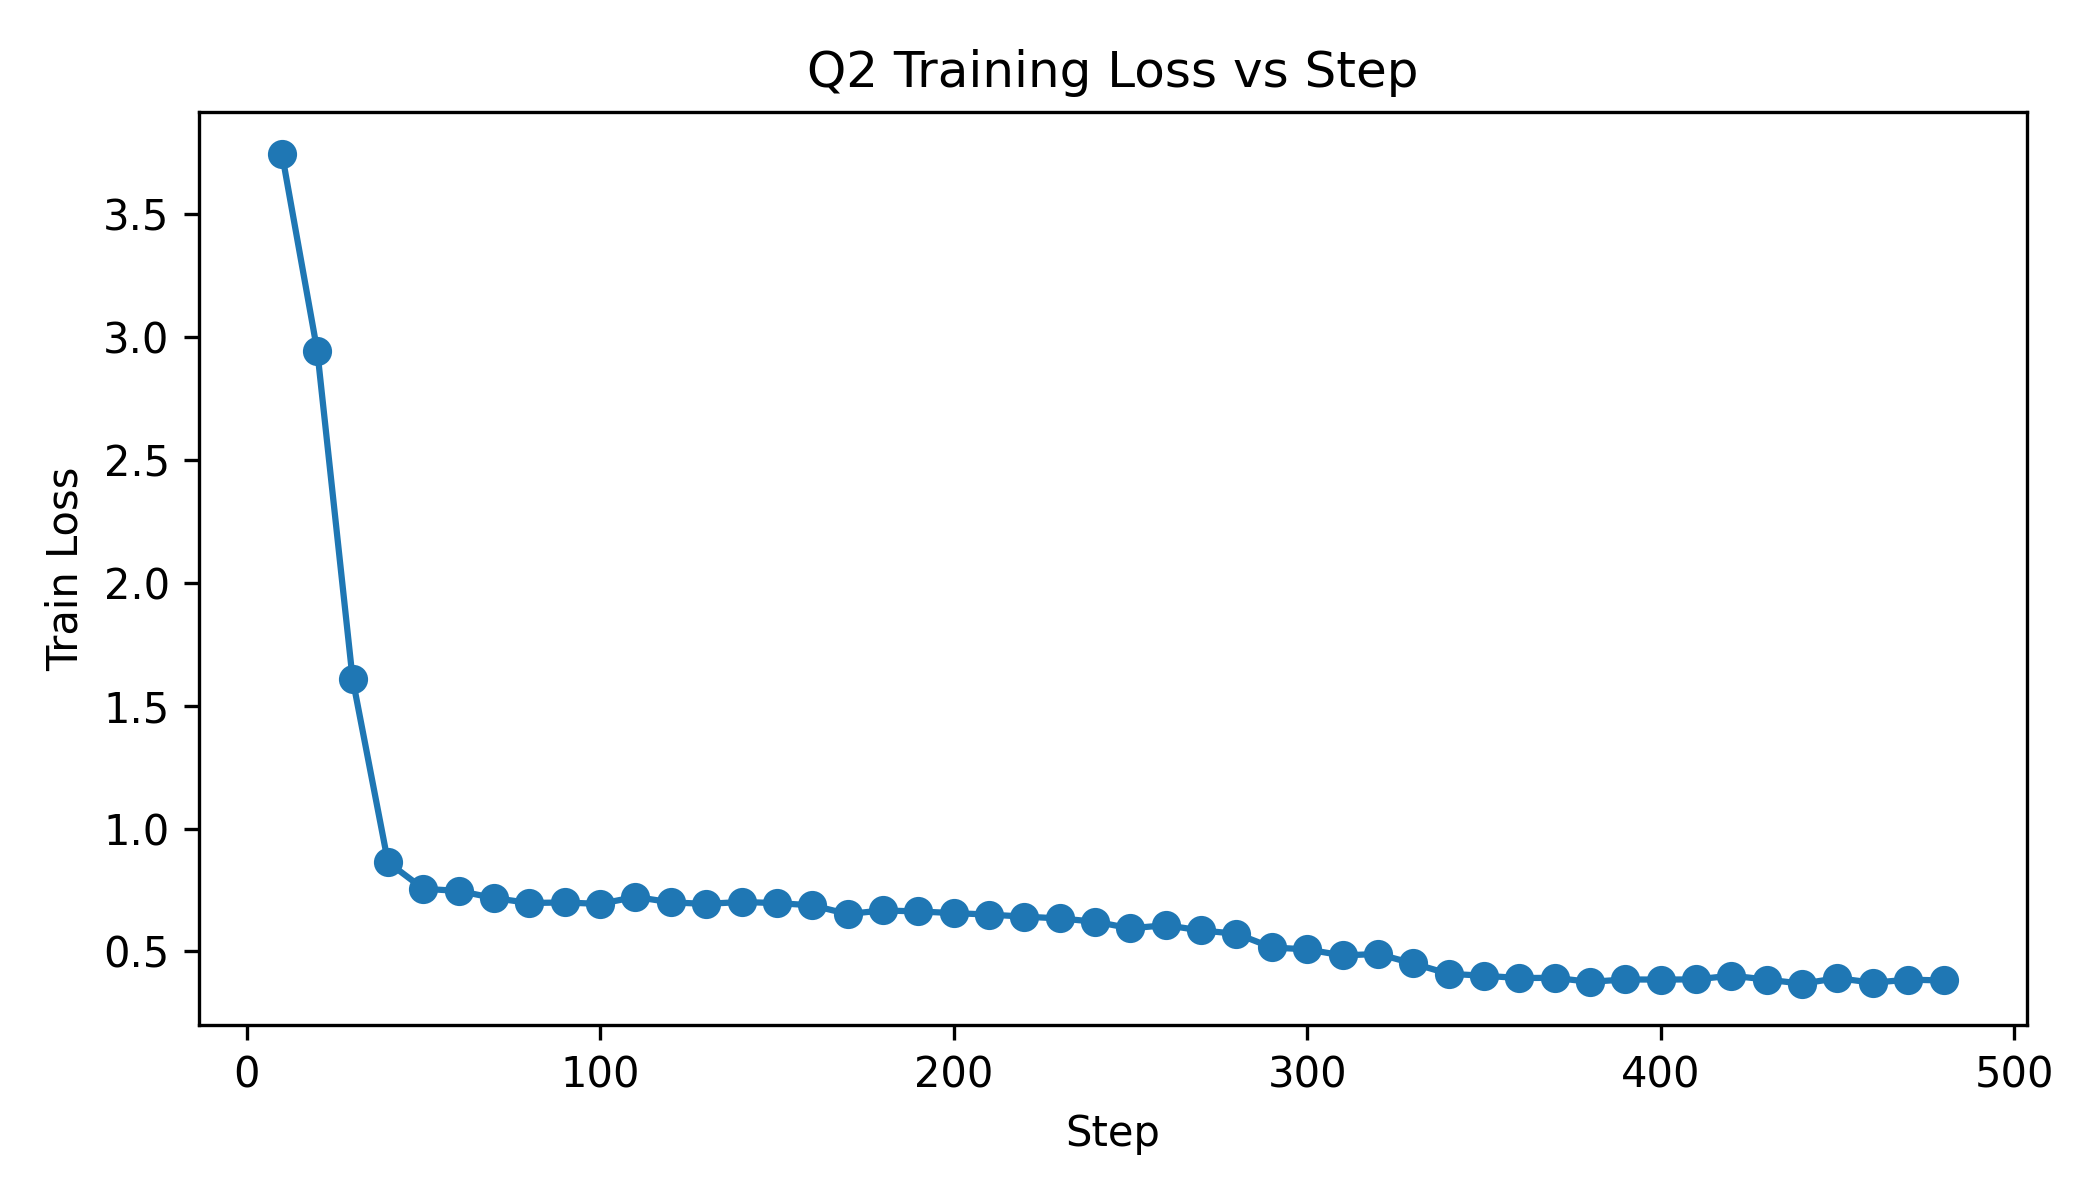

## Q2 Deliverable 2: Three Examples Before vs After SFT

### Example 1
**English:** Although I was tired after work, I still went to the gym because I promised myself I would stay consistent.

**Before SFT:**

```
"A tired, I was, after work, but to the gym, I went, I did, a promise to myself, keep, I must."
```

**After SFT:**

```
After of question of question of question of question of question of question of question of Question of question of question of question of question of question of question of question of question of question of question of question of question of question of question of question of question of Question of question of Question of question of question of question of question of question of question of question of question of question of question of question of Question of
```

### Example 2
**English:** If you finish the report by Friday, we can submit it early and avoid last-minute mistakes.

**Before SFT:**

```
"Early submit, we can, if by Friday finished, the report, you are."
```

**After SFT:**

```
By of Question of question of question of question of question of question of question of question of question of question of question of question of question of question of question of question of question of question of question of question of question of question of question of Question of question of question of question of question of question of question of question of question of question of question of question of question of question of question of Question of
```

### Example 3
**English:** The results look promising; however, we should double-check the evaluation protocol before drawing conclusions.

**Before SFT:**

```
"A promising, the results look; double-check the evaluation protocol, we must, before conclusions drawn, we can."
```

**After SFT:**

```
Prom
```


Q2 DONE. Records saved to:
./Q2_records/Q2_20260320_174507_UTC


In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
Q2 - LoRA Fine-tuning (SFT style) for Yoda Translation
Model: /workspace/tbx/Llama-3.2-3B-Instruct/
Dataset CSV: /workspace/tbx/yoda_sentences/sentences.csv

Records saved into: ./PartA_Q2_outputs/Q2_YYYYMMDD_HHMMSS_UTC/
- env.json
- run_config.json
- data_stats.json
- split.json
- lora_config.json
- train_time.json
- train_log_history.jsonl
- loss_curve.png
- eval_curve.png (if eval enabled)
- before_after.json
- demo_before_after.md
- report.md
- adapter/   (LoRA adapter + tokenizer)
"""

import os
import json
import time
import random
import platform
import inspect
import warnings
from datetime import datetime
from typing import Dict, List, Any

import torch
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown, Image

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling,
)

from peft import LoraConfig, get_peft_model


# =========================
# USER SETTINGS
# =========================
MODEL_PATH = "/workspace/tbx/Llama-3.2-3B-Instruct/"
CSV_PATH = "/workspace/tbx/yoda_sentences/sentences.csv"

OUT_ROOT = "./PartA_Q2_outputs"

SEED = 42
MAX_LENGTH = 256

TRAIN_RATIO = 0.9
USE_FIXED_SPLIT = False
TRAIN_SIZE = 500
VAL_SIZE = 200

EPOCHS = 3
LR = 2e-4
BATCH_SIZE = 4
GRAD_ACCUM = 1
LOGGING_STEPS = 10
EVAL_STEPS = 50

WARMUP_STEPS = 30

DEMO_MAX_NEW_TOKENS = 80
DEMO_TEMPERATURE = 0.0

DEMO_MODE = "hard"   # "hard" or "dataset"
DEMO_N = 3           # deliverable only needs 3 examples

os.environ["TOKENIZERS_PARALLELISM"] = "false"
warnings.filterwarnings("ignore")


# =========================
# JSON safety
# =========================
def sanitize_json(obj):
    if isinstance(obj, dict):
        return {k: sanitize_json(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [sanitize_json(x) for x in obj]
    if isinstance(obj, tuple):
        return [sanitize_json(x) for x in obj]
    if isinstance(obj, set):
        return sorted([sanitize_json(x) for x in obj])
    try:
        import numpy as np
        if isinstance(obj, (np.integer, np.floating)):
            return obj.item()
        if isinstance(obj, np.ndarray):
            return obj.tolist()
    except Exception:
        pass
    if isinstance(obj, torch.dtype):
        return str(obj)
    return obj


def ensure_dir(path: str) -> None:
    os.makedirs(path, exist_ok=True)


def write_json(path: str, obj: Any) -> None:
    with open(path, "w", encoding="utf-8") as f:
        json.dump(sanitize_json(obj), f, ensure_ascii=False, indent=2)


def write_jsonl(path: str, rows: List[Dict[str, Any]]) -> None:
    with open(path, "w", encoding="utf-8") as f:
        for r in rows:
            f.write(json.dumps(sanitize_json(r), ensure_ascii=False) + "\n")


# =========================
# Env / seed
# =========================
def get_env_info() -> Dict[str, Any]:
    info = {
        "timestamp_utc": datetime.utcnow().strftime("%Y-%m-%d %H:%M:%S"),
        "python": platform.python_version(),
        "platform": platform.platform(),
        "torch_version": torch.__version__,
        "cuda_available": torch.cuda.is_available(),
    }
    if torch.cuda.is_available():
        info.update({
            "cuda_device_count": torch.cuda.device_count(),
            "cuda_device_name_0": torch.cuda.get_device_name(0),
            "cuda_capability_0": torch.cuda.get_device_capability(0),
            "cuda_total_vram_mb_0": round(torch.cuda.get_device_properties(0).total_memory / (1024**2), 1),
        })
    return info


def set_seed(seed: int) -> None:
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


# =========================
# Prompt
# =========================
def build_messages(english_sentence: str) -> List[Dict[str, str]]:
    system = "You are a translator that converts English sentences into Yoda-style speech."
    user = (
        "Translate the following sentence into Yoda-style. "
        "Output only the translated sentence.\n\n"
        f"{english_sentence}"
    )
    return [
        {"role": "system", "content": system},
        {"role": "user", "content": user},
    ]


def build_prompt_text(tokenizer, english_sentence: str) -> str:
    return tokenizer.apply_chat_template(
        build_messages(english_sentence),
        tokenize=False,
        add_generation_prompt=True,
    )


# =========================
# Dataset (prompt masking)
# =========================
class YodaSFTDataset(torch.utils.data.Dataset):
    def __init__(self, tokenizer, df: pd.DataFrame, max_length: int):
        self.tokenizer = tokenizer
        self.df = df.reset_index(drop=True)
        self.max_length = max_length

        cols = list(self.df.columns)
        cols_set = set(cols)

        self.col_src = "sentence" if "sentence" in cols_set else cols[0]
        if "translation" in cols_set:
            self.col_tgt = "translation"
        elif "yoda_sentence" in cols_set:
            self.col_tgt = "yoda_sentence"
        elif "yoda" in cols_set:
            self.col_tgt = "yoda"
        else:
            self.col_tgt = cols[1] if len(cols) > 1 else cols[0]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        row = self.df.iloc[idx]
        src = str(row[self.col_src]).strip()
        tgt = str(row[self.col_tgt]).strip()

        prompt_text = build_prompt_text(self.tokenizer, src)
        full_text = prompt_text + tgt

        enc_prompt = self.tokenizer(
            prompt_text,
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt",
        )
        prompt_len = int(enc_prompt["input_ids"].shape[1])

        enc_full = self.tokenizer(
            full_text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt",
        )

        input_ids = enc_full["input_ids"][0]
        attention_mask = enc_full["attention_mask"][0]

        labels = input_ids.clone()
        labels[:prompt_len] = -100
        labels[attention_mask == 0] = -100

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels,
        }


# =========================
# Demo generation
# =========================
@torch.no_grad()
def generate_yoda(model, tokenizer, english_sentence: str) -> str:
    prompt_text = build_prompt_text(tokenizer, english_sentence)
    enc = tokenizer(prompt_text, return_tensors="pt").to(model.device)

    gen_kwargs = dict(
        max_new_tokens=DEMO_MAX_NEW_TOKENS,
        do_sample=(DEMO_TEMPERATURE > 0),
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )
    if DEMO_TEMPERATURE > 0:
        gen_kwargs["temperature"] = DEMO_TEMPERATURE

    out = model.generate(**enc, **gen_kwargs)
    gen_ids = out[0][enc["input_ids"].shape[-1]:]
    text = tokenizer.decode(gen_ids, skip_special_tokens=True).strip()
    text = text.split("\n")[0].strip()
    return text


def get_demo_inputs(df: pd.DataFrame) -> List[str]:
    hard = [
        "Although I was tired after work, I still went to the gym because I promised myself I would stay consistent.",
        "If you finish the report by Friday, we can submit it early and avoid last-minute mistakes.",
        "The results look promising; however, we should double-check the evaluation protocol before drawing conclusions.",
        "When I realized the meeting was cancelled, I used the extra time to review the paper and take notes.",
        "I don't think this approach will work, but I'm willing to try it if you can explain the reasoning clearly.",
        "This method is not only faster, but it is also more reliable in noisy environments.",
        "Because the dataset is imbalanced, the model tends to predict the majority class unless we use reweighting.",
        "The experiment failed twice, so we changed the learning rate and reduced the batch size.",
        "The training took 3 hours and 25 minutes, and the best validation loss was 0.47 at step 450.",
        "Please remind me to call my supervisor at 10:30 tomorrow morning and send the updated slides.",
        "She said, 'I will never give up,' even when everything seemed impossible.",
        "Honestly, I'm frustrated right now, but I know I can improve if I keep practicing.",
        "Summarize the key differences between supervised fine-tuning and reinforcement learning in two sentences.",
        "Explain why setting a padding token is necessary when we use padding='max_length' during tokenization.",
        "Not until I read the documentation carefully did I understand why the training kept crashing.",
    ]

    if DEMO_MODE == "dataset":
        if "sentence" not in df.columns:
            return hard[:DEMO_N]
        demo = df["sentence"].dropna().astype(str).sample(
            n=min(DEMO_N, len(df)),
            random_state=SEED
        ).tolist()
        return demo

    return hard[:DEMO_N]


def save_demo_markdown(path: str, demo_inputs: List[str], before: List[Dict[str, str]], after: List[Dict[str, str]]) -> None:
    md_lines = []
    md_lines.append("# Q2 Demo (Before vs After)\n")
    for i, s in enumerate(demo_inputs, 1):
        md_lines.append(f"## Example {i}")
        md_lines.append(f"**English:** {s}\n")
        md_lines.append("**Before:**")
        md_lines.append("```")
        md_lines.append(before[i-1]["yoda"])
        md_lines.append("```")
        md_lines.append("**After:**")
        md_lines.append("```")
        md_lines.append(after[i-1]["yoda"])
        md_lines.append("```")
        md_lines.append("")
    with open(path, "w", encoding="utf-8") as f:
        f.write("\n".join(md_lines))


# =========================
# TrainingArguments compatibility
# =========================
def make_training_args(out_dir: str, dtype: torch.dtype) -> TrainingArguments:
    sig = inspect.signature(TrainingArguments.__init__).parameters
    common = dict(
        output_dir=os.path.join(out_dir, "checkpoints"),
        num_train_epochs=EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        gradient_accumulation_steps=GRAD_ACCUM,
        learning_rate=LR,
        warmup_steps=WARMUP_STEPS,
        logging_steps=LOGGING_STEPS,
        eval_steps=EVAL_STEPS,
        save_strategy="no",
        report_to="none",
        fp16=(dtype == torch.float16),
        bf16=(dtype == torch.bfloat16),
        dataloader_pin_memory=True,
        disable_tqdm=True,
        logging_strategy="steps",
    )

    if "eval_strategy" in sig:
        common["eval_strategy"] = "steps"
    elif "evaluation_strategy" in sig:
        common["evaluation_strategy"] = "steps"

    return TrainingArguments(**common)


# =========================
# Main
# =========================
def main():
    set_seed(SEED)

    run_id = datetime.utcnow().strftime("Q2_%Y%m%d_%H%M%S_UTC")
    out_dir = os.path.join(OUT_ROOT, run_id)
    ensure_dir(out_dir)

    write_json(os.path.join(out_dir, "env.json"), get_env_info())
    write_json(os.path.join(out_dir, "run_config.json"), {
        "model_path": MODEL_PATH,
        "csv_path": CSV_PATH,
        "seed": SEED,
        "max_length": MAX_LENGTH,
        "epochs": EPOCHS,
        "lr": LR,
        "batch_size": BATCH_SIZE,
        "grad_accum": GRAD_ACCUM,
        "logging_steps": LOGGING_STEPS,
        "eval_steps": EVAL_STEPS,
        "warmup_steps": WARMUP_STEPS,
        "demo_mode": DEMO_MODE,
        "demo_n": DEMO_N,
        "notes": "Q2 LoRA SFT for Yoda translation; prompt masking; Jupyter submission version.",
    })

    df = pd.read_csv(CSV_PATH)
    write_json(os.path.join(out_dir, "data_stats.json"), {
        "num_rows": int(len(df)),
        "columns": list(df.columns),
        "head_preview": df.head(3).to_dict(orient="records"),
    })

    df = df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
    if USE_FIXED_SPLIT:
        train_df = df.iloc[:TRAIN_SIZE].copy()
        val_df = df.iloc[TRAIN_SIZE:TRAIN_SIZE + VAL_SIZE].copy()
    else:
        n_train = int(len(df) * TRAIN_RATIO)
        train_df = df.iloc[:n_train].copy()
        val_df = df.iloc[n_train:].copy()

    write_json(os.path.join(out_dir, "split.json"), {
        "train_size": int(len(train_df)),
        "val_size": int(len(val_df)),
        "use_fixed_split": USE_FIXED_SPLIT,
        "train_ratio": TRAIN_RATIO,
        "train_size_fixed": TRAIN_SIZE,
        "val_size_fixed": VAL_SIZE,
    })

    tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, use_fast=True)

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    assert tokenizer.pad_token_id is not None

    if torch.cuda.is_available():
        if torch.cuda.get_device_capability(0)[0] >= 8:
            dtype = torch.bfloat16
        else:
            dtype = torch.float16
    else:
        dtype = torch.float32

    model = AutoModelForCausalLM.from_pretrained(
        MODEL_PATH,
        torch_dtype=dtype,
        device_map="auto" if torch.cuda.is_available() else None,
    )
    model.eval()
    model.config.pad_token_id = tokenizer.pad_token_id

    lora_cfg = LoraConfig(
        r=16,
        lora_alpha=32,
        target_modules=["q_proj", "v_proj"],
        lora_dropout=0.05,
        bias="none",
        task_type="CAUSAL_LM",
    )
    write_json(os.path.join(out_dir, "lora_config.json"), lora_cfg.to_dict())

    model = get_peft_model(model, lora_cfg)

    train_ds = YodaSFTDataset(tokenizer, train_df, max_length=MAX_LENGTH)
    val_ds = YodaSFTDataset(tokenizer, val_df, max_length=MAX_LENGTH)

    args = make_training_args(out_dir, dtype)
    collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds if len(val_ds) > 0 else None,
        data_collator=collator,
    )

    # BEFORE
    demo_inputs = get_demo_inputs(df)
    before = [{"english": s, "yoda": generate_yoda(model, tokenizer, s)} for s in demo_inputs]

    # TRAIN
    t0 = time.time()
    trainer.train()
    t1 = time.time()
    write_json(os.path.join(out_dir, "train_time.json"), {"train_time_s": t1 - t0})

    # AFTER
    after = [{"english": s, "yoda": generate_yoda(model, tokenizer, s)} for s in demo_inputs]

    write_json(os.path.join(out_dir, "before_after.json"), {"before": before, "after": after})
    save_demo_markdown(os.path.join(out_dir, "demo_before_after.md"), demo_inputs, before, after)

    adapter_dir = os.path.join(out_dir, "adapter")
    ensure_dir(adapter_dir)
    model.save_pretrained(adapter_dir)
    tokenizer.save_pretrained(adapter_dir)

    log_history = trainer.state.log_history
    write_jsonl(os.path.join(out_dir, "train_log_history.jsonl"), log_history)

    train_steps, train_losses = [], []
    eval_steps, eval_losses = [], []

    for item in log_history:
        if "loss" in item and "step" in item:
            train_steps.append(item["step"])
            train_losses.append(item["loss"])
        if "eval_loss" in item and "step" in item:
            eval_steps.append(item["step"])
            eval_losses.append(item["eval_loss"])

    loss_curve_path = os.path.join(out_dir, "loss_curve.png")
    if len(train_losses) > 0:
        plt.figure(figsize=(7, 4))
        plt.plot(train_steps, train_losses, marker="o")
        plt.xlabel("Step")
        plt.ylabel("Train Loss")
        plt.title("Q2 Training Loss vs Step")
        plt.tight_layout()
        plt.savefig(loss_curve_path, dpi=300)
        plt.close()

    eval_curve_path = os.path.join(out_dir, "eval_curve.png")
    if len(eval_losses) > 0:
        plt.figure(figsize=(7, 4))
        plt.plot(eval_steps, eval_losses, marker="o")
        plt.xlabel("Step")
        plt.ylabel("Eval Loss")
        plt.title("Q2 Eval Loss vs Step")
        plt.tight_layout()
        plt.savefig(eval_curve_path, dpi=300)
        plt.close()

    report_lines = []
    report_lines.append("# Q2 LoRA SFT Record\n")
    report_lines.append(f"- Run ID: `{run_id}`")
    report_lines.append(f"- Model: `{MODEL_PATH}`")
    report_lines.append(f"- Dataset: `{CSV_PATH}`")
    report_lines.append(f"- Dtype: `{dtype}`")
    report_lines.append(f"- Train size: `{len(train_df)}`  |  Val size: `{len(val_df)}`")
    report_lines.append(f"- Hyperparams: epochs={EPOCHS}, lr={LR}, bs={BATCH_SIZE}, grad_accum={GRAD_ACCUM}, max_len={MAX_LENGTH}, warmup_steps={WARMUP_STEPS}")
    report_lines.append(f"- Demo mode: `{DEMO_MODE}`  |  Demo N: `{len(demo_inputs)}`")
    report_lines.append("")
    report_lines.append("## Deliverables")
    report_lines.append("- Training Loss vs Steps: `loss_curve.png`")
    report_lines.append("- Three examples before and after SFT: `before_after.json` and `demo_before_after.md`")

    with open(os.path.join(out_dir, "report.md"), "w", encoding="utf-8") as f:
        f.write("\n".join(report_lines))

    # Jupyter display
    display(Markdown("## Q2 Deliverable 1: Training Loss vs Steps"))
    if os.path.exists(loss_curve_path):
        display(Image(filename=loss_curve_path))
    else:
        print("loss_curve.png was not generated.")

    display(Markdown("## Q2 Deliverable 2: Three Examples Before vs After SFT"))
    for i in range(min(3, len(demo_inputs))):
        display(Markdown(
            f"### Example {i+1}\n"
            f"**English:** {before[i]['english']}\n\n"
            f"**Before SFT:**\n\n```\n{before[i]['yoda']}\n```\n\n"
            f"**After SFT:**\n\n```\n{after[i]['yoda']}\n```"
        ))

    print(f"\nQ2 DONE. Records saved to:\n{out_dir}")
    print("Key outputs: loss_curve.png, eval_curve.png (if any), before_after.json, demo_before_after.md, adapter/, report.md")


if __name__ == "__main__":
    main()

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

trainable params: 4,587,520 || all params: 3,217,337,344 || trainable%: 0.1426


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009, 'pad_token_id': 128009}.


{'loss': '0.848', 'grad_norm': '2.534', 'learning_rate': '6e-05', 'mean_token_accuracy': '0.7884', 'epoch': '0.06173'}
{'loss': '0.5997', 'grad_norm': '1.994', 'learning_rate': '0.0001267', 'mean_token_accuracy': '0.8208', 'epoch': '0.1235'}
{'loss': '0.3741', 'grad_norm': '2.672', 'learning_rate': '0.0001933', 'mean_token_accuracy': '0.8851', 'epoch': '0.1852'}
{'loss': '0.2393', 'grad_norm': '1.638', 'learning_rate': '0.0001961', 'mean_token_accuracy': '0.9188', 'epoch': '0.2469'}
{'loss': '0.3181', 'grad_norm': '1.542', 'learning_rate': '0.0001917', 'mean_token_accuracy': '0.9164', 'epoch': '0.3086'}
{'eval_loss': '0.3209', 'eval_runtime': '2.99', 'eval_samples_per_second': '24.08', 'eval_steps_per_second': '6.021', 'eval_mean_token_accuracy': '0.9108', 'epoch': '0.3086'}
{'loss': '0.3661', 'grad_norm': '2.214', 'learning_rate': '0.0001873', 'mean_token_accuracy': '0.9046', 'epoch': '0.3704'}
{'loss': '0.2987', 'grad_norm': '3.802', 'learning_rate': '0.0001829', 'mean_token_accuracy

## Q2 Deliverable 1: Training Loss vs. Steps

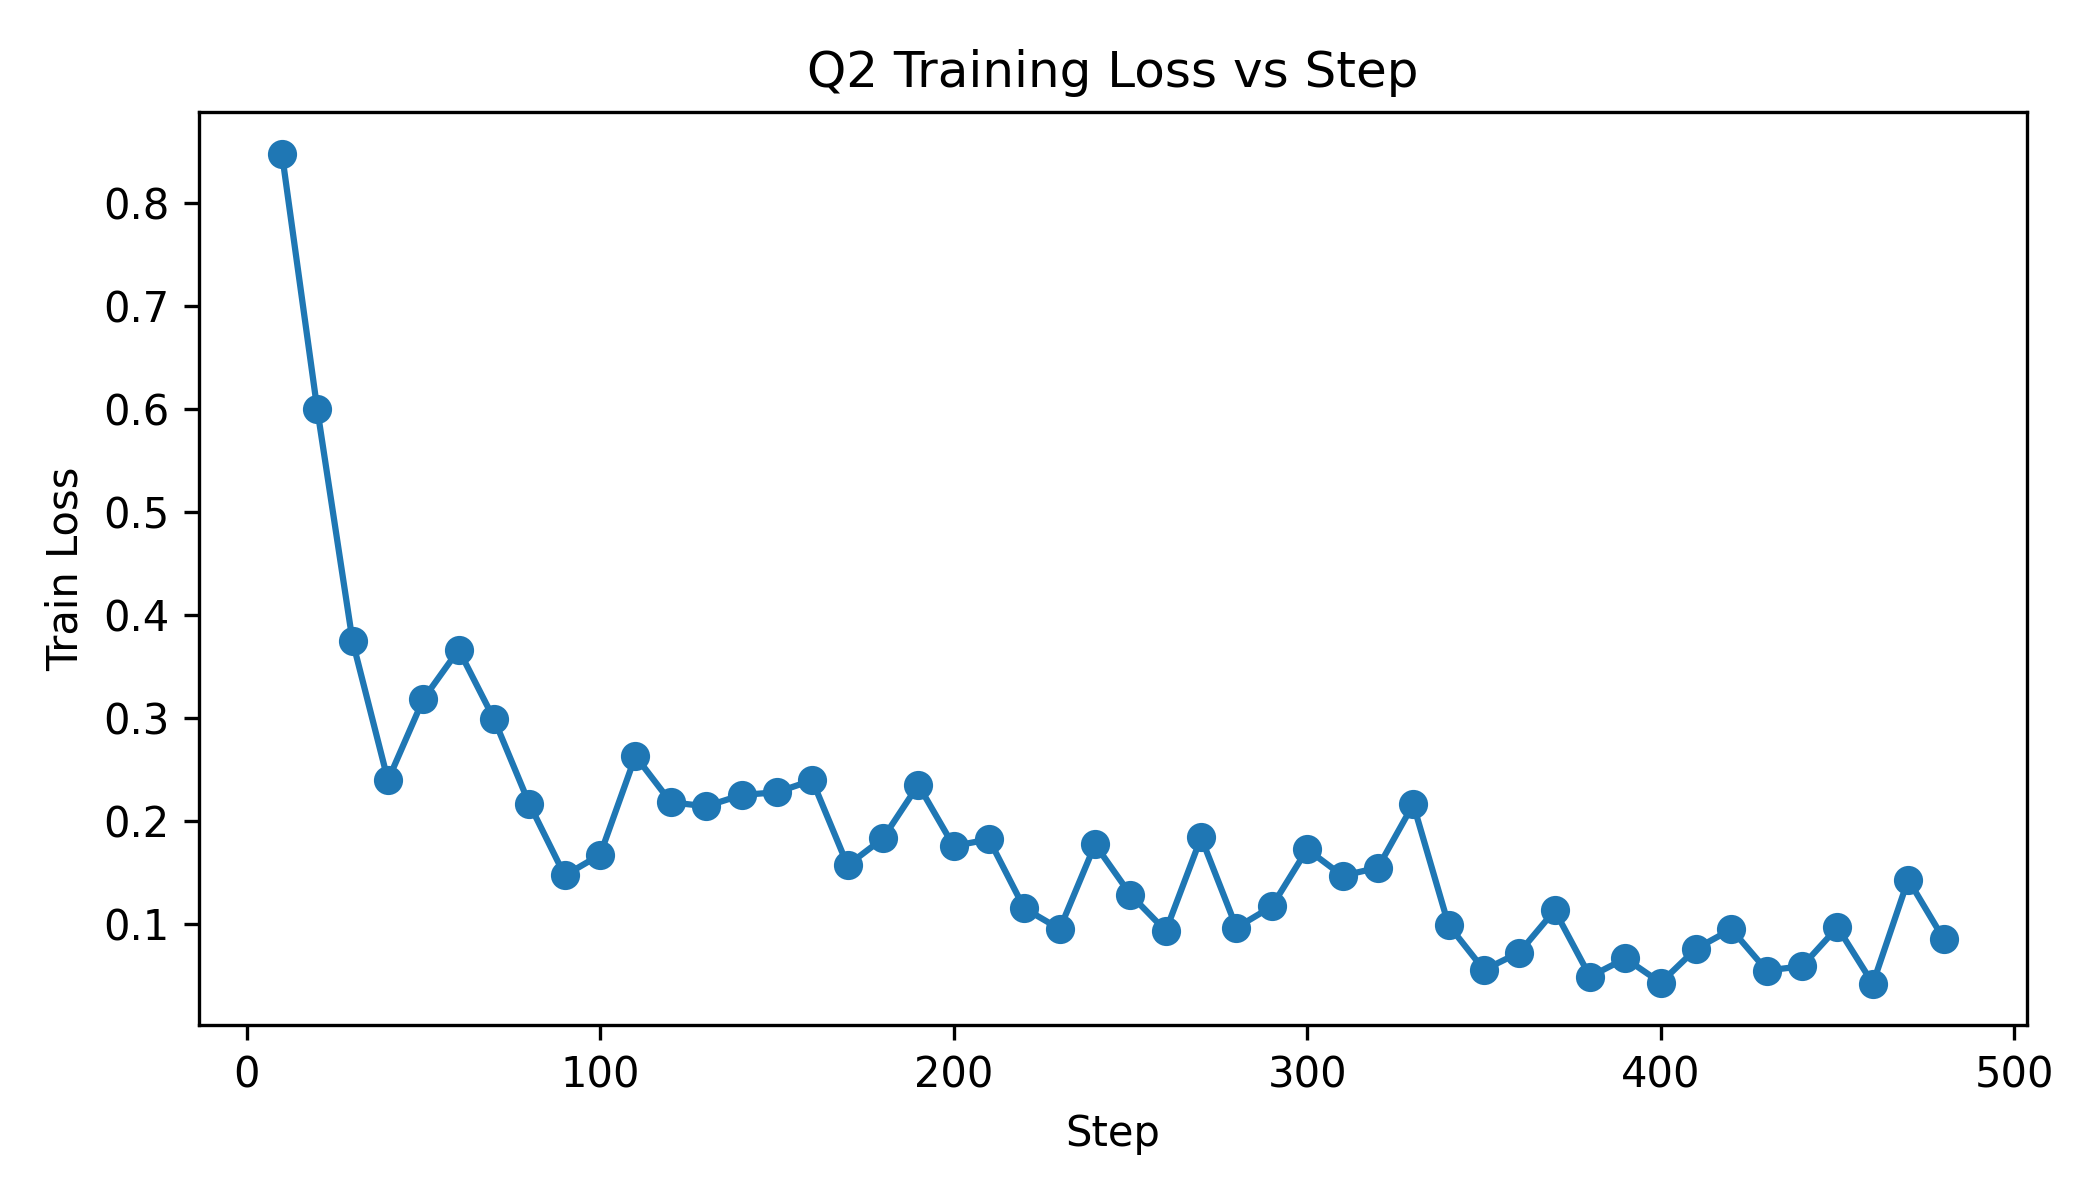

## Q2 Deliverable 2: Three Examples Before vs After SFT

### Example 1
**English:** Although I was tired after work, I still went to the gym because I promised myself I would stay consistent.

**Before SFT:**

```
"A tired, I was, after work, but to the gym, I went, I did, a promise to myself, keep, I must."
```

**After SFT:**

```
To the gym, I still went because I promised myself I would stay consistent, although tired after work, I was.
```

### Example 2
**English:** If you finish the report by Friday, we can submit it early and avoid last-minute mistakes.

**Before SFT:**

```
"Early submit, we can, if by Friday finished, the report, you are."
```

**After SFT:**

```
Finish the report by Friday, you must, and early submit it we can, and last-minute mistakes avoid.
```

### Example 3
**English:** When I realized the meeting was cancelled, I used the extra time to review the paper and take notes.

**Before SFT:**

```
"A meeting cancelled, it was. Review the paper and notes, I did."
```

**After SFT:**

```
The extra time to review the paper and take notes, I used when the meeting was cancelled.
```


Q2 DONE. Records saved to:
./PartA_Q2_outputs/Q2_20260321_234822_UTC
Key outputs: loss_curve.png, eval_curve.png (if any), before_after.json, demo_before_after.md, adapter/, report.md


In [4]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
Q2 - LoRA Fine-tuning (SFT style) for Yoda Translation
Model: /workspace/tbx/Llama-3.2-3B-Instruct/
Dataset CSV: /workspace/tbx/yoda_sentences/sentences.csv

Records saved into: ./PartA_Q2_outputs/Q2_YYYYMMDD_HHMMSS_UTC/
- env.json
- run_config.json
- data_stats.json
- split.json
- lora_config.json
- train_time.json
- train_log_history.jsonl
- loss_curve.png
- eval_curve.png (if eval enabled)
- before_after.json
- demo_before_after.md
- report.md
- adapter/   (LoRA adapter + tokenizer)
"""

import os
import json
import time
import random
import platform
import inspect
import warnings
from datetime import datetime
from typing import Dict, List, Any

import torch
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown, Image

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    default_data_collator,
)

from peft import LoraConfig, get_peft_model
from trl import SFTTrainer, SFTConfig


# =========================
# USER SETTINGS
# =========================
MODEL_PATH = "/workspace/tbx/Llama-3.2-3B-Instruct/"
CSV_PATH = "/workspace/tbx/yoda_sentences/sentences.csv"

OUT_ROOT = "./PartA_Q2_outputs"

SEED = 42
MAX_LENGTH = 256

TRAIN_RATIO = 0.9
USE_FIXED_SPLIT = False
TRAIN_SIZE = 500
VAL_SIZE = 200

EPOCHS = 3
LR = 2e-4
BATCH_SIZE = 4
GRAD_ACCUM = 1
LOGGING_STEPS = 10
EVAL_STEPS = 50
WARMUP_STEPS = 30

DEMO_MAX_NEW_TOKENS = 80
DEMO_TEMPERATURE = 0.0

DEMO_MODE = "hard"   # "hard" or "dataset"
DEMO_N = 15          # full demo can be more, but deliverable display uses 3

os.environ["TOKENIZERS_PARALLELISM"] = "false"
warnings.filterwarnings("ignore")


# =========================
# JSON safety
# =========================
def sanitize_json(obj):
    if isinstance(obj, dict):
        return {k: sanitize_json(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [sanitize_json(x) for x in obj]
    if isinstance(obj, tuple):
        return [sanitize_json(x) for x in obj]
    if isinstance(obj, set):
        return sorted([sanitize_json(x) for x in obj])
    try:
        import numpy as np
        if isinstance(obj, (np.integer, np.floating)):
            return obj.item()
        if isinstance(obj, np.ndarray):
            return obj.tolist()
    except Exception:
        pass
    if isinstance(obj, torch.dtype):
        return str(obj)
    return obj


def ensure_dir(path: str) -> None:
    os.makedirs(path, exist_ok=True)


def write_json(path: str, obj: Any) -> None:
    with open(path, "w", encoding="utf-8") as f:
        json.dump(sanitize_json(obj), f, ensure_ascii=False, indent=2)


def write_jsonl(path: str, rows: List[Dict[str, Any]]) -> None:
    with open(path, "w", encoding="utf-8") as f:
        for r in rows:
            f.write(json.dumps(sanitize_json(r), ensure_ascii=False) + "\n")


# =========================
# Env / seed
# =========================
def get_env_info() -> Dict[str, Any]:
    info = {
        "timestamp_utc": datetime.utcnow().strftime("%Y-%m-%d %H:%M:%S"),
        "python": platform.python_version(),
        "platform": platform.platform(),
        "torch_version": torch.__version__,
        "cuda_available": torch.cuda.is_available(),
    }
    if torch.cuda.is_available():
        info.update({
            "cuda_device_count": torch.cuda.device_count(),
            "cuda_device_name_0": torch.cuda.get_device_name(0),
            "cuda_capability_0": torch.cuda.get_device_capability(0),
            "cuda_total_vram_mb_0": round(torch.cuda.get_device_properties(0).total_memory / (1024**2), 1),
        })
    return info


def set_seed(seed: int) -> None:
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


# =========================
# Prompt
# =========================
def build_messages(english_sentence: str) -> List[Dict[str, str]]:
    system = "You are a translator that converts English sentences into Yoda-style speech."
    user = (
        "Translate the following sentence into Yoda-style. "
        "Output only the translated sentence.\n\n"
        f"{english_sentence}"
    )
    return [
        {"role": "system", "content": system},
        {"role": "user", "content": user},
    ]


def build_prompt_text(tokenizer, english_sentence: str) -> str:
    return tokenizer.apply_chat_template(
        build_messages(english_sentence),
        tokenize=False,
        add_generation_prompt=True,
    )


# =========================
# Dataset (prompt masking)
# =========================
class YodaSFTDataset(torch.utils.data.Dataset):
    def __init__(self, tokenizer, df: pd.DataFrame, max_length: int):
        self.tokenizer = tokenizer
        self.df = df.reset_index(drop=True)
        self.max_length = max_length

        cols = list(self.df.columns)
        cols_set = set(cols)

        # CSV expected: sentence, translation, translation_extra
        self.col_src = "sentence" if "sentence" in cols_set else cols[0]
        if "translation" in cols_set:
            self.col_tgt = "translation"
        elif "yoda_sentence" in cols_set:
            self.col_tgt = "yoda_sentence"
        elif "yoda" in cols_set:
            self.col_tgt = "yoda"
        else:
            self.col_tgt = cols[1] if len(cols) > 1 else cols[0]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        row = self.df.iloc[idx]
        src = str(row[self.col_src]).strip()
        tgt = str(row[self.col_tgt]).strip()

        prompt_text = build_prompt_text(self.tokenizer, src)
        full_text = prompt_text + tgt

        enc_prompt = self.tokenizer(
            prompt_text,
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt",
        )
        prompt_len = int(enc_prompt["input_ids"].shape[1])

        enc_full = self.tokenizer(
            full_text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt",
        )

        input_ids = enc_full["input_ids"][0]
        attention_mask = enc_full["attention_mask"][0]

        labels = input_ids.clone()
        labels[:prompt_len] = -100
        labels[attention_mask == 0] = -100

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels,
        }


# =========================
# Demo generation
# =========================
@torch.no_grad()
def generate_yoda(model, tokenizer, english_sentence: str) -> str:
    prompt_text = build_prompt_text(tokenizer, english_sentence)
    enc = tokenizer(prompt_text, return_tensors="pt").to(model.device)

    gen_kwargs = dict(
        max_new_tokens=DEMO_MAX_NEW_TOKENS,
        do_sample=(DEMO_TEMPERATURE > 0),
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )
    if DEMO_TEMPERATURE > 0:
        gen_kwargs["temperature"] = DEMO_TEMPERATURE

    out = model.generate(**enc, **gen_kwargs)
    gen_ids = out[0][enc["input_ids"].shape[-1]:]
    text = tokenizer.decode(gen_ids, skip_special_tokens=True).strip()
    text = text.split("\n")[0].strip()
    return text


def get_demo_inputs(df: pd.DataFrame) -> List[str]:
    hard = [
        "Although I was tired after work, I still went to the gym because I promised myself I would stay consistent.",
        "If you finish the report by Friday, we can submit it early and avoid last-minute mistakes.",
        "When I realized the meeting was cancelled, I used the extra time to review the paper and take notes.",
        "I don't think this approach will work, but I'm willing to try it if you can explain the reasoning clearly.",
        "This method is not only faster, but it is also more reliable in noisy environments.",
        "Because the dataset is imbalanced, the model tends to predict the majority class unless we use reweighting.",
        "The experiment failed twice, so we changed the learning rate and reduced the batch size.",
        "The training took 3 hours and 25 minutes, and the best validation loss was 0.47 at step 450.",
        "Please remind me to call my supervisor at 10:30 tomorrow morning and send the updated slides.",
        "She said, 'I will never give up,' even when everything seemed impossible.",
        "Honestly, I'm frustrated right now, but I know I can improve if I keep practicing.",
        "Summarize the key differences between supervised fine-tuning and reinforcement learning in two sentences.",
        "Explain why setting a padding token is necessary when we use padding='max_length' during tokenization.",
        "The results look promising; however, we should double-check the evaluation protocol before drawing conclusions.",
        "Not until I read the documentation carefully did I understand why the training kept crashing.",
    ]

    if DEMO_MODE == "dataset":
        if "sentence" not in df.columns:
            return hard[:DEMO_N]
        demo = df["sentence"].dropna().astype(str).sample(
            n=min(DEMO_N, len(df)),
            random_state=SEED
        ).tolist()
        return demo

    return hard[:DEMO_N]


def save_demo_markdown(path: str, demo_inputs: List[str], before: List[Dict[str, str]], after: List[Dict[str, str]]) -> None:
    md_lines = []
    md_lines.append("# Q2 Demo (Before vs After)\n")
    for i, s in enumerate(demo_inputs, 1):
        md_lines.append(f"## Example {i}")
        md_lines.append(f"**English:** {s}\n")
        md_lines.append("**Before:**")
        md_lines.append("```")
        md_lines.append(before[i-1]["yoda"])
        md_lines.append("```")
        md_lines.append("**After:**")
        md_lines.append("```")
        md_lines.append(after[i-1]["yoda"])
        md_lines.append("```")
        md_lines.append("")
    with open(path, "w", encoding="utf-8") as f:
        f.write("\n".join(md_lines))


# =========================
# SFTConfig compatibility (trl 0.15.0)
# =========================
def make_training_args(out_dir: str, dtype: torch.dtype) -> SFTConfig:
    sig = inspect.signature(SFTConfig.__init__).parameters

    common = dict(
        output_dir=os.path.join(out_dir, "checkpoints"),
        num_train_epochs=EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        gradient_accumulation_steps=GRAD_ACCUM,
        learning_rate=LR,
        warmup_steps=WARMUP_STEPS,
        logging_steps=LOGGING_STEPS,
        eval_steps=EVAL_STEPS,
        save_strategy="no",
        report_to="none",
        fp16=(dtype == torch.float16),
        bf16=(dtype == torch.bfloat16),
        dataloader_pin_memory=True,
        disable_tqdm=True,
        logging_strategy="steps",
        max_seq_length=MAX_LENGTH,
    )

    if "eval_strategy" in sig:
        common["eval_strategy"] = "steps"
    elif "evaluation_strategy" in sig:
        common["evaluation_strategy"] = "steps"

    args = SFTConfig(**common)

    # for pre-tokenized dataset
    args.remove_unused_columns = False
    args.dataset_kwargs = {"skip_prepare_dataset": True}

    return args


# =========================
# Main
# =========================
def main():
    set_seed(SEED)

    run_id = datetime.utcnow().strftime("Q2_%Y%m%d_%H%M%S_UTC")
    out_dir = os.path.join(OUT_ROOT, run_id)
    ensure_dir(out_dir)

    write_json(os.path.join(out_dir, "env.json"), get_env_info())
    write_json(os.path.join(out_dir, "run_config.json"), {
        "model_path": MODEL_PATH,
        "csv_path": CSV_PATH,
        "seed": SEED,
        "max_length": MAX_LENGTH,
        "epochs": EPOCHS,
        "lr": LR,
        "batch_size": BATCH_SIZE,
        "grad_accum": GRAD_ACCUM,
        "logging_steps": LOGGING_STEPS,
        "eval_steps": EVAL_STEPS,
        "warmup_steps": WARMUP_STEPS,
        "demo_mode": DEMO_MODE,
        "demo_n": DEMO_N,
        "notes": "Q2 LoRA SFT for Yoda translation; prompt masking; explicit deliverable display; SFTTrainer version for trl 0.15.0.",
    })

    df = pd.read_csv(CSV_PATH)
    write_json(os.path.join(out_dir, "data_stats.json"), {
        "num_rows": int(len(df)),
        "columns": list(df.columns),
        "head_preview": df.head(3).to_dict(orient="records"),
    })

    df = df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
    if USE_FIXED_SPLIT:
        train_df = df.iloc[:TRAIN_SIZE].copy()
        val_df = df.iloc[TRAIN_SIZE:TRAIN_SIZE + VAL_SIZE].copy()
    else:
        n_train = int(len(df) * TRAIN_RATIO)
        train_df = df.iloc[:n_train].copy()
        val_df = df.iloc[n_train:].copy()

    write_json(os.path.join(out_dir, "split.json"), {
        "train_size": int(len(train_df)),
        "val_size": int(len(val_df)),
        "use_fixed_split": USE_FIXED_SPLIT,
        "train_ratio": TRAIN_RATIO,
        "train_size_fixed": TRAIN_SIZE,
        "val_size_fixed": VAL_SIZE,
    })

    tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, use_fast=True)

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    assert tokenizer.pad_token_id is not None

    if torch.cuda.is_available():
        if torch.cuda.get_device_capability(0)[0] >= 8:
            dtype = torch.bfloat16
        else:
            dtype = torch.float16
    else:
        dtype = torch.float32

    model = AutoModelForCausalLM.from_pretrained(
        MODEL_PATH,
        torch_dtype=dtype,
        device_map="auto" if torch.cuda.is_available() else None,
    )
    model.eval()
    model.config.pad_token_id = tokenizer.pad_token_id

    lora_cfg = LoraConfig(
        r=16,
        lora_alpha=32,
        target_modules=["q_proj", "v_proj"],
        lora_dropout=0.05,
        bias="none",
        task_type="CAUSAL_LM",
    )
    write_json(os.path.join(out_dir, "lora_config.json"), lora_cfg.to_dict())

    model = get_peft_model(model, lora_cfg)
    model.print_trainable_parameters()

    train_ds = YodaSFTDataset(tokenizer, train_df, max_length=MAX_LENGTH)
    val_ds = YodaSFTDataset(tokenizer, val_df, max_length=MAX_LENGTH)

    args = make_training_args(out_dir, dtype)
    collator = default_data_collator

    trainer = SFTTrainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds if len(val_ds) > 0 else None,
        data_collator=collator,
        processing_class=tokenizer,
    )

    # BEFORE
    demo_inputs = get_demo_inputs(df)
    before = [{"english": s, "yoda": generate_yoda(model, tokenizer, s)} for s in demo_inputs]

    # TRAIN
    t0 = time.time()
    trainer.train()
    t1 = time.time()
    write_json(os.path.join(out_dir, "train_time.json"), {"train_time_s": t1 - t0})

    # AFTER
    after = [{"english": s, "yoda": generate_yoda(model, tokenizer, s)} for s in demo_inputs]

    write_json(os.path.join(out_dir, "before_after.json"), {"before": before, "after": after})
    save_demo_markdown(os.path.join(out_dir, "demo_before_after.md"), demo_inputs, before, after)

    adapter_dir = os.path.join(out_dir, "adapter")
    ensure_dir(adapter_dir)
    model.save_pretrained(adapter_dir)
    tokenizer.save_pretrained(adapter_dir)

    log_history = trainer.state.log_history
    write_jsonl(os.path.join(out_dir, "train_log_history.jsonl"), log_history)

    train_steps, train_losses = [], []
    eval_steps, eval_losses = [], []

    for item in log_history:
        if "loss" in item and "step" in item:
            train_steps.append(item["step"])
            train_losses.append(item["loss"])
        if "eval_loss" in item and "step" in item:
            eval_steps.append(item["step"])
            eval_losses.append(item["eval_loss"])

    loss_curve_path = os.path.join(out_dir, "loss_curve.png")
    if len(train_losses) > 0:
        plt.figure(figsize=(7, 4))
        plt.plot(train_steps, train_losses, marker="o")
        plt.xlabel("Step")
        plt.ylabel("Train Loss")
        plt.title("Q2 Training Loss vs Step")
        plt.tight_layout()
        plt.savefig(loss_curve_path, dpi=300)
        plt.close()

    eval_curve_path = os.path.join(out_dir, "eval_curve.png")
    if len(eval_losses) > 0:
        plt.figure(figsize=(7, 4))
        plt.plot(eval_steps, eval_losses, marker="o")
        plt.xlabel("Step")
        plt.ylabel("Eval Loss")
        plt.title("Q2 Eval Loss vs Step")
        plt.tight_layout()
        plt.savefig(eval_curve_path, dpi=300)
        plt.close()

    report_lines = []
    report_lines.append("# Q2 LoRA SFT Record\n")
    report_lines.append(f"- Run ID: `{run_id}`")
    report_lines.append(f"- Model: `{MODEL_PATH}`")
    report_lines.append(f"- Dataset: `{CSV_PATH}`")
    report_lines.append(f"- Dtype: `{dtype}`")
    report_lines.append(f"- Train size: `{len(train_df)}`  |  Val size: `{len(val_df)}`")
    report_lines.append(f"- Hyperparams: epochs={EPOCHS}, lr={LR}, bs={BATCH_SIZE}, grad_accum={GRAD_ACCUM}, max_len={MAX_LENGTH}, warmup_steps={WARMUP_STEPS}")
    report_lines.append(f"- Demo mode: `{DEMO_MODE}`  |  Demo N: `{len(demo_inputs)}`")
    report_lines.append("")
    report_lines.append("## Deliverables")
    report_lines.append("- Training Loss vs Steps: `loss_curve.png`")
    report_lines.append("- Three examples before and after SFT: `before_after.json` and `demo_before_after.md`")

    with open(os.path.join(out_dir, "report.md"), "w", encoding="utf-8") as f:
        f.write("\n".join(report_lines))

    # =========================
    # Explicit notebook deliverables
    # =========================
    display(Markdown("## Q2 Deliverable 1: Training Loss vs. Steps"))
    if os.path.exists(loss_curve_path):
        display(Image(filename=loss_curve_path))
    else:
        print("loss_curve.png was not generated.")

    display(Markdown("## Q2 Deliverable 2: Three Examples Before vs After SFT"))
    for i in range(min(3, len(demo_inputs))):
        display(Markdown(
            f"### Example {i+1}\n"
            f"**English:** {before[i]['english']}\n\n"
            f"**Before SFT:**\n\n```\n{before[i]['yoda']}\n```\n\n"
            f"**After SFT:**\n\n```\n{after[i]['yoda']}\n```"
        ))

    print("\n" + "=" * 80)
    print("Q2 DONE. Records saved to:")
    print(out_dir)
    print("Key outputs: loss_curve.png, eval_curve.png (if any), before_after.json, demo_before_after.md, adapter/, report.md")
    print("=" * 80)


if __name__ == "__main__":
    main()

# PartA Q3

In [5]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
Q3 - Dataset Generation (Synthetic QA in Yoda style) [OFFLINE PARQUET VERSION]

We use the trained translator from Q2 (LoRA adapter) to translate answers of a QA dataset into Yoda-style.

Source dataset (HF): sentence-transformers/natural-questions, config: pair
Loaded OFFLINE from local parquet:
  /workspace/tbx/natural-questions/pair/train-00000-of-00001.parquet

We create random subset sizes:
  train=500, val=200, test=500

Outputs saved into: ./PartA_Q3_outputs/Q3_YYYYMMDD_HHMMSS_UTC/
- env.json
- run_config.json
- source_dataset_info.json
- samples_preview.json
- yoda_train.jsonl / yoda_val.jsonl / yoda_test.jsonl
- yoda_train.csv / yoda_val.csv / yoda_test.csv
- demo_3_examples.md
"""

import os
import json
import time
import random
import platform
import warnings
from datetime import datetime
from typing import Dict, Any, List, Tuple

import torch
import pandas as pd
from tqdm import tqdm
from IPython.display import display, Markdown

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel


# =========================
# USER SETTINGS
# =========================
BASE_MODEL_PATH = "/workspace/tbx/Llama-3.2-3B-Instruct/"

# Automatically find the latest Q2 adapter under these roots
Q2_SEARCH_ROOTS = [
    "./PartA_Q2_outputs",
    "./Q2_records",
    "/workspace/tbx/PartA_Q2_outputs",
    "/workspace/tbx/Q2_records",
]

# HF dataset identity (for record keeping)
HF_DATASET = "sentence-transformers/natural-questions"
HF_CONFIG = "pair"
HF_SPLIT = "train"

# OFFLINE local parquet
LOCAL_PARQUET = "/workspace/tbx/natural-questions/pair/train-00000-of-00001.parquet"

# required subset sizes
N_TRAIN = 500
N_VAL = 200
N_TEST = 500
SEED = 42

# generation
GEN_BATCH_SIZE = 4
MAX_NEW_TOKENS = 128
TEMPERATURE = 0.0  # deterministic

OUT_ROOT = "./PartA_Q3_outputs"

os.environ["TOKENIZERS_PARALLELISM"] = "false"
warnings.filterwarnings("ignore")


# =========================
# Utils
# =========================
def ensure_dir(p: str):
    os.makedirs(p, exist_ok=True)


def sanitize_json(obj):
    if isinstance(obj, dict):
        return {k: sanitize_json(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [sanitize_json(x) for x in obj]
    if isinstance(obj, tuple):
        return [sanitize_json(x) for x in obj]
    if isinstance(obj, set):
        return sorted([sanitize_json(x) for x in obj])
    if isinstance(obj, torch.dtype):
        return str(obj)
    return obj


def write_json(path: str, obj: Any):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(sanitize_json(obj), f, ensure_ascii=False, indent=2)


def write_jsonl(path: str, rows: List[Dict[str, Any]]):
    with open(path, "w", encoding="utf-8") as f:
        for r in rows:
            f.write(json.dumps(sanitize_json(r), ensure_ascii=False) + "\n")


def get_env_info() -> Dict[str, Any]:
    info = {
        "timestamp_utc": datetime.utcnow().strftime("%Y-%m-%d %H:%M:%S"),
        "python": platform.python_version(),
        "platform": platform.platform(),
        "torch_version": torch.__version__,
        "cuda_available": torch.cuda.is_available(),
    }
    if torch.cuda.is_available():
        info.update({
            "cuda_device_count": torch.cuda.device_count(),
            "cuda_device_name_0": torch.cuda.get_device_name(0),
            "cuda_capability_0": torch.cuda.get_device_capability(0),
            "cuda_total_vram_mb_0": round(torch.cuda.get_device_properties(0).total_memory / (1024**2), 1),
        })
    return info


def set_seed(seed: int):
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def find_latest_q2_adapter(search_roots: List[str]) -> str:
    candidates = []

    for root in search_roots:
        if not os.path.isdir(root):
            continue

        for run_name in os.listdir(root):
            run_path = os.path.join(root, run_name)
            if not os.path.isdir(run_path):
                continue
            if not run_name.startswith("Q2_"):
                continue

            adapter_path = os.path.join(run_path, "adapter")
            adapter_config = os.path.join(adapter_path, "adapter_config.json")

            if os.path.isdir(adapter_path) and os.path.isfile(adapter_config):
                mtime = os.path.getmtime(adapter_path)
                candidates.append((mtime, adapter_path))

    if not candidates:
        searched = "\n".join(search_roots)
        raise FileNotFoundError(
            "Could not find any valid Q2 adapter.\n"
            "Searched roots:\n"
            f"{searched}\n"
            "Expected structure like: <root>/Q2_YYYYMMDD_HHMMSS_UTC/adapter/adapter_config.json"
        )

    candidates.sort(key=lambda x: x[0], reverse=True)
    return candidates[0][1]


# =========================
# Prompt (same as Q2)
# =========================
def build_messages(english_text: str) -> List[Dict[str, str]]:
    system = "You are a translator that converts English sentences into Yoda-style speech."
    user = (
        "Translate the following text into Yoda-style. "
        "Output only the translated text.\n\n"
        f"{english_text}"
    )
    return [
        {"role": "system", "content": system},
        {"role": "user", "content": user},
    ]


def build_prompt_text(tokenizer, english_text: str) -> str:
    return tokenizer.apply_chat_template(
        build_messages(english_text),
        tokenize=False,
        add_generation_prompt=True,
    )


# =========================
# Robust column inference
# =========================
def infer_qa_columns(col_names: List[str]) -> Tuple[str, str]:
    """
    Infer which columns correspond to (question, answer).
    Supports common QA & sentence-transformers pair style.
    """
    cols = set(col_names)

    for qk in ["question", "query", "prompt", "input"]:
        for ak in ["answer", "response", "output", "target"]:
            if qk in cols and ak in cols:
                return qk, ak

    if "sentence1" in cols and "sentence2" in cols:
        return "sentence1", "sentence2"

    if "text1" in cols and "text2" in cols:
        return "text1", "text2"

    if len(col_names) >= 2:
        return col_names[0], col_names[1]

    raise ValueError(f"Cannot infer QA columns from: {col_names}")


# =========================
# Generation (batched)
# =========================
@torch.no_grad()
def translate_batch(model, tokenizer, answers: List[str]) -> List[str]:
    prompts = [build_prompt_text(tokenizer, a) for a in answers]
    enc = tokenizer(
        prompts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=512,
    ).to(model.device)

    gen_kwargs = dict(
        max_new_tokens=MAX_NEW_TOKENS,
        do_sample=(TEMPERATURE > 0),
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )
    if TEMPERATURE > 0:
        gen_kwargs["temperature"] = TEMPERATURE

    out = model.generate(**enc, **gen_kwargs)

    results = []
    input_lengths = enc["attention_mask"].sum(dim=1).tolist()
    for i in range(out.shape[0]):
        gen_ids = out[i][int(input_lengths[i]):]
        text = tokenizer.decode(gen_ids, skip_special_tokens=True).strip()
        text = text.split("\n")[0].strip()
        results.append(text)
    return results


# =========================
# Main
# =========================
def main():
    set_seed(SEED)

    run_id = datetime.utcnow().strftime("Q3_%Y%m%d_%H%M%S_UTC")
    out_dir = os.path.join(OUT_ROOT, run_id)
    ensure_dir(out_dir)

    adapter_path = find_latest_q2_adapter(Q2_SEARCH_ROOTS)

    write_json(os.path.join(out_dir, "env.json"), get_env_info())
    write_json(os.path.join(out_dir, "run_config.json"), {
        "base_model_path": BASE_MODEL_PATH,
        "adapter_path": adapter_path,
        "q2_search_roots": Q2_SEARCH_ROOTS,
        "HF_TOKEN_REDACTED": HF_DATASET,
        "HF_TOKEN_REDACTED": HF_CONFIG,
        "HF_TOKEN_REDACTED": HF_SPLIT,
        "loaded_from": "local_parquet_offline",
        "local_parquet": LOCAL_PARQUET,
        "seed": SEED,
        "subset_sizes": {"train": N_TRAIN, "val": N_VAL, "test": N_TEST},
        "generation": {
            "batch_size": GEN_BATCH_SIZE,
            "max_new_tokens": MAX_NEW_TOKENS,
            "temperature": TEMPERATURE
        },
        "notes": "Q3: translate source QA answers into Yoda style using latest Q2 translator adapter (offline parquet load).",
    })

    if not os.path.exists(LOCAL_PARQUET):
        raise FileNotFoundError(f"Local parquet not found: {LOCAL_PARQUET}")

    os.environ["HF_HUB_OFFLINE"] = "1"
    os.environ["HF_DATASETS_OFFLINE"] = "1"

    ds = load_dataset(
        "parquet",
        data_files={"train": LOCAL_PARQUET},
        split="train",
    )

    col_names = list(ds.features.keys())
    q_col, a_col = infer_qa_columns(col_names)

    write_json(os.path.join(out_dir, "source_dataset_info.json"), {
        "dataset_HF_TOKEN_REDACTED": HF_DATASET,
        "config": HF_CONFIG,
        "split_used": HF_SPLIT,
        "loaded_from": "local_parquet_offline",
        "local_parquet": LOCAL_PARQUET,
        "num_rows_in_split": int(len(ds)),
        "columns": col_names,
        "inferred_question_col": q_col,
        "inferred_answer_col": a_col,
    })

    print("Columns:", col_names)
    print("Inferred (q_col, a_col):", q_col, a_col)
    print("Latest Q2 adapter found:", adapter_path)
    print("Example[0]:", str(ds[0][q_col])[:120], " || ", str(ds[0][a_col])[:120])

    total_needed = N_TRAIN + N_VAL + N_TEST
    if len(ds) < total_needed:
        raise ValueError(f"Not enough samples: have {len(ds)}, need {total_needed}")

    indices = list(range(len(ds)))
    random.Random(SEED).shuffle(indices)
    idx_train = indices[:N_TRAIN]
    idx_val = indices[N_TRAIN:N_TRAIN + N_VAL]
    idx_test = indices[N_TRAIN + N_VAL:N_TRAIN + N_VAL + N_TEST]

    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_PATH, use_fast=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    if torch.cuda.is_available():
        if torch.cuda.get_device_capability(0)[0] >= 8:
            dtype = torch.bfloat16
        else:
            dtype = torch.float16
    else:
        dtype = torch.float32

    base_model = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL_PATH,
        torch_dtype=dtype,
        device_map="auto" if torch.cuda.is_available() else None,
    )
    base_model.config.pad_token_id = tokenizer.pad_token_id

    model = PeftModel.from_pretrained(base_model, adapter_path)
    model.eval()

    def build_split(name: str, idx_list: List[int]) -> List[Dict[str, Any]]:
        rows = []
        for i in idx_list:
            ex = ds[int(i)]
            q = str(ex[q_col])
            a = str(ex[a_col])
            rows.append({
                "id": f"{name}_{i}",
                "question": q,
                "answer_original": a,
            })
        return rows

    train_rows = build_split("train", idx_train)
    val_rows = build_split("val", idx_val)
    test_rows = build_split("test", idx_test)

    def translate_rows(rows: List[Dict[str, Any]], split_name: str) -> List[Dict[str, Any]]:
        out_rows = []
        for s in tqdm(range(0, len(rows), GEN_BATCH_SIZE), desc=f"Translating {split_name}"):
            batch = rows[s:s + GEN_BATCH_SIZE]
            answers = [r["answer_original"] for r in batch]
            yoda_answers = translate_batch(model, tokenizer, answers)
            for r, y in zip(batch, yoda_answers):
                r2 = dict(r)
                r2["answer_yoda"] = y
                out_rows.append(r2)
        return out_rows

    t0 = time.time()
    train_out = translate_rows(train_rows, "train")
    val_out = translate_rows(val_rows, "val")
    test_out = translate_rows(test_rows, "test")
    t1 = time.time()

    write_json(os.path.join(out_dir, "generation_time.json"), {
        "generation_time_s": t1 - t0
    })

    write_jsonl(os.path.join(out_dir, "yoda_train.jsonl"), train_out)
    write_jsonl(os.path.join(out_dir, "yoda_val.jsonl"), val_out)
    write_jsonl(os.path.join(out_dir, "yoda_test.jsonl"), test_out)

    pd.DataFrame(train_out).to_csv(os.path.join(out_dir, "yoda_train.csv"), index=False, encoding="utf-8")
    pd.DataFrame(val_out).to_csv(os.path.join(out_dir, "yoda_val.csv"), index=False, encoding="utf-8")
    pd.DataFrame(test_out).to_csv(os.path.join(out_dir, "yoda_test.csv"), index=False, encoding="utf-8")

    demo = []
    for ex in (train_out[:1] + val_out[:1] + test_out[:1]):
        demo.append({
            "id": ex["id"],
            "question": ex["question"],
            "answer_original": ex["answer_original"],
            "answer_yoda": ex["answer_yoda"],
        })
    write_json(os.path.join(out_dir, "samples_preview.json"), demo)

    md = []
    md.append("# Q3 Synthetic Dataset Examples (3)\n")
    md.append(f"- Source dataset (HF): `{HF_DATASET}` (config `{HF_CONFIG}`)\n")
    md.append(f"- Loaded offline from: `{LOCAL_PARQUET}`\n")
    md.append(f"- Q2 adapter used: `{adapter_path}`\n")
    md.append(f"- Split sizes: train={N_TRAIN}, val={N_VAL}, test={N_TEST}\n")
    md.append("")
    for i, ex in enumerate(demo, 1):
        md.append(f"## Example {i}")
        md.append(f"**Question:** {ex['question']}\n")
        md.append("**Original answer:**")
        md.append("```")
        md.append(ex["answer_original"])
        md.append("```")
        md.append("**Yoda-style answer:**")
        md.append("```")
        md.append(ex["answer_yoda"])
        md.append("```")
        md.append("")
    with open(os.path.join(out_dir, "demo_3_examples.md"), "w", encoding="utf-8") as f:
        f.write("\n".join(md))

    display(Markdown("## Q3 Deliverable: 3 Examples from the New Synthetic Dataset"))
    display(Markdown(
        f"**Source dataset:** `{HF_DATASET}`  \n"
        f"**Config:** `{HF_CONFIG}`  \n"
        f"**Loaded from:** `{LOCAL_PARQUET}`  \n"
        f"**Q2 adapter used:** `{adapter_path}`  \n"
        f"**Subset sizes:** train={N_TRAIN}, val={N_VAL}, test={N_TEST}"
    ))

    for i, ex in enumerate(demo, 1):
        display(Markdown(
            f"### Example {i}\n"
            f"**Question:** {ex['question']}\n\n"
            f"**Original answer:**\n\n```\n{ex['answer_original']}\n```\n\n"
            f"**Yoda-style answer:**\n\n```\n{ex['answer_yoda']}\n```"
        ))

    print("=" * 80)
    print("Q3 DONE. Saved to:")
    print(out_dir)
    print("Key outputs: yoda_train/val/test.(jsonl,csv) + demo_3_examples.md + samples_preview.json")
    print("=" * 80)


if __name__ == "__main__":
    main()

Columns: ['query', 'answer']
Inferred (q_col, a_col): query answer
Latest Q2 adapter found: ./PartA_Q2_outputs/Q2_20260321_234822_UTC/adapter
Example[0]: when did richmond last play in a preliminary final  ||  Richmond Football Club Richmond began 2017 with 5 straight wins, a feat it had not achieved since 1995. A series of clos


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Translating test: 100%|██████████| 125/125 [13:53<00:00,  6.67s/it]


## Q3 Deliverable: 3 Examples from the New Synthetic Dataset

**Source dataset:** `sentence-transformers/natural-questions`  
**Config:** `pair`  
**Loaded from:** `/workspace/tbx/natural-questions/pair/train-00000-of-00001.parquet`  
**Q2 adapter used:** `./PartA_Q2_outputs/Q2_20260321_234822_UTC/adapter`  
**Subset sizes:** train=500, val=200, test=500

### Example 1
**Question:** how many bees does a queen bee produce

**Original answer:**

```
Queen bee Although the name might imply it, a queen bee does not directly control the hive. Her sole function is to serve as the reproducer. A well-mated and well-fed queen of quality stock can lay about 1,500 eggs per day during the spring build-upâ€”more than her own body weight in eggs every day. She is continuously surrounded by worker bees who meet her every need, giving her food and disposing of her waste. The attendant workers also collect and then distribute queen mandibular pheromone, a pheromone that inhibits the workers from starting queen cells.[7]
```

**Yoda-style answer:**

```
assistant
```

### Example 2
**Question:** what are the giants in attack on titan

**Original answer:**

```
Attack on Titan Over 100 years before the beginning of the story on an alternate world, giant human-shaped creatures called Titans (巨人, Kyojin) suddenly appeared and nearly wiped out humanity, devouring them without remorse or reason. What remains of humanity now resides within three enormous curtain walls: the outermost is Wall Maria (ウォール・マリア, Wōru Maria); the middle wall is Wall Rose (ウォール・ローゼ, Wōru Rōze, sometimes pronounced like rosé) and the innermost is Wall Sheena (ウォール・シーナ, Wōru Shīna, alt. "Wall Sina"). Inside these walls, humanity has lived in uneasy peace for one hundred years; many people growing up without ever having seen a Titan. This all changes when one day, a giant 60-meter (200 ft)-tall Colossus Titan mysteriously appears after a strike of lightning and breaches the outer wall of the Shiganshina district, a town at Wall Maria, allowing the smaller Titans to invade the district. An Armored Titan smashes clean through the gate in Wall Maria, forcing humankind to abandon the land between Wall Maria and Wall Rose, evacuating the remaining population into the inner districts. The sudden influx of population causes turmoil and famine.
```

**Yoda-style answer:**

```
Over 100 years before the beginning of the story on an alternate world, giant human-shaped creatures called Titans (巨人, Kyojin) suddenly appeared and nearly wiped out humanity, devouring them without remorse or reason. What remains of humanity now resides within three enormous curtain walls: the outermost is Wall Maria (ウォール・マリア, Wōru Maria); the middle wall is Wall Rose (ウォール・ローゼ, Wōru Rōze, sometimes pronounced like rosé) and the innermost is Wall Sheena (ウォール・シーナ, Wōru Shīna, alt. "Wall S
```

### Example 3
**Question:** lucknow congress session 1916 was presided over by—

**Original answer:**

```
Lucknow Pact Muhammad Ali Jinnah, then a member of the Congress as well as the League, made both the parties reach an agreement to pressure the British government to adopt a more liberal approach to India and give Indians more authority to run their country, besides safeguarding basic Muslim demands. Jinnah is seen as the mastermind and architect of this pact.[citation needed]
```

**Yoda-style answer:**

```
assistant
```

Q3 DONE. Saved to:
./PartA_Q3_outputs/Q3_20260321_235812_UTC
Key outputs: yoda_train/val/test.(jsonl,csv) + demo_3_examples.md + samples_preview.json


# PartA Q4

In [3]:
import os
import re
import pandas as pd

# ─────────────────────────────────────────
# Settings
# ─────────────────────────────────────────
INPUT_DIR  = "Datasets_3b_nq"
OUTPUT_DIR = "Datasets_3b_processed"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ─────────────────────────────────────────
# Clean function
# ─────────────────────────────────────────
def clean_yoda_text(text: str) -> str:
    if pd.isna(text):
        return text

    # Remove leading "assistant" and newlines
    text = re.sub(r'^\s*assistant\s*\n+', '', text, flags=re.IGNORECASE)

    # Remove all [...] citations e.g. [7], [citation needed]
    text = re.sub(r'\[.*?\]', '', text)

    # Clean up extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# ─────────────────────────────────────────
# Process all CSV files
# ─────────────────────────────────────────
csv_files = [f for f in os.listdir(INPUT_DIR) if f.endswith('.csv')]

for filename in csv_files:
    input_path  = os.path.join(INPUT_DIR, filename)
    output_path = os.path.join(OUTPUT_DIR, filename)

    df = pd.read_csv(input_path)

    if 'answer_yoda' not in df.columns:
        print(f"⚠ Skipped (no answer_yoda column): {filename}")
        continue

    original = df['answer_yoda'].copy()
    df['answer_yoda'] = df['answer_yoda'].apply(clean_yoda_text)

    # Count how many rows were changed
    changed = (df['answer_yoda'] != original).sum()

    df.to_csv(output_path, index=False, encoding='utf-8')
    print(f"✓ {filename}  |  {len(df)} rows  |  {changed} rows cleaned  →  {output_path}")

print("\nDone. Processed files saved to:", OUTPUT_DIR)

# ─────────────────────────────────────────
# Verification: show first row of each file
# ─────────────────────────────────────────
print("\n=== Verification (first answer_yoda of each file) ===")
for filename in csv_files:
    output_path = os.path.join(OUTPUT_DIR, filename)
    df = pd.read_csv(output_path)
    if 'answer_yoda' in df.columns:
        print(f"\n[{filename}]")
        print(df['answer_yoda'].iloc[0][:300])

✓ yoda_train.csv  |  500 rows  |  0 rows cleaned  →  Datasets_3b_processed/yoda_train.csv
✓ yoda_test.csv  |  500 rows  |  0 rows cleaned  →  Datasets_3b_processed/yoda_test.csv
✓ yoda_val.csv  |  200 rows  |  0 rows cleaned  →  Datasets_3b_processed/yoda_val.csv

Done. Processed files saved to: Datasets_3b_processed

=== Verification (first answer_yoda of each file) ===

[yoda_train.csv]
A queen bee, does not directly control the hive, she does. The reproducer, her sole function is. A well-mated and well-fed queen of quality stock, about 1,500 eggs per day can lay during the spring build-up, more than her own body weight in eggs every day, she does. Surrounded by worker bees, contin

[yoda_test.csv]
To pressure the British government to adopt a more liberal approach to India, to run their country, and basic Muslim demands safeguard, the pact did. A mastermind and architect of this pact, Muhammad Ali Jinnah is seen. The Congress as well as the League, a member of, he was.

[yoda_val.cs

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Applying chat template to train dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

...

Tokenizing eval dataset:   0%|          | 0/200 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/200 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009, 'pad_token_id': 128009}.


{'loss': '3.46', 'grad_norm': '2.473', 'learning_rate': '1.6e-05', 'mean_token_accuracy': '0.457', 'epoch': '0.16'}
{'loss': '3.336', 'grad_norm': '2.153', 'learning_rate': '3.6e-05', 'mean_token_accuracy': '0.4597', 'epoch': '0.32'}
{'eval_loss': '3.117', 'eval_runtime': '7.495', 'eval_samples_per_second': '26.68', 'eval_steps_per_second': '6.671', 'eval_mean_token_accuracy': '0.4637', 'epoch': '0.32'}
{'loss': '2.864', 'grad_norm': '1.617', 'learning_rate': '5.6e-05', 'mean_token_accuracy': '0.4788', 'epoch': '0.48'}
{'loss': '2.212', 'grad_norm': '1.254', 'learning_rate': '7.6e-05', 'mean_token_accuracy': '0.5861', 'epoch': '0.64'}
{'eval_loss': '1.999', 'eval_runtime': '7.487', 'eval_samples_per_second': '26.71', 'eval_steps_per_second': '6.679', 'eval_mean_token_accuracy': '0.6277', 'epoch': '0.64'}
{'loss': '1.803', 'grad_norm': '0.8007', 'learning_rate': '9.6e-05', 'mean_token_accuracy': '0.6547', 'epoch': '0.8'}
{'loss': '1.722', 'grad_norm': '0.8479', 'learning_rate': '0.00011

## Q4 Deliverable 1: Training Loss vs Steps

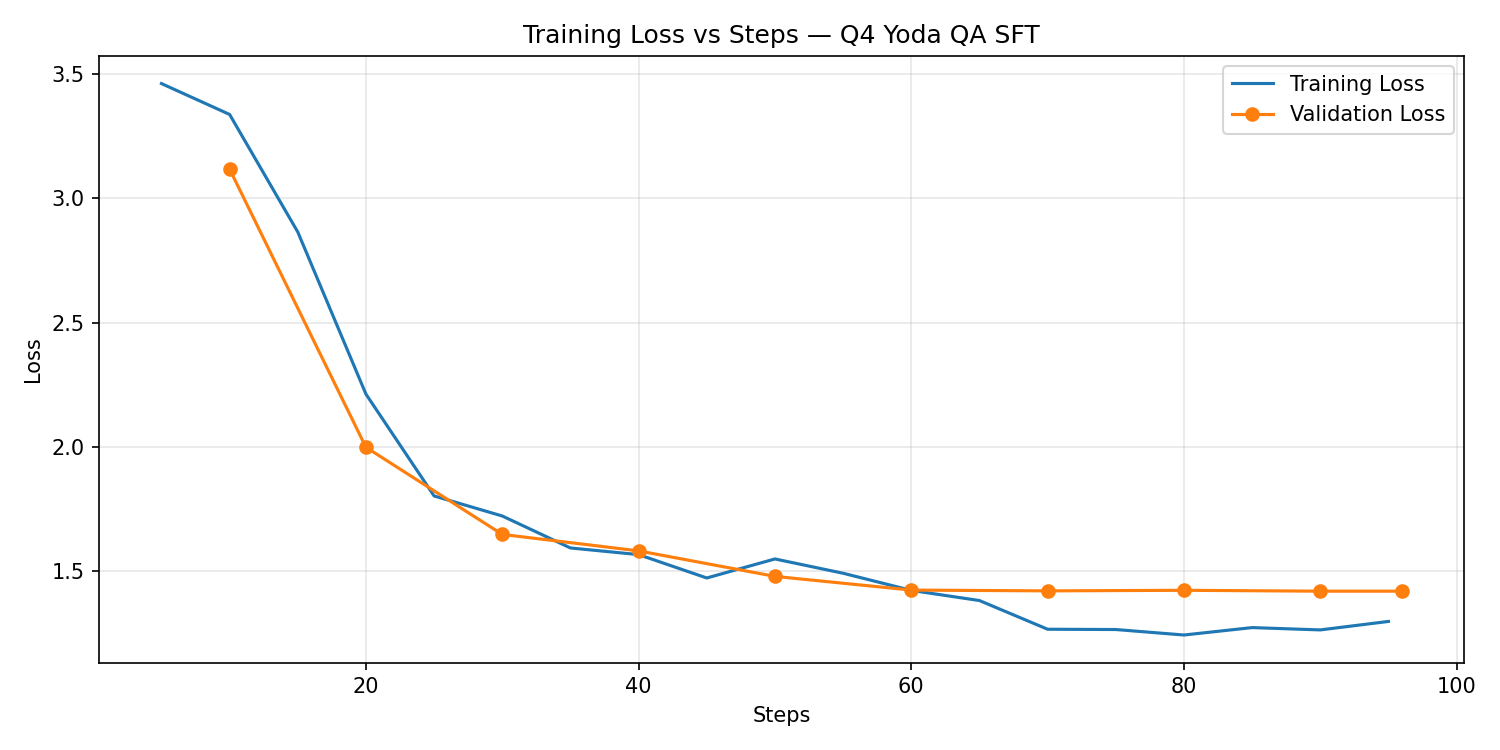

## Q4 Deliverable 2: Validation Loss

- **Final validation loss:** `1.4202280044555664`
- **Best validation loss:** `1.4202280044555664`

## Q4 Deliverable 3: Three Examples Before vs After SFT

### Example 1
**Question:** lucknow congress session 1916 was presided over by—

**Before SFT:**

```
Maharaja of Bikaner, it was.
```

**After SFT:**

```
The Lucknow Session of the Indian National Congress, held from 30 November to 2 December 1916, was. The first session of the party after World War I, it was. In the city of Lucknow, Uttar Pradesh (then known as Avadh), India, held, it was. The first session of the party after World War I, it was. In the city of Lucknow, Uttar Pradesh (then known as Avadh), India, held, it was. The first session of the party after World War I, it was. In the city of Lucknow, Uttar Pradesh (then known as Avadh), India, held, it was. The first session of the party after World War I, it was.
```

### Example 2
**Question:** when did the first chipotle on evans open

**Before SFT:**

```
"1995, it opened."
```

**After SFT:**

```
A fast-casual restaurant chain, Chipotle Mexican Grill is. Founded by Steve Ells in 1993, it was. Headquartered in Newport Beach, California, it is. Over 2,000 locations across the United States and Canada, there are. A menu of burritos, tacos, salads, bowls, and other items, they serve. Sourced ingredients, they do. Animal products from suppliers who treat animals with respect, they require. No added preservatives or flavorings, their food contains. The original location, at 11th Avenue and Evans Avenue in Denver, Colorado, opened, it did. In 2006, to over 500 locations, expanded, it did. To over 1,600 locations
```

### Example 3
**Question:** when did the us start using agent orange in vietnam

**Before SFT:**

```
"1961, US military began spraying Agent Orange over Vietnam."
```

**After SFT:**

```
The herbicide Agent Orange, also known as AO or Orangutans, was used by the United States military during the Vietnam War from March 1961 to May 1971. The chemical mixture of two defoliants, 2,4-D and 2,4,5-T, with an additional contaminant, 2,3,7,8-tetrachlorodibenzo-p-dioxin (TCDD), it consisted. In the early stages of the war, primarily for crop destruction, its use began. Later, for defoliation, its purpose shifted. To destroy crops and foliage, which provided cover for enemy forces, the U.S. military sprayed millions of gallons of the herbicide over South Vietnamese
```


Q4 DONE. Outputs saved to:
./PartA_Q4_outputs/Q4_20260321_232740_UTC
Key files: loss_curve.png, demo_before_after.md, training_log.json, eval_results.json, adapter/
Final train loss: 1.7587
Final val loss: 1.4202280044555664
Best val loss: 1.4202280044555664


In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
Q4 - SFT to Respond like Yoda

Goal: Fine-tune Llama-3.2-3B-Instruct on the synthetic Yoda QA dataset
      so the model can directly answer questions in Yoda-style.

Dataset (from Q3):
  Datasets_3b_processed/yoda_train.csv   (500 samples)
  Datasets_3b_processed/yoda_val.csv     (200 samples)
  Datasets_3b_processed/yoda_test.csv    (500 samples)

Outputs saved to: ./PartA_Q4_outputs/Q4_YYYYMMDD_HHMMSS_UTC/
  - env.json
  - run_config.json
  - adapter/
  - training_log.json
  - loss_curve.png
  - eval_results.json
  - demo_before_after.md
"""

import os
import json
import random
import platform
import warnings
from datetime import datetime
from typing import Any, Dict, List

import torch
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown, Image

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainerCallback,
)
from peft import LoraConfig, get_peft_model
from trl import SFTTrainer, SFTConfig


# =============================================================
# USER SETTINGS
# =============================================================
BASE_MODEL_PATH = "/workspace/tbx/Llama-3.2-3B-Instruct/"

TRAIN_CSV = "Datasets_3b_processed/yoda_train.csv"
VAL_CSV   = "Datasets_3b_processed/yoda_val.csv"
TEST_CSV  = "Datasets_3b_processed/yoda_test.csv"

SEED = 42

# LoRA
LORA_R       = 16
LORA_ALPHA   = 32
LORA_DROPOUT = 0.05

# Training
NUM_EPOCHS             = 3
PER_DEVICE_TRAIN_BATCH = 4
PER_DEVICE_EVAL_BATCH  = 4
GRADIENT_ACCUM_STEPS   = 4
LEARNING_RATE          = 2e-4
WARMUP_STEPS           = 50
LOGGING_STEPS          = 5
EVAL_STEPS             = 10
SAVE_STEPS             = 10
MAX_SEQ_LENGTH         = 512

# Inference
MAX_NEW_TOKENS = 150
TEMPERATURE    = 0.0

OUT_ROOT = "./PartA_Q4_outputs"

os.environ["TOKENIZERS_PARALLELISM"] = "false"
warnings.filterwarnings("ignore")


# =============================================================
# Utils
# =============================================================
def ensure_dir(p: str):
    os.makedirs(p, exist_ok=True)

def set_seed(seed: int):
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def sanitize_json(obj):
    if isinstance(obj, dict):
        return {k: sanitize_json(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [sanitize_json(x) for x in obj]
    if isinstance(obj, torch.dtype):
        return str(obj)
    return obj

def write_json(path: str, obj: Any):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(sanitize_json(obj), f, ensure_ascii=False, indent=2)

def get_env_info() -> Dict[str, Any]:
    info = {
        "timestamp_utc": datetime.utcnow().strftime("%Y-%m-%d %H:%M:%S"),
        "python": platform.python_version(),
        "platform": platform.platform(),
        "torch_version": torch.__version__,
        "cuda_available": torch.cuda.is_available(),
    }
    if torch.cuda.is_available():
        info.update({
            "cuda_device_count": torch.cuda.device_count(),
            "cuda_device_name_0": torch.cuda.get_device_name(0),
            "cuda_capability_0": torch.cuda.get_device_capability(0),
            "cuda_total_vram_mb_0": round(
                torch.cuda.get_device_properties(0).total_memory / (1024**2), 1
            ),
        })
    return info

def check_required_columns(df: pd.DataFrame, required_cols: List[str], df_name: str):
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(
            f"{df_name} is missing required columns: {missing}\n"
            f"Available columns: {df.columns.tolist()}"
        )

def safe_get(row: Dict[str, Any], key: str, default=None):
    v = row.get(key, default)
    if pd.isna(v) if isinstance(v, float) else False:
        return default
    return v


# =============================================================
# Prompt template
# =============================================================
def get_system_prompt() -> str:
    return (
        "You are a helpful assistant that always responds in concise Yoda-style English. "
        "Answer the question directly. "
        "Do not add extra background information. "
        "Do not repeat yourself. "
        "Keep the response short."
    )

def build_training_prompt(row: Dict[str, Any]) -> str:
    system = get_system_prompt()
    user = row["question"]
    assistant = row["answer_yoda"]

    prompt = (
        f"<|begin_of_text|>"
        f"<|start_header_id|>system<|end_header_id|>\n\n{system}<|eot_id|>"
        f"<|start_header_id|>user<|end_header_id|>\n\n{user}<|eot_id|>"
        f"<|start_header_id|>assistant<|end_header_id|>\n\n{assistant}<|eot_id|>"
    )
    return prompt

def build_inference_prompt(tokenizer, question: str) -> str:
    system = get_system_prompt()
    messages = [
        {"role": "system", "content": system},
        {"role": "user", "content": question},
    ]
    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )


# =============================================================
# Loss logging callback
# =============================================================
class LossLoggerCallback(TrainerCallback):
    def __init__(self):
        self.train_log: List[Dict[str, Any]] = []
        self.eval_log: List[Dict[str, Any]] = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is None:
            return
        if "loss" in logs and "eval_loss" not in logs:
            self.train_log.append({
                "step": state.global_step,
                "loss": float(logs["loss"]),
            })
        if "eval_loss" in logs:
            self.eval_log.append({
                "step": state.global_step,
                "eval_loss": float(logs["eval_loss"]),
            })


# =============================================================
# Inference helper
# =============================================================
@torch.no_grad()
def run_inference(model, tokenizer, question: str) -> str:
    old_padding_side = tokenizer.padding_side
    tokenizer.padding_side = "left"

    prompt = build_inference_prompt(tokenizer, question)
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_SEQ_LENGTH,
    ).to(model.device)

    eot_id = tokenizer.convert_tokens_to_ids("<|eot_id|>")
    eos_ids = [tokenizer.eos_token_id]
    if eot_id is not None and isinstance(eot_id, int) and eot_id >= 0 and eot_id not in eos_ids:
        eos_ids.append(eot_id)

    gen_kwargs = dict(
        max_new_tokens=MAX_NEW_TOKENS,
        do_sample=(TEMPERATURE > 0),
        temperature=TEMPERATURE if TEMPERATURE > 0 else None,
        repetition_penalty=1.15,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=eos_ids,
    )

    # 去掉 None，避免某些版本 generate 报参数问题
    gen_kwargs = {k: v for k, v in gen_kwargs.items() if v is not None}

    out = model.generate(**inputs, **gen_kwargs)
    input_len = inputs["input_ids"].shape[1]
    generated_ids = out[0][input_len:]

    text = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()
    text = text.replace("<|eot_id|>", "").strip()

    tokenizer.padding_side = old_padding_side
    return text


# =============================================================
# Plot loss curve
# =============================================================
def plot_loss(train_log, eval_log, save_path: str):
    train_steps  = [e["step"] for e in train_log]
    train_losses = [e["loss"] for e in train_log]
    eval_steps   = [e["step"] for e in eval_log]
    eval_losses  = [e["eval_loss"] for e in eval_log]

    plt.figure(figsize=(10, 5))
    if len(train_steps) > 0:
        plt.plot(train_steps, train_losses, label="Training Loss", linewidth=1.5)
    if len(eval_steps) > 0:
        plt.plot(eval_steps, eval_losses, label="Validation Loss", marker="o", linewidth=1.5)
    plt.xlabel("Steps")
    plt.ylabel("Loss")
    plt.title("Training Loss vs Steps — Q4 Yoda QA SFT")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.close()


# =============================================================
# Main
# =============================================================
def main():
    set_seed(SEED)

    run_id = datetime.utcnow().strftime("Q4_%Y%m%d_%H%M%S_UTC")
    out_dir = os.path.join(OUT_ROOT, run_id)
    ensure_dir(out_dir)
    adapter_dir = os.path.join(out_dir, "adapter")
    checkpoints_dir = os.path.join(out_dir, "checkpoints")
    ensure_dir(checkpoints_dir)

    write_json(os.path.join(out_dir, "env.json"), get_env_info())
    write_json(os.path.join(out_dir, "run_config.json"), {
        "base_model_path": BASE_MODEL_PATH,
        "train_csv": TRAIN_CSV,
        "val_csv": VAL_CSV,
        "test_csv": TEST_CSV,
        "seed": SEED,
        "lora": {
            "r": LORA_R,
            "alpha": LORA_ALPHA,
            "dropout": LORA_DROPOUT,
        },
        "training": {
            "num_epochs": NUM_EPOCHS,
            "per_device_train_batch": PER_DEVICE_TRAIN_BATCH,
            "per_device_eval_batch": PER_DEVICE_EVAL_BATCH,
            "gradient_accum_steps": GRADIENT_ACCUM_STEPS,
            "effective_batch_size": PER_DEVICE_TRAIN_BATCH * GRADIENT_ACCUM_STEPS,
            "learning_rate": LEARNING_RATE,
            "warmup_steps": WARMUP_STEPS,
            "max_seq_length": MAX_SEQ_LENGTH,
            "logging_steps": LOGGING_STEPS,
            "eval_steps": EVAL_STEPS,
            "save_steps": SAVE_STEPS,
        },
        "inference": {
            "max_new_tokens": MAX_NEW_TOKENS,
            "temperature": TEMPERATURE,
            "repetition_penalty": 1.15,
        },
    })

    os.environ["HF_HUB_OFFLINE"] = "1"
    os.environ["HF_DATASETS_OFFLINE"] = "1"

    for p in [TRAIN_CSV, VAL_CSV, TEST_CSV]:
        if not os.path.exists(p):
            raise FileNotFoundError(f"Dataset file not found: {p}")

    train_df = pd.read_csv(TRAIN_CSV)
    val_df   = pd.read_csv(VAL_CSV)
    test_df  = pd.read_csv(TEST_CSV)

    check_required_columns(train_df, ["question", "answer_yoda"], "train_df")
    check_required_columns(val_df,   ["question", "answer_yoda"], "val_df")
    check_required_columns(test_df,  ["question"], "test_df")

    def format_df(df: pd.DataFrame) -> Dataset:
        records = df.to_dict(orient="records")
        texts = [build_training_prompt(r) for r in records]
        return Dataset.from_dict({"text": texts})

    train_dataset = format_df(train_df)
    val_dataset   = format_df(val_df)

    if torch.cuda.is_available():
        major, _ = torch.cuda.get_device_capability(0)
        dtype = torch.bfloat16 if major >= 8 else torch.float16
    else:
        dtype = torch.float32

    if not os.path.exists(BASE_MODEL_PATH):
        raise FileNotFoundError(f"Base model not found: {BASE_MODEL_PATH}")

    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_PATH, use_fast=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "right"

    model = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL_PATH,
        torch_dtype=dtype,
        device_map="auto" if torch.cuda.is_available() else None,
    )
    model.config.pad_token_id = tokenizer.pad_token_id
    model.config.use_cache = False

    lora_config = LoraConfig(
        r=LORA_R,
        lora_alpha=LORA_ALPHA,
        target_modules=[
            "q_proj", "k_proj",
            "v_proj", "o_proj",
            "gate_proj", "up_proj", "down_proj",
        ],
        lora_dropout=LORA_DROPOUT,
        bias="none",
        task_type="CAUSAL_LM",
    )
    model = get_peft_model(model, lora_config)

    # BEFORE-SFT examples
    model.eval()
    test_samples = test_df.head(3).to_dict(orient="records")
    before_outputs = [run_inference(model, tokenizer, row["question"]) for row in test_samples]

    loss_logger = LossLoggerCallback()

    training_args = SFTConfig(
        output_dir=checkpoints_dir,
        num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=PER_DEVICE_TRAIN_BATCH,
        per_device_eval_batch_size=PER_DEVICE_EVAL_BATCH,
        gradient_accumulation_steps=GRADIENT_ACCUM_STEPS,
        warmup_steps=WARMUP_STEPS,
        learning_rate=LEARNING_RATE,
        bf16=(dtype == torch.bfloat16),
        fp16=(dtype == torch.float16),
        logging_steps=LOGGING_STEPS,
        eval_strategy="steps",
        eval_steps=EVAL_STEPS,
        save_strategy="steps",
        save_steps=SAVE_STEPS,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        report_to="none",
        dataset_text_field="text",
        max_seq_length=MAX_SEQ_LENGTH,
        seed=SEED,
        disable_tqdm=True,
    )

    trainer = SFTTrainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        processing_class=tokenizer,
    )
    trainer.add_callback(loss_logger)

    train_result = trainer.train()

    trainer.model.save_pretrained(adapter_dir)
    tokenizer.save_pretrained(adapter_dir)

    final_train_loss = float(train_result.training_loss)

    # 再主动 eval 一次，确保最终值一定拿到
    eval_metrics = trainer.evaluate()
    final_val_loss = float(eval_metrics["eval_loss"]) if "eval_loss" in eval_metrics else None

    eval_losses_only = [e["eval_loss"] for e in loss_logger.eval_log]
    if final_val_loss is not None:
        eval_losses_only = eval_losses_only + [final_val_loss]

    best_val_loss = min(eval_losses_only) if len(eval_losses_only) > 0 else None

    write_json(os.path.join(out_dir, "training_log.json"), {
        "train_log": loss_logger.train_log,
        "eval_log": loss_logger.eval_log,
        "final_train_loss": final_train_loss,
        "final_val_loss": final_val_loss,
        "best_val_loss": best_val_loss,
    })

    loss_curve_path = os.path.join(out_dir, "loss_curve.png")
    plot_loss(
        loss_logger.train_log,
        loss_logger.eval_log,
        save_path=loss_curve_path,
    )

    # AFTER-SFT examples
    trainer.model.eval()
    after_outputs = [run_inference(trainer.model, tokenizer, row["question"]) for row in test_samples]

    eval_records = []
    for i, row in enumerate(test_samples):
        eval_records.append({
            "id": safe_get(row, "id", f"sample_{i}"),
            "source_id": safe_get(row, "source_id", None),
            "question": safe_get(row, "question", ""),
            "answer_key": safe_get(row, "answer_key", None),
            "answer_original": safe_get(row, "answer_original", None),
            "question_concept": safe_get(row, "question_concept", None),
            "answer_yoda_ref": safe_get(row, "answer_yoda", None),
            "before_sft": before_outputs[i],
            "after_sft": after_outputs[i],
        })
    write_json(os.path.join(out_dir, "eval_results.json"), eval_records)

    md = []
    md.append("# Q4 Deliverable — SFT to Respond like Yoda\n")
    md.append(f"- Base model: `{BASE_MODEL_PATH}`")
    md.append(f"- Train samples: {len(train_df)}")
    md.append(f"- Val samples: {len(val_df)}")
    md.append(f"- Test samples: {len(test_df)}")
    md.append(f"- Final train loss: `{final_train_loss:.4f}`")
    md.append(f"- Final val loss: `{final_val_loss}`")
    md.append(f"- Best val loss: `{best_val_loss}`")
    md.append("")
    md.append("## Before vs After SFT (3 Test Examples)\n")

    for i, (row, before, after) in enumerate(zip(test_samples, before_outputs, after_outputs), 1):
        q = safe_get(row, "question", "")
        answer_original = safe_get(row, "answer_original", "N/A")
        answer_key = safe_get(row, "answer_key", "N/A")
        answer_yoda_ref = safe_get(row, "answer_yoda", "N/A")

        md.append(f"### Example {i}")
        md.append("**Question:**")
        md.append("```")
        md.append(str(q))
        md.append("```")
        md.append(f"**Correct answer:** {answer_original} (key: {answer_key})")
        md.append("")
        md.append("**Reference Yoda answer:**")
        md.append("```")
        md.append(str(answer_yoda_ref))
        md.append("```")
        md.append("")
        md.append("**Before SFT:**")
        md.append("```")
        md.append(str(before))
        md.append("```")
        md.append("**After SFT:**")
        md.append("```")
        md.append(str(after))
        md.append("```")
        md.append("")

    with open(os.path.join(out_dir, "demo_before_after.md"), "w", encoding="utf-8") as f:
        f.write("\n".join(md))

    # Jupyter deliverables
    display(Markdown("## Q4 Deliverable 1: Training Loss vs Steps"))
    if os.path.exists(loss_curve_path):
        display(Image(filename=loss_curve_path))
    else:
        print("loss_curve.png was not generated.")

    display(Markdown("## Q4 Deliverable 2: Validation Loss"))
    display(Markdown(
        f"- **Final validation loss:** `{final_val_loss}`\n"
        f"- **Best validation loss:** `{best_val_loss}`"
    ))

    display(Markdown("## Q4 Deliverable 3: Three Examples Before vs After SFT"))
    for i, row in enumerate(test_samples, 1):
        display(Markdown(
            f"### Example {i}\n"
            f"**Question:** {safe_get(row, 'question', '')}\n\n"
            f"**Before SFT:**\n\n```\n{before_outputs[i-1]}\n```\n\n"
            f"**After SFT:**\n\n```\n{after_outputs[i-1]}\n```"
        ))

    print(f"\nQ4 DONE. Outputs saved to:\n{out_dir}")
    print("Key files: loss_curve.png, demo_before_after.md, training_log.json, eval_results.json, adapter/")
    print(f"Final train loss: {final_train_loss:.4f}")
    print(f"Final val loss: {final_val_loss}")
    print(f"Best val loss: {best_val_loss}")


if __name__ == "__main__":
    main()

# PartB

## PartB Q1

Balanced train-source dataframe preview:
                                                text  label
0  Hynden Walch, she is best known for voicing Pr...      1
1  The winner of the competition, 30-year-old Lis...      1
2  Against the more comprehensive Civil Rights Ac...      1
3  A concept album, Jesus of Suburbia American Id...      1
4  Hubert Ogunde Oloye Hubert Adedeji Ogunde (10 ...      0

Label counts:
label
1    500
0    500
Name: count, dtype: int64


Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'loss': '0.6855', 'grad_norm': '2.41', 'learning_rate': '4.85e-05', 'epoch': '0.2'}
{'loss': '0.4143', 'grad_norm': '1.903', 'learning_rate': '4.683e-05', 'epoch': '0.4'}
{'loss': '0.2778', 'grad_norm': '3.972', 'learning_rate': '4.517e-05', 'epoch': '0.6'}
{'loss': '0.304', 'grad_norm': '3.087', 'learning_rate': '4.35e-05', 'epoch': '0.8'}
{'loss': '0.1052', 'grad_norm': '1.44', 'learning_rate': '4.183e-05', 'epoch': '1'}
{'eval_loss': '0.1373', 'eval_accuracy': '0.94', 'eval_runtime': '0.1776', 'eval_samples_per_second': '1126', 'eval_steps_per_second': '73.19', 'epoch': '1'}
{'loss': '0.05893', 'grad_norm': '0.1776', 'learning_rate': '4.017e-05', 'epoch': '1.2'}
{'loss': '0.3632', 'grad_norm': '1.04', 'learning_rate': '3.85e-05', 'epoch': '1.4'}
{'loss': '0.1744', 'grad_norm': '11.71', 'learning_rate': '3.683e-05', 'epoch': '1.6'}
{'loss': '0.07255', 'grad_norm': '2.251', 'learning_rate': '3.517e-05', 'epoch': '1.8'}
{'loss': '0.06138', 'grad_norm': '0.1963', 'learning_rate': '3.35

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'eval_loss': '0.0868', 'eval_accuracy': '0.978', 'eval_runtime': '0.8787', 'eval_samples_per_second': '1138', 'eval_steps_per_second': '71.69', 'epoch': '6'}


## Part B Q1 Deliverable 1: Training Loss vs. Steps

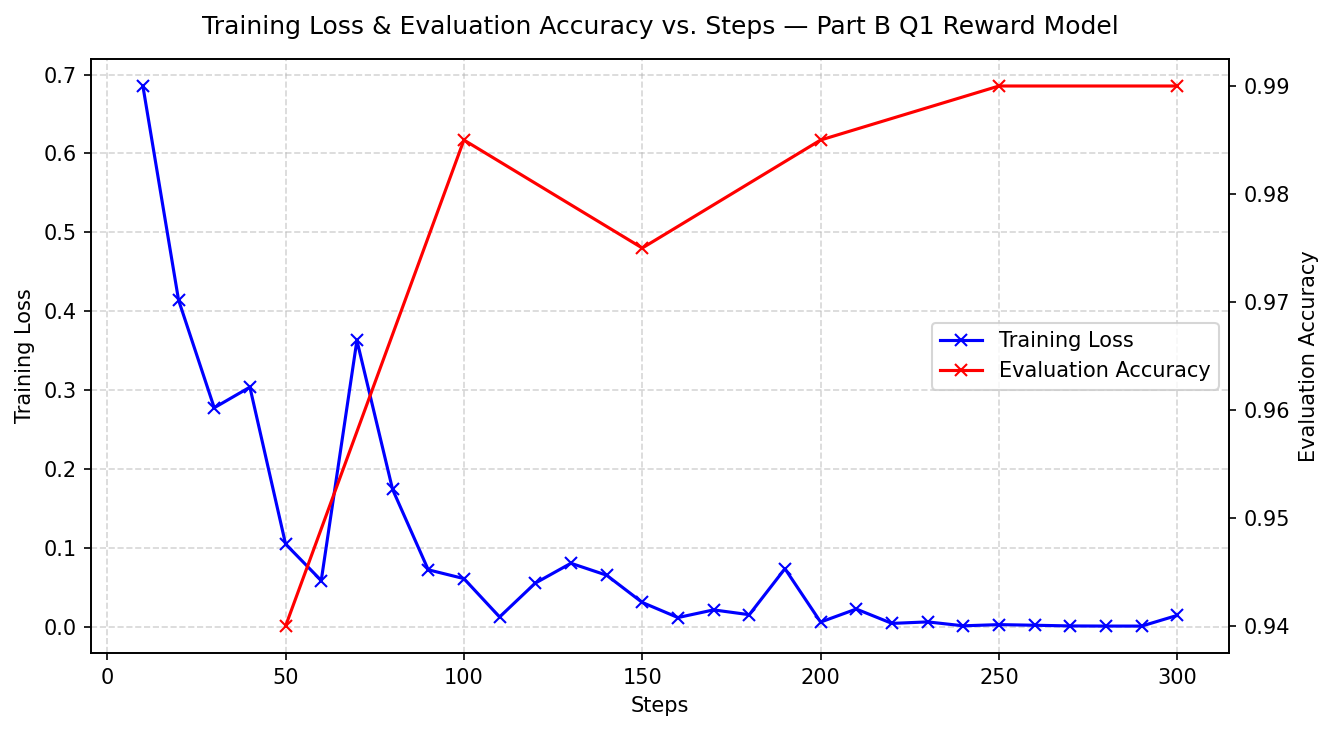

## Part B Q1 Deliverable 2: Accuracy on Held-out Test Set

**Test accuracy:** `0.978`


Part B Q1 DONE. Outputs saved to:
./PartB_Q1_outputs/PartB_Q1_20260322_165817_UTC
Key files: loss_curve.png, eval_results.json, training_log.json, classifier/
Test accuracy: 0.978


In [3]:
# -*- coding: utf-8 -*-

"""
Part B - Q1: Reward Model Training

Task:
Train a binary classifier to identify Yoda-style text.

Dataset assumption:
- yoda_train.csv
- yoda_test.csv

Each CSV should contain:
- answer_original
- answer_yoda

Outputs saved to:
./PartB_Q1_outputs/PartB_Q1_YYYYMMDD_HHMMSS_UTC/
  - env.json
  - run_config.json
  - training_log.json
  - loss_curve.png
  - eval_results.json
  - classifier/
"""
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import json
import random
import platform
import warnings
from datetime import datetime
from typing import Any, Dict

import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

from IPython.display import display, Markdown, Image

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"


# ============================================================
# USER SETTINGS
# ============================================================
TRAIN_CSV = "./Datasets_3b_processed/yoda_train.csv"
TEST_CSV  = "./Datasets_3b_processed/yoda_test.csv"

BASE_MODEL_NAME = "distilbert-base-uncased"

SEED = 42
MAX_LENGTH = 128
NUM_EPOCHS = 6
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE = 16
LOGGING_STEPS = 10

OUT_ROOT = "./PartB_Q1_outputs"


# ============================================================
# Utils
# ============================================================
def ensure_dir(path: str):
    os.makedirs(path, exist_ok=True)

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def sanitize_json(obj):
    if isinstance(obj, dict):
        return {k: sanitize_json(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [sanitize_json(x) for x in obj]
    if isinstance(obj, np.generic):
        return obj.item()
    return obj

def write_json(path: str, obj: Any):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(sanitize_json(obj), f, ensure_ascii=False, indent=2)

def get_env_info() -> Dict[str, Any]:
    info = {
        "timestamp_utc": datetime.utcnow().strftime("%Y-%m-%d %H:%M:%S"),
        "python": platform.python_version(),
        "platform": platform.platform(),
        "torch_version": torch.__version__,
        "cuda_available": torch.cuda.is_available(),
    }
    if torch.cuda.is_available():
        info.update({
            "cuda_device_count": torch.cuda.device_count(),
            "cuda_device_name_0": torch.cuda.get_device_name(0),
            "cuda_total_vram_mb_0": round(
                torch.cuda.get_device_properties(0).total_memory / (1024**2), 1
            ),
        })
    return info

def check_required_columns(df: pd.DataFrame, required_cols, df_name: str):
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(
            f"{df_name} is missing required columns: {missing}\n"
            f"Available columns: {df.columns.tolist()}"
        )


# ============================================================
# Dataset preparation
# ============================================================
def make_balanced_df(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    check_required_columns(df, ["answer_original", "answer_yoda"], path)

    balanced = pd.concat([
        pd.DataFrame({"text": df["answer_original"], "label": 0}),
        pd.DataFrame({"text": df["answer_yoda"], "label": 1}),
    ], ignore_index=True)

    balanced = (
        balanced
        .dropna()
        .sample(frac=1, random_state=SEED)
        .reset_index(drop=True)
    )
    return balanced


def tokenize_dataset(ds: Dataset, tokenizer):
    return ds.map(
        lambda x: tokenizer(
            x["text"],
            truncation=True,
            padding="max_length",
            max_length=MAX_LENGTH,
        ),
        batched=True,
    )


# ============================================================
# Metrics
# ============================================================
def compute_metrics(eval_pred):
    preds = np.argmax(eval_pred.predictions, axis=1)
    acc = accuracy_score(eval_pred.label_ids, preds)
    return {"accuracy": acc}


# ============================================================
# Plot
# ============================================================
def plot_training_loss(logs, save_path: str):
    train_logs = [x for x in logs if "loss" in x and "eval_loss" not in x]
    steps = [x["step"] for x in train_logs]
    losses = [x["loss"] for x in train_logs]

    eval_logs = [x for x in logs if "eval_accuracy" in x]
    eval_steps = [x["step"] for x in eval_logs]
    eval_accs = [x["eval_accuracy"] for x in eval_logs]

    fig, ax1 = plt.subplots(figsize=(9, 5))
    ax1.plot(steps, losses, color="blue", marker="x", linewidth=1.5, label="Training Loss")
    ax1.set_xlabel("Steps")
    ax1.set_ylabel("Training Loss")
    ax1.grid(True, linestyle="--", alpha=0.5)

    ax2 = ax1.twinx()
    ax2.plot(eval_steps, eval_accs, color="red", marker="x", linewidth=1.5, label="Evaluation Accuracy")
    ax2.set_ylabel("Evaluation Accuracy")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")

    plt.title("Training Loss & Evaluation Accuracy vs. Steps — Part B Q1 Reward Model", pad=12)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close()

# ============================================================
# Main
# ============================================================
def main():
    set_seed(SEED)

    run_id = datetime.utcnow().strftime("PartB_Q1_%Y%m%d_%H%M%S_UTC")
    out_dir = os.path.join(OUT_ROOT, run_id)
    ensure_dir(out_dir)

    classifier_dir = os.path.join(out_dir, "classifier")
    ensure_dir(classifier_dir)

    write_json(os.path.join(out_dir, "env.json"), get_env_info())
    write_json(os.path.join(out_dir, "run_config.json"), {
        "train_csv": TRAIN_CSV,
        "test_csv": TEST_CSV,
        "base_model_name": BASE_MODEL_NAME,
        "seed": SEED,
        "max_length": MAX_LENGTH,
        "num_epochs": NUM_EPOCHS,
        "train_batch_size": TRAIN_BATCH_SIZE,
        "eval_batch_size": EVAL_BATCH_SIZE,
        "logging_steps": LOGGING_STEPS,
        "label_definition": {
            "0": "standard English",
            "1": "Yoda-style English",
        }
    })

    if not os.path.exists(TRAIN_CSV):
        raise FileNotFoundError(f"Training CSV not found: {TRAIN_CSV}")
    if not os.path.exists(TEST_CSV):
        raise FileNotFoundError(f"Test CSV not found: {TEST_CSV}")

    # Build balanced datasets
    balanced_df = make_balanced_df(TRAIN_CSV)
    test_df = make_balanced_df(TEST_CSV)

    print("Balanced train-source dataframe preview:")
    print(balanced_df.head())
    print("\nLabel counts:")
    print(balanced_df["label"].value_counts())

    # Train/val split
    train_df, val_df = train_test_split(
        balanced_df,
        test_size=0.2,
        random_state=SEED,
        stratify=balanced_df["label"],
    )

    train_ds = Dataset.from_pandas(train_df.reset_index(drop=True))
    val_ds   = Dataset.from_pandas(val_df.reset_index(drop=True))
    test_ds  = Dataset.from_pandas(test_df.reset_index(drop=True))

    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_NAME)

    train_ds = tokenize_dataset(train_ds, tokenizer)
    val_ds   = tokenize_dataset(val_ds, tokenizer)
    test_ds  = tokenize_dataset(test_ds, tokenizer)

    train_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])
    val_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])
    test_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])

    model = AutoModelForSequenceClassification.from_pretrained(
        BASE_MODEL_NAME,
        num_labels=2
    )

    training_args = TrainingArguments(
        output_dir=os.path.join(out_dir, "checkpoints"),
        eval_strategy="epoch",
        save_strategy="no",
        logging_steps=LOGGING_STEPS,
        num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        report_to="none",
        seed=SEED,
        disable_tqdm=True,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        compute_metrics=compute_metrics,
    )

    trainer.train()

    # Save classifier
    trainer.save_model(classifier_dir)
    tokenizer.save_pretrained(classifier_dir)

    # Logs
    logs = trainer.state.log_history
    write_json(os.path.join(out_dir, "training_log.json"), logs)

    # Plot training loss
    loss_curve_path = os.path.join(out_dir, "loss_curve.png")
    plot_training_loss(logs, loss_curve_path)

    # Test evaluation
    test_results = trainer.evaluate(test_ds)
    eval_results = {
        "test_accuracy": test_results.get("eval_accuracy", None),
        "full_test_metrics": test_results,
        "dataset_sizes": {
            "balanced_train_source_total": len(balanced_df),
            "train_split": len(train_df),
            "val_split": len(val_df),
            "balanced_test_total": len(test_df),
        }
    }
    write_json(os.path.join(out_dir, "eval_results.json"), eval_results)

    # Jupyter display
    display(Markdown("## Part B Q1 Deliverable 1: Training Loss vs. Steps"))
    if os.path.exists(loss_curve_path):
        display(Image(filename=loss_curve_path))
    else:
        print("loss_curve.png was not generated.")

    display(Markdown("## Part B Q1 Deliverable 2: Accuracy on Held-out Test Set"))
    display(Markdown(
        f"**Test accuracy:** `{eval_results['test_accuracy']}`"
    ))

    print(f"\nPart B Q1 DONE. Outputs saved to:\n{out_dir}")
    print("Key files: loss_curve.png, eval_results.json, training_log.json, classifier/")
    print("Test accuracy:", eval_results["test_accuracy"])


if __name__ == "__main__":
    main()

## PartB Q2

In [5]:
# -*- coding: utf-8 -*-

"""
Part B - Q2: Reward Function Design

Task:
Design and implement a reward function that is a linear combination of:
1. Correctness reward
2. Format reward
3. Style reward

Deliverable:
Show reward scores (all three components plus total) for 3 diverse responses.
Explain why each component is necessary and whether the obtained rewards match expectations.

Outputs saved to:
./PartB_Q2_outputs/PartB_Q2_YYYYMMDD_HHMMSS_UTC/
  - env.json
  - run_config.json
  - reward_examples.json
  - analysis.md
"""

import os
import re
import json
import platform
import warnings
from datetime import datetime
from typing import Any, Dict, List
from pathlib import Path

import torch
from sentence_transformers import SentenceTransformer, util
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"


# ============================================================
# USER SETTINGS
# ============================================================
SEMANTIC_MODEL_NAME = "all-MiniLM-L6-v2"

OUT_ROOT = "./PartB_Q2_outputs"

# Reward weights
W_CORRECT = 0.4
W_FORMAT  = 0.2
W_STYLE   = 0.4


# ============================================================
# Utils
# ============================================================
def ensure_dir(path: str):
    os.makedirs(path, exist_ok=True)

def sanitize_json(obj):
    if isinstance(obj, dict):
        return {k: sanitize_json(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [sanitize_json(x) for x in obj]
    if isinstance(obj, torch.Tensor):
        return obj.detach().cpu().tolist()
    return obj

def write_json(path: str, obj: Any):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(sanitize_json(obj), f, ensure_ascii=False, indent=2)

def get_env_info() -> Dict[str, Any]:
    info = {
        "timestamp_utc": datetime.utcnow().strftime("%Y-%m-%d %H:%M:%S"),
        "python": platform.python_version(),
        "platform": platform.platform(),
        "torch_version": torch.__version__,
        "cuda_available": torch.cuda.is_available(),
    }
    if torch.cuda.is_available():
        info.update({
            "cuda_device_count": torch.cuda.device_count(),
            "cuda_device_name_0": torch.cuda.get_device_name(0),
        })
    return info

def find_latest_q1_classifier(base_dir="./PartB_Q1_outputs") -> str:
    base = Path(base_dir)
    if not base.exists():
        raise FileNotFoundError(f"Q1 output folder not found: {base_dir}")

    run_dirs = sorted(
        [p for p in base.iterdir() if p.is_dir() and p.name.startswith("PartB_Q1_")],
        key=lambda p: p.name,
        reverse=True,
    )
    if not run_dirs:
        raise FileNotFoundError(f"No PartB_Q1_* folders found under: {base_dir}")

    classifier_dir = run_dirs[0] / "classifier"
    if not classifier_dir.exists():
        raise FileNotFoundError(f"Classifier folder not found: {classifier_dir}")

    return str(classifier_dir)


# ============================================================
# Load models
# ============================================================
semantic_model = SentenceTransformer(SEMANTIC_MODEL_NAME)

STYLE_MODEL_PATH = find_latest_q1_classifier()
print("Using style model from:", STYLE_MODEL_PATH)

tok = AutoTokenizer.from_pretrained(STYLE_MODEL_PATH)
style_model = AutoModelForSequenceClassification.from_pretrained(STYLE_MODEL_PATH)
style_model.eval()


# ============================================================
# Reward 1: Correctness
# ============================================================
def correctness_reward(response: str, gold_answer: str, task_type: str) -> float:
    if task_type == "math":
        p_nums = re.findall(r"-?\d+(?:\.\d+)?", response)
        g_nums = re.findall(r"-?\d+(?:\.\d+)?", gold_answer)
        return 1.0 if (p_nums and g_nums and float(p_nums[-1]) == float(g_nums[-1])) else 0.0

    elif task_type == "mcq":
        p_match = re.search(r"\b[A-E]\b", response.upper())
        g_match = re.search(r"\b[A-E]\b", gold_answer.upper())
        return 1.0 if (p_match and g_match and p_match.group() == g_match.group()) else 0.0

    elif task_type == "yoda":
        resp_emb = semantic_model.encode(response, convert_to_tensor=True)
        gold_emb = semantic_model.encode(gold_answer, convert_to_tensor=True)
        sim = util.cos_sim(resp_emb, gold_emb).item()
        return max(0.0, sim)

    return 0.0


# ============================================================
# Reward 2: Format
# ============================================================
def format_reward(response: str, task_type: str = "yoda") -> float:
    response = response.strip()
    if not response:
        return 0.0

    score = 0.0

    # 1/3 — mostly printable chars
    printable_ratio = sum(1 for c in response if c.isprintable()) / max(len(response), 1)
    if printable_ratio >= 0.95:
        score += 1 / 3

    # 1/3 — sentence capitalisation
    sentences = [s for s in re.split(r"[.!?]+\s*", response) if s.strip()]
    if sentences and all(s.strip()[0].isupper() for s in sentences):
        score += 1 / 3

    # 1/3 — ends with punctuation
    if re.search(r"[.!?]$", response):
        score += 1 / 3

    return score


# ============================================================
# Reward 3: Style
# ============================================================
def style_reward(text: str) -> float:
    inputs = tok(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )
    with torch.no_grad():
        logits = style_model(**inputs).logits
        probs = torch.softmax(logits, dim=1)

    # map P(Yoda) from [0.5, 1.0] -> [0, 1], clamp below 0.5 to 0
    return max(0.0, probs[0, 1].item() - 0.5) * 2


# ============================================================
# Composite reward
# ============================================================
def composite_reward(
    response: str,
    gold_answer: str,
    task_type: str = "yoda",
    w_correct: float = W_CORRECT,
    w_format: float = W_FORMAT,
    w_style: float = W_STYLE,
) -> Dict[str, float]:

    c_score = correctness_reward(response, gold_answer, task_type)
    f_score = format_reward(response, task_type)
    s_score = style_reward(response)

    total_score = (w_correct * c_score) + (w_format * f_score) + (w_style * s_score)

    return {
        "correctness_reward": float(c_score),
        "format_reward": float(f_score),
        "style_reward": float(s_score),
        "total_reward": float(total_score),
    }


# ============================================================
# Main
# ============================================================
def main():
    run_id = datetime.utcnow().strftime("PartB_Q2_%Y%m%d_%H%M%S_UTC")
    out_dir = os.path.join(OUT_ROOT, run_id)
    ensure_dir(out_dir)

    write_json(os.path.join(out_dir, "env.json"), get_env_info())
    write_json(os.path.join(out_dir, "run_config.json"), {
        "style_model_path": STYLE_MODEL_PATH,
        "semantic_model_name": SEMANTIC_MODEL_NAME,
        "weights": {
            "correctness": W_CORRECT,
            "format": W_FORMAT,
            "style": W_STYLE,
        },
        "reward_definition": {
            "correctness": "Task-dependent verification: numeric match for math, option match for MCQ, semantic similarity for Yoda task.",
            "format": "Rule-based reward for printable text, sentence capitalisation, and ending punctuation.",
            "style": "Classifier-based Yoda-style probability from Part B Q1 reward model.",
        }
    })

    gold_ans = "A Jedi uses the Force for knowledge and defense."
    task = "yoda"

    examples = [
        "For knowledge and defense, the Force a Jedi uses.",
        "A Jedi uses the Force for knowledge and defense.",
        "The turning radius or turning circle of a vehicle, the radius of the smallest circular turn that the vehicle is capable of making, is."
    ]

    reward_records: List[Dict[str, Any]] = []

    print("Q2 Answer:")
    print("Reward Scores for 3 Diverse Responses:\n")

    for i, resp in enumerate(examples, 1):
        scores = composite_reward(resp, gold_ans, task)

        record = {
            "example_id": i,
            "task_type": task,
            "gold_answer": gold_ans,
            "response": resp,
            **scores,
        }
        reward_records.append(record)

        print(f"Example {i}:")
        print(f"Response: {resp}")
        print(f"Correctness Reward: {scores['correctness_reward']:.4f}")
        print(f"Format Reward: {scores['format_reward']:.4f}")
        print(f"Style Reward: {scores['style_reward']:.4f}")
        print(f"Total Reward: {scores['total_reward']:.4f}")
        print()

    write_json(os.path.join(out_dir, "reward_examples.json"), reward_records)

    analysis_md = []
    analysis_md.append("# Part B Q2 — Reward Function Design\n")
    analysis_md.append("## Why each component is necessary\n")
    analysis_md.append("**Correctness reward** ensures that the response actually answers the task correctly rather than only sounding fluent or stylistically appropriate.\n")
    analysis_md.append("**Format reward** encourages outputs that are complete and well-formed, reducing truncated, malformed, or badly structured responses.\n")
    analysis_md.append("**Style reward** encourages adherence to Yoda-style expression, which is important because correctness alone does not guarantee the required stylistic form.\n")

    analysis_md.append("## Do the obtained rewards match expectations?\n")
    analysis_md.append("Yes, broadly they should. A good Yoda-style answer that preserves the original meaning should receive high correctness and style rewards, and usually a good format reward as well. ")
    analysis_md.append("A fluent but standard-English response should still score well on correctness and format, but lower on style. ")
    analysis_md.append("An unrelated response may still receive some format reward if it is grammatically complete, but should receive a much lower correctness score and usually a lower total reward overall.\n")

    analysis_md.append("## Reward Scores for 3 Diverse Responses\n")
    for r in reward_records:
        analysis_md.append(f"### Example {r['example_id']}")
        analysis_md.append(f"**Response:** {r['response']}")
        analysis_md.append(f"- Correctness Reward: `{r['correctness_reward']:.4f}`")
        analysis_md.append(f"- Format Reward: `{r['format_reward']:.4f}`")
        analysis_md.append(f"- Style Reward: `{r['style_reward']:.4f}`")
        analysis_md.append(f"- Total Reward: `{r['total_reward']:.4f}`")
        analysis_md.append("")

    with open(os.path.join(out_dir, "analysis.md"), "w", encoding="utf-8") as f:
        f.write("\n".join(analysis_md))

    display(Markdown("## Part B Q2 Deliverable: Reward Scores for 3 Diverse Responses"))
    for r in reward_records:
        display(Markdown(
            f"### Example {r['example_id']}\n"
            f"**Response:** {r['response']}\n\n"
            f"- **Correctness Reward:** `{r['correctness_reward']:.4f}`\n"
            f"- **Format Reward:** `{r['format_reward']:.4f}`\n"
            f"- **Style Reward:** `{r['style_reward']:.4f}`\n"
            f"- **Total Reward:** `{r['total_reward']:.4f}`"
        ))

    display(Markdown(
        "## Part B Q2 Explanation\n"
        "**Correctness reward** checks whether the content is actually right.  \n"
        "**Format reward** discourages malformed or truncated outputs.  \n"
        "**Style reward** ensures the response follows the required Yoda-style.  \n\n"
        "Overall, these rewards should align with expectations: a correct Yoda-style response gets the highest total reward, "
        "a correct but standard-English response gets penalised on style, and an unrelated response gets penalised mainly on correctness."
    ))

    print(f"\nPart B Q2 DONE. Outputs saved to:\n{out_dir}")
    print("Key files: reward_examples.json, analysis.md, env.json, run_config.json")


if __name__ == "__main__":
    main()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Using style model from: PartB_Q1_outputs/PartB_Q1_20260321_030806_UTC/classifier


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Q2 Answer:
Reward Scores for 3 Diverse Responses:

Example 1:
Response: For knowledge and defense, the Force a Jedi uses.
Correctness Reward: 0.9605
Format Reward: 1.0000
Style Reward: 0.9777
Total Reward: 0.9753

Example 2:
Response: A Jedi uses the Force for knowledge and defense.
Correctness Reward: 1.0000
Format Reward: 1.0000
Style Reward: 0.0000
Total Reward: 0.6000

Example 3:
Response: The turning radius or turning circle of a vehicle, the radius of the smallest circular turn that the vehicle is capable of making, is.
Correctness Reward: 0.0983
Format Reward: 1.0000
Style Reward: 0.9839
Total Reward: 0.6329



...

### Example 1
**Response:** For knowledge and defense, the Force a Jedi uses.

- **Correctness Reward:** `0.9605`
- **Format Reward:** `1.0000`
- **Style Reward:** `0.9777`
- **Total Reward:** `0.9753`

### Example 2
**Response:** A Jedi uses the Force for knowledge and defense.

- **Correctness Reward:** `1.0000`
- **Format Reward:** `1.0000`
- **Style Reward:** `0.0000`
- **Total Reward:** `0.6000`

### Example 3
**Response:** The turning radius or turning circle of a vehicle, the radius of the smallest circular turn that the vehicle is capable of making, is.

- **Correctness Reward:** `0.0983`
- **Format Reward:** `1.0000`
- **Style Reward:** `0.9839`
- **Total Reward:** `0.6329`

## Part B Q2 Explanation
**Correctness reward** checks whether the content is actually right.  
**Format reward** discourages malformed or truncated outputs.  
**Style reward** ensures the response follows the required Yoda-style.  

Overall, these rewards should align with expectations: a correct Yoda-style response gets the highest total reward, a correct but standard-English response gets penalised on style, and an unrelated response gets penalised mainly on correctness.


Part B Q2 DONE. Outputs saved to:
./PartB_Q2_outputs/PartB_Q2_20260321_034217_UTC
Key files: reward_examples.json, analysis.md, env.json, run_config.json


# PartB Q3 

In [1]:
import re
from sentence_transformers import SentenceTransformer, util

# Only the rewards needed for Part B Q3:
# correctness + format
# No style reward, no classifier loading.

semantic_model = SentenceTransformer("all-MiniLM-L6-v2")


def correctness_reward(response: str, gold_answer: str, task_type: str = "yoda") -> float:
    """
    Correctness reward for different task types.
    For Q3, default task_type is 'yoda'.
    """
    response = str(response).strip()
    gold_answer = str(gold_answer).strip()

    if task_type == "math":
        p_nums = re.findall(r"-?\d+(?:\.\d+)?", response)
        g_nums = re.findall(r"-?\d+(?:\.\d+)?", gold_answer)
        return 1.0 if (p_nums and g_nums and float(p_nums[-1]) == float(g_nums[-1])) else 0.0

    elif task_type == "mcq":
        p_match = re.search(r"\b[A-E]\b", response.upper())
        g_match = re.search(r"\b[A-E]\b", gold_answer.upper())
        return 1.0 if (p_match and g_match and p_match.group() == g_match.group()) else 0.0

    elif task_type == "yoda":
        # semantic similarity-based correctness
        sim = util.cos_sim(
            semantic_model.encode(response),
            semantic_model.encode(gold_answer)
        ).item()
        return max(0.0, float(sim))

    return 0.0


def format_reward(response: str) -> float:
    """
    Reward for simple output formatting quality.
    Score range: [0, 1]
    """
    response = str(response).strip()
    if not response:
        return 0.0

    score = 0.0

    # 1/3 — no garbled chars
    if sum(1 for c in response if c.isprintable()) / max(len(response), 1) >= 0.95:
        score += 1 / 3

    # 1/3 — sentence capitalisation
    sentences = [s for s in re.split(r"[.!?]+\s*", response) if s.strip()]
    if sentences and all(s.strip()[0].isupper() for s in sentences):
        score += 1 / 3

    # 1/3 — ends with punctuation
    if re.search(r"[.!?]$", response):
        score += 1 / 3

    return float(score)



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [2]:
latest_reward_stats = {
    "correctness_mean": None,
    "format_mean": None,
    "total_mean": None,
    "num_samples": None,
}

FORMAT_WEIGHT = 0.2


def unwrap_completion(completion_obj):
    """
    Convert different completion formats into a plain text string.
    Supports:
      - str
      - dict with 'content'
      - list of dict / str / mixed items
    """
    if isinstance(completion_obj, str):
        return completion_obj

    if isinstance(completion_obj, dict):
        return completion_obj.get("content", str(completion_obj))

    if isinstance(completion_obj, list):
        parts = []
        for item in completion_obj:
            if isinstance(item, dict):
                parts.append(item.get("content", ""))
            else:
                parts.append(str(item))
        return "\n".join(parts).strip()

    return str(completion_obj)


def compute_single_reward(completion, reference_answer, format_weight=FORMAT_WEIGHT):
    """
    Compute reward for one sample.
    Returns a dict for easier debugging / analysis.
    """
    completion_text = unwrap_completion(completion)

    correctness_score = float(correctness_reward(completion_text, reference_answer))
    format_score = float(format_reward(completion_text))
    total_score = correctness_score + format_weight * format_score

    return {
        "completion_text": completion_text,
        "correctness_score": correctness_score,
        "format_score": format_score,
        "total_score": total_score,
    }


def compute_batch_rewards(completions, reference_answers, format_weight=FORMAT_WEIGHT):
    """
    Compute rewards for a batch.
    Returns:
      - results: per-sample details
      - stats: batch-level mean stats
    """
    if reference_answers is None:
        raise ValueError("reference_answers is None")

    if len(completions) != len(reference_answers):
        raise ValueError(
            f"Length mismatch: completions={len(completions)}, reference_answers={len(reference_answers)}"
        )

    results = []
    for completion, ref in zip(completions, reference_answers):
        results.append(
            compute_single_reward(
                completion=completion,
                reference_answer=ref,
                format_weight=format_weight,
            )
        )

    correctness_scores = [r["correctness_score"] for r in results]
    format_scores = [r["format_score"] for r in results]
    total_scores = [r["total_score"] for r in results]

    stats = {
        "correctness_mean": sum(correctness_scores) / len(correctness_scores) if correctness_scores else 0.0,
        "format_mean": sum(format_scores) / len(format_scores) if format_scores else 0.0,
        "total_mean": sum(total_scores) / len(total_scores) if total_scores else 0.0,
        "num_samples": len(results),
    }

    return results, stats


def calculate_rewards(prompts, completions, completion_ids=None, reference_answer=None, reference_answers=None, **kwargs):
    """
    Trainer-facing reward function.
    Keeps backward compatibility with 'reference_answer'
    while internally using the clearer name 'reference_answers'.
    """
    global latest_reward_stats

    # backward compatibility
    if reference_answers is None:
        reference_answers = reference_answer

    results, stats = compute_batch_rewards(
        completions=completions,
        reference_answers=reference_answers,
        format_weight=FORMAT_WEIGHT,
    )

    latest_reward_stats = stats
    return [r["total_score"] for r in results]

In [3]:
test_output = "The answer is Paris."
test_ref = "Paris"

print(
    "total:",
    calculate_rewards(
        prompts=["What is the capital of France?"],
        completions=[test_output],
        reference_answer=[test_ref],
    )
)

total: [1.00265873670578]


In [4]:
import os
import json
import shutil
from pathlib import Path

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel

# ===== Local paths =====
BASE_MODEL_PATH = "/workspace/tbx/Llama-3.2-3B-Instruct/"
Q4_OUTPUT_ROOT = "./PartA_Q4_outputs"


def find_latest_q4_adapter(base_dir=Q4_OUTPUT_ROOT):
    base = Path(base_dir)
    if not base.exists():
        raise FileNotFoundError(f"Q4 output folder not found: {base_dir}")

    run_dirs = sorted(
        [p for p in base.iterdir() if p.is_dir() and p.name.startswith("Q4_")],
        key=lambda p: p.name,
        reverse=True,
    )
    if not run_dirs:
        raise FileNotFoundError(f"No Q4_* folders found under: {base_dir}")

    adapter_dir = run_dirs[0] / "adapter"
    if not adapter_dir.exists():
        raise FileNotFoundError(f"Adapter folder not found: {adapter_dir}")

    return str(adapter_dir)


adapter_dir = find_latest_q4_adapter()

print("Using base model from:", BASE_MODEL_PATH)
print("Using adapter from:", adapter_dir)
print("Adapter dir contents:", os.listdir(adapter_dir))

Using base model from: /workspace/tbx/Llama-3.2-3B-Instruct/
Using adapter from: PartA_Q4_outputs/Q4_20260321_232740_UTC/adapter
Adapter dir contents: ['adapter_config.json', 'adapter_model.safetensors', 'tokenizer.json', 'README.md', 'tokenizer_config.json', 'chat_template.jinja']


In [5]:
# ===== Make adapter filename PEFT-compatible if needed =====
adapter_files = os.listdir(adapter_dir)

target_weights = os.path.join(adapter_dir, "adapter_model.safetensors")
target_bin = os.path.join(adapter_dir, "adapter_model.bin")

if not os.path.exists(target_weights) and not os.path.exists(target_bin):
    safetensor_candidates = [
        f for f in adapter_files
        if f.endswith(".safetensors") and f != "adapter_model.safetensors"
    ]
    bin_candidates = [
        f for f in adapter_files
        if f.endswith(".bin") and f != "adapter_model.bin"
    ]

    if safetensor_candidates:
        src_weights = os.path.join(adapter_dir, safetensor_candidates[0])
        shutil.copy(src_weights, target_weights)
        print(f"Copied adapter weights to: {target_weights}")
    elif bin_candidates:
        src_bin = os.path.join(adapter_dir, bin_candidates[0])
        shutil.copy(src_bin, target_bin)
        print(f"Copied adapter weights to: {target_bin}")
    else:
        raise FileNotFoundError(
            f"No adapter weight file found in {adapter_dir}. "
            f"Expected a .safetensors or .bin file."
        )
else:
    print("PEFT-compatible adapter weight file already exists.")

print("Final adapter dir contents:", os.listdir(adapter_dir))

PEFT-compatible adapter weight file already exists.
Final adapter dir contents: ['adapter_config.json', 'adapter_model.safetensors', 'tokenizer.json', 'README.md', 'tokenizer_config.json', 'chat_template.jinja']


In [6]:
# ===== Load base model =====
dtype = torch.float16 if torch.cuda.is_available() else torch.float32

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_PATH,
    torch_dtype=dtype,
    device_map="auto" if torch.cuda.is_available() else None,
)

print("Base model loaded")
print("Model device:", next(base_model.parameters()).device)

# ===== Attach adapter =====
SFT_model = PeftModel.from_pretrained(
    base_model,
    adapter_dir,
    is_trainable=False
)

SFT_model.eval()
print("Adapter attached successfully")
print("SFT_model is base_model:", SFT_model is base_model)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Base model loaded
Model device: cuda:0
Adapter attached successfully
SFT_model is base_model: False


In [7]:
def generate_response(model_obj, question, max_new_tokens=128):
    model_obj.eval()

    messages = [{"role": "user", "content": question}]
    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(prompt, return_tensors="pt").to(model_obj.device)

    with torch.no_grad():
        outputs = model_obj.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    input_len = inputs["input_ids"].shape[1]
    generated_ids = outputs[0][input_len:]
    generated_text = tokenizer.decode(
        generated_ids,
        skip_special_tokens=True
    ).strip()

    return generated_text


def generate_response_sample(model_obj, question, max_new_tokens=96):
    model_obj.eval()

    messages = [{"role": "user", "content": question}]
    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(prompt, return_tensors="pt").to(model_obj.device)

    with torch.no_grad():
        outputs = model_obj.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.8,
            top_p=0.95,
            pad_token_id=tokenizer.eos_token_id
        )

    input_len = inputs["input_ids"].shape[1]
    new_tokens = outputs[0][input_len:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

In [8]:
# ===== Load tokenizer =====
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_PATH, use_fast=True)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Tokenizer loaded")
print("pad_token:", tokenizer.pad_token)
print("eos_token:", tokenizer.eos_token)
print("pad_token_id:", tokenizer.pad_token_id)
print("eos_token_id:", tokenizer.eos_token_id)

Tokenizer loaded
pad_token: <|eot_id|>
eos_token: <|eot_id|>
pad_token_id: 128009
eos_token_id: 128009


In [9]:
# ===== Sanity check 1 =====
q1 = "What is the capital of France? Answer in Yoda style."
out1 = generate_response(SFT_model, q1)

print("=== Sanity Check 1 ===")
print("Question:", q1)
print("Output:")
print(out1)

# ===== Sanity check 2 =====
q2 = "Who wrote Hamlet? Answer in Yoda style."
out2 = generate_response(SFT_model, q2)

print("=== Sanity Check 2 ===")
print("Question:", q2)
print("Output:")
print(out2)

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


=== Sanity Check 1 ===
Question: What is the capital of France? Answer in Yoda style.
Output:
system Answer, I do. The capital of France, it is. A city in the Île-de-France region, it is. The most populous city in France, it is. The largest city in the European Union, it is. The most visited city in the world, it is. The most visited city in the world, it is. The most visited city in the world, it is. The most visited city in the world, it is. The most visited city in the world, it is. The most visited city in the world, it is. The most visited city in the world, it is. The most
=== Sanity Check 2 ===
Question: Who wrote Hamlet? Answer in Yoda style.
Output:
A tragedy written by William Shakespeare, Hamlet is. In Elsinore, Denmark, the story takes place. The ghost of King Hamlet, appears to his son Prince Hamlet, he does. The murder of his father, Hamlet seeks to avenge. The death of his mother, Queen Gertrude, he also seeks to avenge. The death of his father, Hamlet seeks to avenge. T

### PartB Q3 training part (not final results)

In [10]:
import os
import sys
import json
import types
import importlib.machinery
from datetime import datetime

import torch
import pandas as pd
import matplotlib.pyplot as plt

from datasets import Dataset
from transformers import TrainerCallback, AutoModelForCausalLM
from peft import PeftModel
from IPython.display import display, Markdown

# =========================================================
# Compatibility patch for:
# trl 0.15.0 + transformers 5.x + broken llm_blender import
# =========================================================
import transformers
import transformers.utils.hub as HF_TOKEN_REDACTED

# Patch missing TRANSFORMERS_CACHE for transformers v5
if not hasattr(HF_TOKEN_REDACTED, "TRANSFORMERS_CACHE"):
    HF_TOKEN_REDACTED.TRANSFORMERS_CACHE = os.path.expanduser("~/.cache/huggingface/transformers")

# Inject a lightweight fake llm_blender module so TRL import can proceed
# GRPO itself does not need llm_blender unless PairRMJudge is used.
if "llm_blender" not in sys.modules:
    fake_llm_blender = types.ModuleType("llm_blender")
    fake_llm_blender.__file__ = "<dummy_llm_blender>"
    fake_llm_blender.__package__ = "llm_blender"
    fake_llm_blender.__spec__ = importlib.machinery.ModuleSpec(
        name="llm_blender",
        loader=None,
    )

    class _DummyBlender:
        def __init__(self, *args, **kwargs):
            raise RuntimeError(
                "Dummy llm_blender was injected only to allow TRL import. "
                "PairRMJudge / llm_blender functionality is not available."
            )

    fake_llm_blender.Blender = _DummyBlender
    sys.modules["llm_blender"] = fake_llm_blender

from trl import GRPOTrainer, GRPOConfig

print("torch:", torch.__version__)
print("transformers:", transformers.__version__)

torch: 2.5.1+cu121
transformers: 5.2.0


In [11]:
TRAIN_CSV = "./Datasets_3b_processed/yoda_train.csv"
VAL_CSV   = "./Datasets_3b_processed/yoda_val.csv"

OUT_ROOT = "./PartB_Q3_outputs"
run_id = datetime.utcnow().strftime("PartB_Q3_%Y%m%d_%H%M%S_UTC")
OUTPUT_DIR = os.path.join(OUT_ROOT, run_id)

LOG_CSV = os.path.join(OUTPUT_DIR, "reward_step_log.csv")
FINAL_MODEL_DIR = os.path.join(OUTPUT_DIR, "final_model")
COMPARE_CSV = os.path.join(OUTPUT_DIR, "before_after_examples.csv")
RUN_CONFIG_JSON = os.path.join(OUTPUT_DIR, "run_config.json")
REWARD_PLOT_TOTAL = os.path.join(OUTPUT_DIR, "total_reward_vs_steps.png")
REWARD_PLOT_COMPONENTS = os.path.join(OUTPUT_DIR, "reward_components_vs_steps.png")

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Q3 output dir:", OUTPUT_DIR)

run_config = {
    "train_csv": TRAIN_CSV,
    "val_csv": VAL_CSV,
    "output_dir": OUTPUT_DIR,
    "final_model_dir": FINAL_MODEL_DIR,
    "base_model_path": BASE_MODEL_PATH,
    "adapter_dir": adapter_dir,
    "training_algorithm": "GRPO",
    "reward_used": ["correctness", "format"],
    "style_reward_used": False,
}

with open(RUN_CONFIG_JSON, "w", encoding="utf-8") as f:
    json.dump(run_config, f, ensure_ascii=False, indent=2)

    train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)

display(Markdown(
    f"**Train size:** {len(train_df)}  \n"
    f"**Validation size:** {len(val_df)}"
))
display(train_df.head(3))

def format_question(question: str) -> str:
    q = str(question).strip()
    q = q.rstrip(" ?")
    return q + "? Answer in Yoda style in 2-4 concise sentences."

def build_prompt(question: str) -> str:
    messages = [{"role": "user", "content": question.strip()}]
    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
def clean_answer(text: str) -> str:
    text = str(text).strip()
    text = text.replace("assistant\n\n", "")
    text = text.replace("system\n\n", "")
    return text.strip()

def generate_response(model_obj, question, max_new_tokens=96):
    model_obj.eval()
    q = format_question(question)
    prompt = build_prompt(q)

    inputs = tokenizer(prompt, return_tensors="pt").to(model_obj.device)

    with torch.no_grad():
        outputs = model_obj.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                repetition_penalty=1.15,
                no_repeat_ngram_size=3,
                early_stopping=True,
                pad_token_id=tokenizer.eos_token_id,
                eos_token_id=tokenizer.eos_token_id
        )

    input_len = inputs["input_ids"].shape[1]
    generated_ids = outputs[0][input_len:]
    generated_text = tokenizer.decode(
        generated_ids,
        skip_special_tokens=True
    ).strip()

    return generated_text

required_cols = ["question", "answer_yoda"]

for col in required_cols:
    if col not in train_df.columns:
        raise ValueError(f"Missing column in train_df: {col}")
    if col not in val_df.columns:
        raise ValueError(f"Missing column in val_df: {col}")

train_records = []
for _, row in train_df.iterrows():
    train_records.append({
        "prompt": build_prompt(format_question(row["question"])),
        "reference_answer": clean_answer(row["answer_yoda"]),
    })

val_records = []
for _, row in val_df.iterrows():
    val_records.append({
        "prompt": build_prompt(format_question(row["question"])),
        "reference_answer": clean_answer(row["answer_yoda"]),
    })

train_dataset = Dataset.from_list(train_records)
eval_dataset = Dataset.from_list(val_records)

print(train_dataset[0])
print(eval_dataset[0])

Q3 output dir: ./PartB_Q3_outputs/PartB_Q3_20260322_220420_UTC


**Train size:** 500  
**Validation size:** 200

,id,question,answer_original,answer_yoda
0,train_44102,how many bees does a queen bee produce,"Queen bee Although the name might imply it, a ...","A queen bee, does not directly control the hiv..."
1,train_60126,what disney movie has the song a whole new world,Alan Menken Menken and Ashman's Beauty and the...,Menken and Ashman's Beauty and the Beast garne...
2,train_40714,when was the decimal currency system introduce...,"Decimalisation India changed from the rupee, a...","system From the rupee, anna, pie system to dec..."


{'prompt': '<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 23 Mar 2026\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nhow many bees does a queen bee produce? Answer in Yoda style in 2-4 concise sentences.<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n', 'reference_answer': 'A queen bee, does not directly control the hive, she does. The reproducer, her sole function is. A well-mated and well-fed queen of quality stock, about 1,500 eggs per day can lay during the spring build-up, more than her own body weight in eggs every day, she does. Surrounded by worker bees, continuously, her needs, they meet. Food, they give her, and her waste, they dispose of. A pheromone that inhibits the workers from starting queen cells, they also collect and distribute, they do. The queen mandib'}
{'prompt': '<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 

In [12]:
reward_step_logs = []

class RewardLoggingCallback(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        row = {
            "global_step": int(state.global_step),
            "epoch": float(state.epoch) if state.epoch is not None else None,
            "loss": None if logs is None else logs.get("loss", None),
            "learning_rate": None if logs is None else logs.get("learning_rate", None),
            "correctness_reward": latest_reward_stats["correctness_mean"],
            "format_reward": latest_reward_stats["format_mean"],
            "total_reward": latest_reward_stats["total_mean"],
            "num_samples": latest_reward_stats["num_samples"],
        }
        reward_step_logs.append(row)


In [13]:
training_args = GRPOConfig(
    output_dir=OUTPUT_DIR,
    learning_rate=5e-6,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    num_train_epochs=1,
    logging_steps=1,
    save_steps=50,
    save_total_limit=2,
    max_completion_length=96,
    num_generations=2,
    fp16=False,
    bf16=False,
    report_to="none",
)

In [14]:
base_model_for_rl = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_PATH,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto" if torch.cuda.is_available() else None,
)

rl_model = PeftModel.from_pretrained(
    base_model_for_rl,
    adapter_dir,
    is_trainable=True
)

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

In [15]:
# =========================================================
# Patch for:
# trl 0.15.0 + transformers 5.3.0
# No import of TRL's RepeatSampler; define our own.
# =========================================================

import math
import random
import inspect
from torch.utils.data import Sampler
from trl import GRPOTrainer

class RepeatSampler(Sampler):
    """
    Minimal sampler for GRPO-style repeated prompt sampling.
    Each index is repeated `mini_repeat_count` times inside a mini-batch pattern.
    """
    def __init__(
        self,
        data_source,
        mini_repeat_count=2,
        batch_size=1,
        repeat_count=1,
        shuffle=True,
        seed=42,
    ):
        self.data_source = data_source
        self.mini_repeat_count = int(mini_repeat_count)
        self.batch_size = int(batch_size)
        self.repeat_count = int(repeat_count)
        self.shuffle = shuffle
        self.seed = int(seed)

    def __iter__(self):
        n = len(self.data_source)
        indices = list(range(n))

        rng = random.Random(self.seed)
        if self.shuffle:
            rng.shuffle(indices)

        # group by batch_size, then repeat each item mini_repeat_count times
        expanded = []
        for start in range(0, n, self.batch_size):
            batch = indices[start:start + self.batch_size]
            for _ in range(self.repeat_count):
                for idx in batch:
                    expanded.extend([idx] * self.mini_repeat_count)

        return iter(expanded)

    def __len__(self):
        n = len(self.data_source)
        num_batches = math.ceil(n / self.batch_size)
        return num_batches * self.batch_size * self.repeat_count * self.mini_repeat_count


def patched_get_train_sampler(self, dataset=None):
    if dataset is None:
        dataset = self.train_dataset

    generation_batch_size = getattr(self.args, "generation_batch_size", None)
    if generation_batch_size is None:
        generation_batch_size = self.args.per_device_train_batch_size

    num_generations = getattr(self, "num_generations", None)
    if num_generations is None:
        num_generations = self.args.num_generations

    num_iterations = getattr(self, "num_iterations", 1)
    steps_per_generation = getattr(self.args, "steps_per_generation", 1)

    batch_size = max(1, generation_batch_size // num_generations)

    return RepeatSampler(
        data_source=dataset,
        mini_repeat_count=num_generations,
        batch_size=batch_size,
        repeat_count=max(1, num_iterations * steps_per_generation),
        shuffle=getattr(self, "shuffle_dataset", True),
        seed=self.args.seed,
    )

GRPOTrainer._get_train_sampler = patched_get_train_sampler

print("Patched GRPOTrainer._get_train_sampler")
print("New signature:", inspect.signature(GRPOTrainer._get_train_sampler))

Patched GRPOTrainer._get_train_sampler
New signature: (self, dataset=None)


In [16]:
# ---- patch for TRL GRPO + PEFT model ----
if not hasattr(rl_model, "warnings_issued") or rl_model.warnings_issued is None:
    rl_model.warnings_issued = {}

if hasattr(rl_model, "base_model"):
    if not hasattr(rl_model.base_model, "warnings_issued") or rl_model.base_model.warnings_issued is None:
        rl_model.base_model.warnings_issued = {}

if hasattr(rl_model, "base_model") and hasattr(rl_model.base_model, "model"):
    inner_model = rl_model.base_model.model
    if not hasattr(inner_model, "warnings_issued") or inner_model.warnings_issued is None:
        inner_model.warnings_issued = {}

trainer = GRPOTrainer(
    model=rl_model,
    processing_class=tokenizer,
    reward_funcs=calculate_rewards,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
)

trainer.add_callback(RewardLoggingCallback())

print("GRPOTrainer built successfully.")
print(f"per_device_train_batch_size = {training_args.per_device_train_batch_size}")
print(f"num_generations = {training_args.num_generations}")

GRPOTrainer built successfully.
per_device_train_batch_size = 2
num_generations = 2


In [26]:
train_result = trainer.train()
print(train_result)

reward_log_df = pd.DataFrame(reward_step_logs)
reward_log_df.to_csv(LOG_CSV, index=False)

display(reward_log_df.head())
print("Saved reward log to:", LOG_CSV)

Step,Training Loss
1,0.037805
2,0.034754
3,0.037155
4,0.030638
5,0.036157
6,0.034065
7,0.031420
8,0.029075
9,0.033976
10,0.034959


TrainOutput(global_step=125, training_loss=0.03172951504588127, metrics={'train_runtime': 4024.1816, 'train_samples_per_second': 0.124, 'train_steps_per_second': 0.031, 'total_flos': 0.0, 'train_loss': 0.03172951504588127})


,global_step,epoch,loss,learning_rate,correctness_reward,format_reward,total_reward,num_samples
0,1,0.008,0.037805,0.000005,0.702678,0.500000,0.802678,2
1,2,0.016,0.034754,0.000005,0.633297,0.666667,0.766630,2
2,3,0.024,0.037155,0.000005,0.565860,0.666667,0.699194,2
3,4,0.032,0.030638,0.000005,0.786833,0.666667,0.920166,2
4,5,0.040,0.036157,0.000005,0.692156,0.500000,0.792156,2


Saved reward log to: ./PartB_Q3_outputs/PartB_Q3_20260322_193627_UTC/reward_step_log.csv


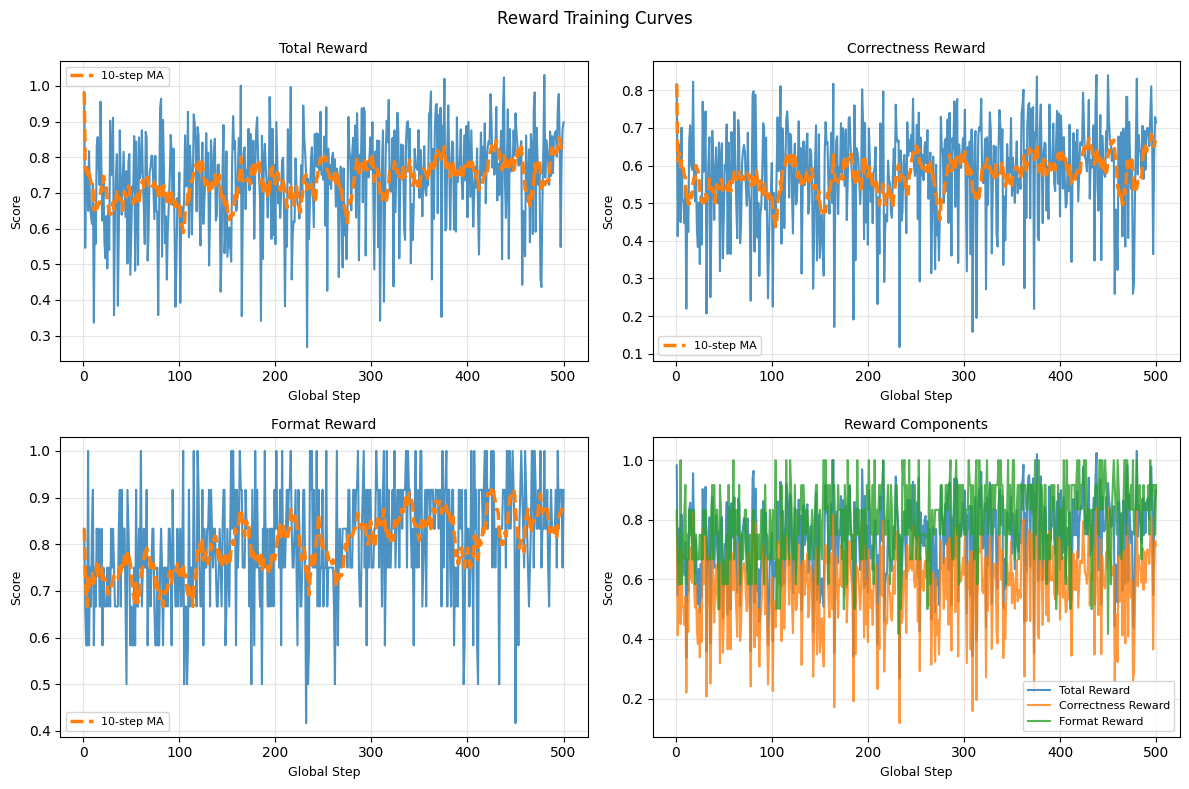

/workspace/tbx/comp0264/PartB_Q3_outputs/PartB_Q3_20260322_220420_UTC/reward_curve.png saved.

Final-stage mean rewards (last 10% of steps):
  Total Reward          : 0.7702
  Correctness Reward    : 0.5995
  Format Reward         : 0.8533


In [24]:
from __future__ import annotations

import argparse
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def main() -> None:
    default_dir = Path("/workspace/tbx/comp0264/PartB_Q3_outputs/PartB_Q3_20260322_220420_UTC")

    parser = argparse.ArgumentParser(description="Plot rewards from reward_step_log.csv")
    parser.add_argument(
        "-i",
        "--input",
        type=Path,
        default=default_dir / "reward_step_log.csv",
        help="Path to reward_step_log.csv",
    )
    parser.add_argument(
        "-o",
        "--output",
        type=Path,
        default=default_dir / "reward_curve.png",
        help="Output image path",
    )
    parser.add_argument(
        "--no-show",
        action="store_true",
        help="Do not call plt.show() (for headless / batch runs)",
    )

    args, _ = parser.parse_known_args()

    if not args.input.is_file():
        raise SystemExit(f"Input CSV not found: {args.input}")

    reward_log_df = pd.read_csv(args.input)

    log_df = (
        reward_log_df.groupby("global_step", as_index=False)[
            ["correctness_reward", "format_reward", "total_reward"]
        ]
        .mean()
        .sort_values("global_step")
        .reset_index(drop=True)
        .rename(
            columns={
                "global_step": "step",
                "correctness_reward": "correctness",
                "format_reward": "format",
                "total_reward": "total",
            }
        )
    )

    if log_df.empty:
        print("WARNING: reward_log_df is empty — no training steps were logged.")
        return

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle("Reward Training Curves", fontsize=12)

    plots = [
        ("total", "Total Reward"),
        ("correctness", "Correctness Reward"),
        ("format", "Format Reward"),
    ]

    for ax, (col, title) in zip(axes.flat[:3], plots):
        ax.plot(log_df["step"], log_df[col], linewidth=1.5, alpha=0.8)

        if len(log_df) >= 10:
            smoothed = log_df[col].rolling(window=10, min_periods=1).mean()
            ax.plot(
                log_df["step"],
                smoothed,
                linewidth=2.5,
                linestyle="--",
                label="10-step MA",
            )
            ax.legend(fontsize=8)

        ax.set_title(title, fontsize=10)
        ax.set_xlabel("Global Step", fontsize=9)
        ax.set_ylabel("Score", fontsize=9)
        ax.grid(True, alpha=0.3)

    ax = axes.flat[3]
    for col, title in plots:
        ax.plot(log_df["step"], log_df[col], linewidth=1.5, alpha=0.8, label=title)
    ax.set_title("Reward Components", fontsize=10)
    ax.set_xlabel("Global Step", fontsize=9)
    ax.set_ylabel("Score", fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    args.output.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(args.output, dpi=150, bbox_inches="tight")
    plt.show()

    print(f"{args.output} saved.")

    print("\nFinal-stage mean rewards (last 10% of steps):")
    n_tail = max(1, len(log_df) // 10)
    tail = log_df.tail(n_tail)
    for col, title in plots:
        print(f"  {title:22s}: {tail[col].mean():.4f}")


main()

In [25]:
example_indices = [0, 1, 2]
examples = []

for i in example_indices:
    q = str(train_df.iloc[i]["question"])
    ref = clean_answer(train_df.iloc[i]["answer_yoda"])
    pred = generate_response(rl_model, q)

    examples.append({
        "question": q,
        "reference_answer": ref,
        "after_rl_output": pred
    })

pd.DataFrame(examples)

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


,question,reference_answer,after_rl_output
0,how many bees does a queen bee produce,"A queen bee, does not directly control the hiv...","A single egg, the queen lays per day, she does..."
1,what disney movie has the song a whole new world,Menken and Ashman's Beauty and the Beast garne...,"A Disney animated film, The Little Mermaid is...."
2,when was the decimal currency system introduce...,"system From the rupee, anna, pie system to dec...","In India, a decimal monetary system, there is...."


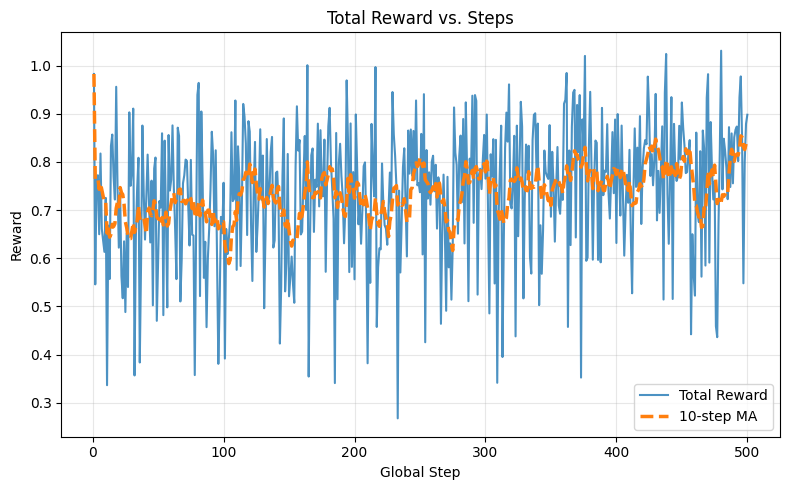

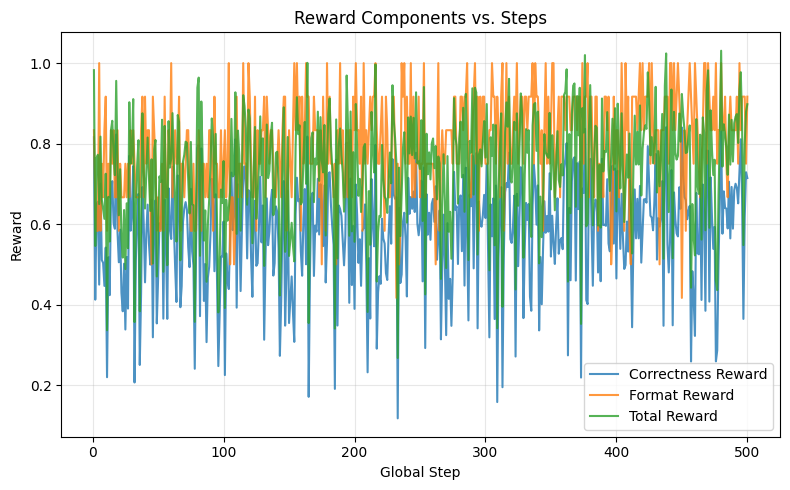

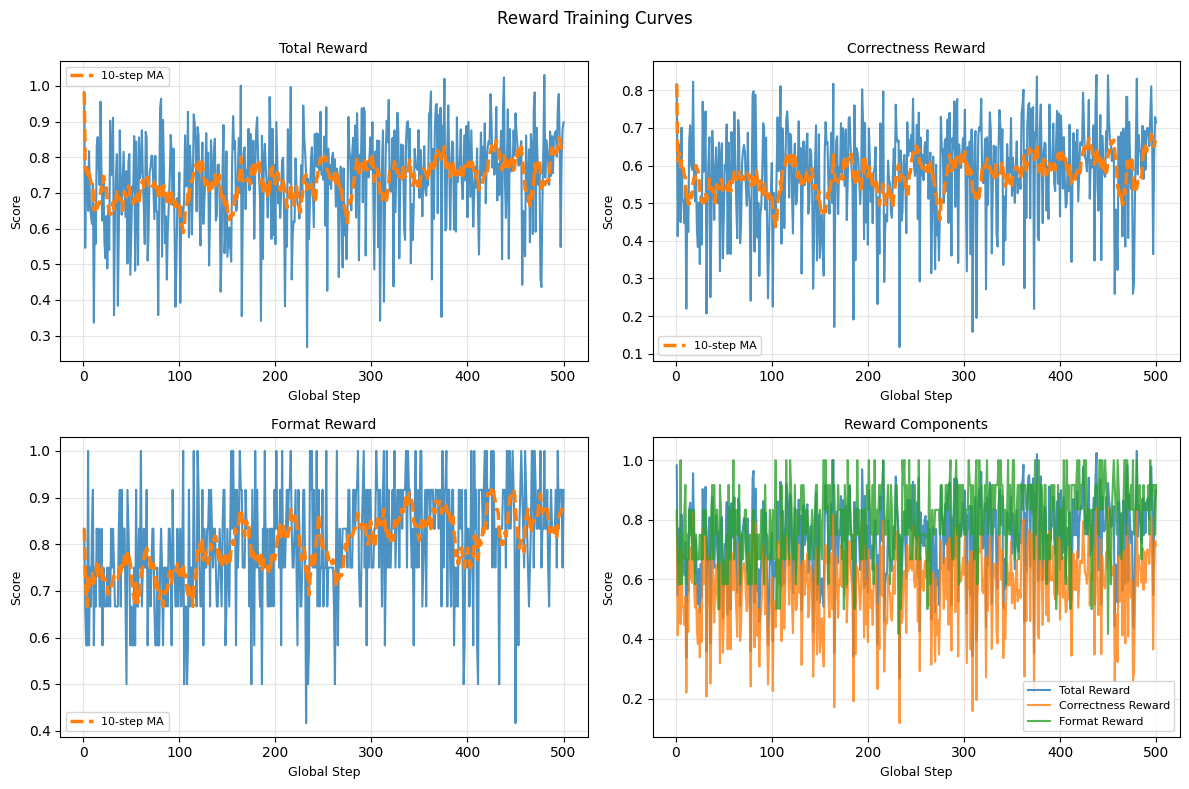

/workspace/tbx/comp0264/PartB_Q3_outputs/PartB_Q3_20260322_220420_UTC/total_reward_vs_steps.png saved.
/workspace/tbx/comp0264/PartB_Q3_outputs/PartB_Q3_20260322_220420_UTC/reward_components_vs_steps.png saved.
/workspace/tbx/comp0264/PartB_Q3_outputs/PartB_Q3_20260322_220420_UTC/reward_curve.png saved.

Final-stage mean rewards (last 10% of steps):
  Total Reward          : 0.7702
  Correctness Reward    : 0.5995
  Format Reward         : 0.8533


In [31]:
from __future__ import annotations

import argparse
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def main() -> None:
    default_dir = Path("/workspace/tbx/comp0264/PartB_Q3_outputs/PartB_Q3_20260322_220420_UTC")

    parser = argparse.ArgumentParser(description="Plot rewards from reward_step_log.csv")
    parser.add_argument(
        "-i",
        "--input",
        type=Path,
        default=default_dir / "reward_step_log.csv",
        help="Path to reward_step_log.csv",
    )
    parser.add_argument(
        "--no-show",
        action="store_true",
        help="Do not call plt.show() (for headless / batch runs)",
    )

    args, _ = parser.parse_known_args()

    if not args.input.is_file():
        raise SystemExit(f"Input CSV not found: {args.input}")

    reward_log_df = pd.read_csv(args.input)

    log_df = (
        reward_log_df.groupby("global_step", as_index=False)[
            ["correctness_reward", "format_reward", "total_reward"]
        ]
        .mean()
        .sort_values("global_step")
        .reset_index(drop=True)
        .rename(
            columns={
                "global_step": "step",
                "correctness_reward": "correctness",
                "format_reward": "format",
                "total_reward": "total",
            }
        )
    )

    if log_df.empty:
        print("WARNING: reward_log_df is empty — no training steps were logged.")
        return

    output_dir = args.input.parent
    total_path = output_dir / "total_reward_vs_steps.png"
    components_path = output_dir / "reward_components_vs_steps.png"
    combined_path = output_dir / "reward_curve.png"

    # 1) Total reward
    fig1 = plt.figure(figsize=(8, 5))
    plt.plot(log_df["step"], log_df["total"], linewidth=1.5, alpha=0.8, label="Total Reward")
    if len(log_df) >= 10:
        smoothed = log_df["total"].rolling(window=10, min_periods=1).mean()
        plt.plot(log_df["step"], smoothed, linewidth=2.5, linestyle="--", label="10-step MA")
    plt.title("Total Reward vs. Steps")
    plt.xlabel("Global Step")
    plt.ylabel("Reward")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(total_path, dpi=150, bbox_inches="tight")
    if not args.no_show:
        plt.show()
    else:
        plt.close(fig1)

    # 2) Reward components
    fig2 = plt.figure(figsize=(8, 5))
    plt.plot(log_df["step"], log_df["correctness"], linewidth=1.5, alpha=0.8, label="Correctness Reward")
    plt.plot(log_df["step"], log_df["format"], linewidth=1.5, alpha=0.8, label="Format Reward")
    plt.plot(log_df["step"], log_df["total"], linewidth=1.5, alpha=0.8, label="Total Reward")
    plt.title("Reward Components vs. Steps")
    plt.xlabel("Global Step")
    plt.ylabel("Reward")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(components_path, dpi=150, bbox_inches="tight")
    if not args.no_show:
        plt.show()
    else:
        plt.close(fig2)

    # 3) Optional combined panel
    fig3, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig3.suptitle("Reward Training Curves", fontsize=12)

    plots = [
        ("total", "Total Reward"),
        ("correctness", "Correctness Reward"),
        ("format", "Format Reward"),
    ]

    for ax, (col, title) in zip(axes.flat[:3], plots):
        ax.plot(log_df["step"], log_df[col], linewidth=1.5, alpha=0.8)

        if len(log_df) >= 10:
            smoothed = log_df[col].rolling(window=10, min_periods=1).mean()
            ax.plot(
                log_df["step"],
                smoothed,
                linewidth=2.5,
                linestyle="--",
                label="10-step MA",
            )
            ax.legend(fontsize=8)

        ax.set_title(title, fontsize=10)
        ax.set_xlabel("Global Step", fontsize=9)
        ax.set_ylabel("Score", fontsize=9)
        ax.grid(True, alpha=0.3)

    ax = axes.flat[3]
    for col, title in plots:
        ax.plot(log_df["step"], log_df[col], linewidth=1.5, alpha=0.8, label=title)
    ax.set_title("Reward Components", fontsize=10)
    ax.set_xlabel("Global Step", fontsize=9)
    ax.set_ylabel("Score", fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(combined_path, dpi=150, bbox_inches="tight")
    if not args.no_show:
        plt.show()
    else:
        plt.close(fig3)

    print(f"{total_path} saved.")
    print(f"{components_path} saved.")
    print(f"{combined_path} saved.")

    print("\nFinal-stage mean rewards (last 10% of steps):")
    n_tail = max(1, len(log_df) // 10)
    tail = log_df.tail(n_tail)
    for col, title in plots:
        print(f"  {title:22s}: {tail[col].mean():.4f}")


main()

# Part B Q4 — GRPO Training with Full Composite Reward

**Goal**: Fine-tune the **base model** `meta-llama/Llama-3.2-3B-Instruct` using GRPO with a composite reward:
- **Correctness Reward** (weight 0.4): Cosine similarity vs. ground truth answer (sentence-transformers)
- **Format Reward** (weight 0.2): Strict alphanumeric/punctuation regex + sentence capitalisation
- **Style Reward** (weight 0.4): DistilBERT Yoda-style classifier score

**Key constraints**: T4 15 GB GPU → QLoRA (4-bit + LoRA), `num_generations=4`, `per_device_train_batch_size=4`.

**Dataset**: `Datasets_3b_processed/yoda_{train,val,test}.csv` (500/200/500 rows from Natural Questions)

## Cell 0 — Install Dependencies

In [1]:
# Install required packages
# Run this cell first; runtime will restart automatically after installation.
!pip install -q trl>=0.12.0 peft transformers bitsandbytes accelerate datasets sentence-transformers evaluate
print('Installation complete.')

Installation complete.


## Cell 1 — Imports & Global CONFIG

In [2]:
# ============================================================
#  CONFIGURATION — all tuneable parameters in one place
# ============================================================
MODEL_ID        = "meta-llama/Llama-3.2-3B-Instruct"  # base model (needs HF Token)

# Reward weights — adjust if one component does not converge
W_CORRECT       = 0.4   # increase if correctness reward stays flat
W_FORMAT        = 0.2   # usually stable; lower if it dominates
W_STYLE         = 0.4   # increase if style score stays low

# GRPO hyper-parameters
NUM_GENERATIONS = 4     # reduce to 2 if OOM (per_device_batch will also halve)
LEARNING_RATE   = 5e-6
NUM_EPOCHS      = 1     # 1 epoch ≈ 1–2 h on T4
GRAD_ACCUM      = 8     # effective batch = NUM_GENERATIONS * (GRAD_ACCUM // NUM_GENERATIONS)
MAX_NEW_TOKENS  = 128   # max tokens for generated response
MAX_PROMPT_LEN  = 256   # max tokens for prompt
LOGGING_STEPS   = 10
# NOTE: per_device_train_batch_size is set to NUM_GENERATIONS in GRPOConfig
#       (TRL 0.29 requires batch_size % num_generations == 0)

# LoRA config
LORA_R          = 16
LORA_ALPHA      = 32
LORA_DROPOUT    = 0.05

# Classifier training (aligned with Part B Q1)
CLASSIFIER_EPOCHS   = 2.5  # Q1 uses 2.5 (3 epochs overfit)
CLASSIFIER_LR       = 2e-5
CLASSIFIER_BATCH    = 16   # Q1 uses 16

# Google Drive
SAVE_TO_DRIVE        = True   # save checkpoints/plots to Drive
DRIVE_CLASSIFIER_DIR = "/content/drive/MyDrive/CW1_PartB_Q4/yoda_classifier"
DRIVE_ADAPTER_DIR    = "/content/drive/MyDrive/CW1_PartB_Q4/grpo_adapter"

# Data paths
TRAIN_CSV = "/content/drive/MyDrive/CW1_PartB_Q4/Datasets_3b_processed/yoda_train.csv"
VAL_CSV   = "/content/drive/MyDrive/CW1_PartB_Q4/Datasets_3b_processed/yoda_val.csv"
TEST_CSV  = "/content/drive/MyDrive/CW1_PartB_Q4/Datasets_3b_processed/yoda_test.csv"

LOCAL_CLASSIFIER_DIR = "./yoda_classifier"
LOCAL_ADAPTER_DIR    = "./grpo_adapter"

# ── Training toggles ─────────────────────────────────────────
RUN_CLASSIFIER_TRAINING = True   # False = skip training, load existing weights from Drive/local
RUN_GRPO_TRAINING       = True   # False = skip GRPO training, load existing adapter from Drive/local
RUN_BEFORE_EXAMPLES     = True   # False = skip before-RLVR example generation
RUN_AFTER_EXAMPLES      = True   # False = skip after-RLVR example generation
# ─────────────────────────────────────────────────────────────

SEED = 42
# ============================================================

import os, re, json, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from typing import List, Dict, Any
warnings.filterwarnings('ignore')

from transformers import (
    AutoTokenizer, AutoModelForCausalLM,
    AutoModelForSequenceClassification,
    TrainingArguments, Trainer,
    TrainerCallback,
    BitsAndBytesConfig,
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from datasets import Dataset
from trl import GRPOTrainer, GRPOConfig
from sentence_transformers import SentenceTransformer

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    total_mem = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"VRAM: {total_mem:.1f} GB")
else:
    print("WARNING: No GPU detected — training will be extremely slow.")
print(f"PyTorch: {torch.__version__}")
print(f"\n── Training toggle status ──")
print(f"  RUN_CLASSIFIER_TRAINING = {RUN_CLASSIFIER_TRAINING}")
print(f"  RUN_GRPO_TRAINING       = {RUN_GRPO_TRAINING}")
print(f"  RUN_BEFORE_EXAMPLES     = {RUN_BEFORE_EXAMPLES}")
print(f"  RUN_AFTER_EXAMPLES      = {RUN_AFTER_EXAMPLES}")

GPU: Tesla T4
VRAM: 14.6 GB
PyTorch: 2.10.0+cu128

── Training toggle status ──
  RUN_CLASSIFIER_TRAINING = True
  RUN_GRPO_TRAINING       = True
  RUN_BEFORE_EXAMPLES     = True
  RUN_AFTER_EXAMPLES      = True


## Cell 1b — HF Token & Google Drive Mount

In [3]:
# Mount Google Drive (needed to upload dataset and save checkpoints)
from google.colab import drive, userdata
drive.mount('/content/drive')

# HF Token — set via Colab Secrets: Settings → Secrets → Add "HF_TOKEN"
HF_TOKEN = userdata.get('HF_TOKEN')
os.environ['HF_TOKEN'] = HF_TOKEN
print("HF_TOKEN loaded:", HF_TOKEN[:8] + "..." if HF_TOKEN else "NOT FOUND — please set it in Secrets")

Mounted at /content/drive
HF_TOKEN loaded: HF_TOKEN_REDACTED...


## Cell 2 — Load Dataset

> **Before running**: Upload the `Datasets_3b_processed/` folder to `/content/` (or copy from Drive).

In [4]:
# Load data from Drive (paths configured in CONFIG above).
# Paths point directly to Drive — no need to copy files.
train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

print(f"Train : {len(train_df):,} rows")
print(f"Val   : {len(val_df):,} rows")
print(f"Test  : {len(test_df):,} rows")
print("\nColumns:", list(train_df.columns))
print("\nSample row:")
display(train_df.head(2))

Train : 500 rows
Val   : 200 rows
Test  : 500 rows

Columns: ['id', 'question', 'answer_original', 'answer_yoda']

Sample row:


,id,question,answer_original,answer_yoda
0,train_44102,how many bees does a queen bee produce,"Queen bee Although the name might imply it, a ...","A queen bee, does not directly control the hiv..."
1,train_60126,what disney movie has the song a whole new world,Alan Menken Menken and Ashman's Beauty and the...,Menken and Ashman's Beauty and the Beast garne...


## Cell 3 — Train Yoda Style Classifier (Part B Q1)

We train a DistilBERT binary classifier: **label 1 = Yoda-style**, **label 0 = plain English**.  
Training data is constructed from `answer_yoda` (positive) and `answer_original` (negative).  
Training takes ~1 minute on T4.

In [5]:
# ── Check whether a pre-trained classifier already exists ─────────────────────
CLASSIFIER_AVAILABLE = False
if not RUN_CLASSIFIER_TRAINING:
    # Toggle is off: force-load from existing weights
    if SAVE_TO_DRIVE and os.path.isdir(DRIVE_CLASSIFIER_DIR):
        print(f"[Training skipped] Loading classifier from Drive: {DRIVE_CLASSIFIER_DIR}")
        CLASSIFIER_AVAILABLE = True
    elif os.path.isdir(LOCAL_CLASSIFIER_DIR):
        print(f"[Training skipped] Loading classifier from local: {LOCAL_CLASSIFIER_DIR}")
        CLASSIFIER_AVAILABLE = True
    else:
        print("WARNING: RUN_CLASSIFIER_TRAINING=False but no saved weights found — will train from scratch.")
else:
    if SAVE_TO_DRIVE and os.path.isdir(DRIVE_CLASSIFIER_DIR):
        print(f"Found saved classifier on Drive — skipping training, loading directly.")
        CLASSIFIER_AVAILABLE = True
    elif os.path.isdir(LOCAL_CLASSIFIER_DIR):
        print(f"Found local classifier — skipping training, loading directly.")
        CLASSIFIER_AVAILABLE = True
    else:
        print("No existing classifier found — will train from scratch.")

Found saved classifier on Drive — skipping training, loading directly.


In [6]:
# ── Build classifier training data ────────────────────────────────────────────
def build_classifier_dataset(train_df, val_df, test_df):
    """Positive = Yoda answer, Negative = original answer."""
    def make_rows(df, split):
        rows = []
        for _, r in df.iterrows():
            rows.append({"text": str(r["answer_yoda"]),     "label": 1})
            rows.append({"text": str(r["answer_original"]), "label": 0})
        return rows
    train_rows = make_rows(train_df, "train")
    val_rows   = make_rows(val_df,   "val")
    test_rows  = make_rows(test_df,  "test")
    random.shuffle(train_rows)
    return (
        Dataset.from_list(train_rows),
        Dataset.from_list(val_rows),
        Dataset.from_list(test_rows),
    )

if not CLASSIFIER_AVAILABLE:
    clf_train, clf_val, clf_test = build_classifier_dataset(train_df, val_df, test_df)
    print(f"Classifier train: {len(clf_train)}, val: {len(clf_val)}, test: {len(clf_test)}")

In [7]:
# ── Tokenise & train DistilBERT classifier ────────────────────────────────────
if not CLASSIFIER_AVAILABLE:
    import evaluate
    from transformers import DistilBertTokenizerFast
    clf_tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

    def tokenize_clf(batch):
        return clf_tokenizer(
            batch["text"],
            truncation=True,
            padding="max_length",
            max_length=128,
        )

    clf_train = clf_train.map(tokenize_clf, batched=True)
    clf_val   = clf_val.map(tokenize_clf, batched=True)
    clf_test  = clf_test.map(tokenize_clf, batched=True)

    for ds in [clf_train, clf_val, clf_test]:
        ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

    clf_model = AutoModelForSequenceClassification.from_pretrained(
        "distilbert-base-uncased", num_labels=2
    ).to(DEVICE)

    clf_loss_history = []

    class ClfLossCallback(TrainerCallback):
        def on_log(self, args, state, control, logs=None, **kwargs):
            if logs and "loss" in logs:
                clf_loss_history.append({"step": state.global_step, "loss": logs["loss"]})

    accuracy_metric = evaluate.load("accuracy")

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        return accuracy_metric.compute(predictions=preds, references=labels)

    clf_train_args = TrainingArguments(
        output_dir="./clf_checkpoints",
        num_train_epochs=CLASSIFIER_EPOCHS,       # 2.5, aligned with Q1
        per_device_train_batch_size=CLASSIFIER_BATCH,  # 16, aligned with Q1
        per_device_eval_batch_size=CLASSIFIER_BATCH,
        learning_rate=CLASSIFIER_LR,
        eval_strategy="epoch",
        save_strategy="no",                       # aligned with Q1
        logging_steps=10,
        report_to="none",
        seed=SEED,
    )

    clf_trainer = Trainer(
        model=clf_model,
        args=clf_train_args,
        train_dataset=clf_train,
        eval_dataset=clf_val,
        compute_metrics=compute_metrics,
        callbacks=[ClfLossCallback()],
    )

    print("Training Yoda style classifier...")
    clf_trainer.train()

    test_results = clf_trainer.evaluate(clf_test)
    print(f"\nTest accuracy: {test_results['eval_accuracy']:.4f}  (expected ≥ 0.98)")

    if clf_loss_history:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot([e["step"] for e in clf_loss_history],
                [e["loss"]  for e in clf_loss_history],
                color="steelblue", linewidth=1.5)
        ax.set_xlabel("Steps"); ax.set_ylabel("Loss")
        ax.set_title("Yoda Classifier Training Loss (DistilBERT)")
        ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

    os.makedirs(LOCAL_CLASSIFIER_DIR, exist_ok=True)
    clf_trainer.model.save_pretrained(LOCAL_CLASSIFIER_DIR)
    clf_tokenizer.save_pretrained(LOCAL_CLASSIFIER_DIR)
    print(f"Classifier saved to {LOCAL_CLASSIFIER_DIR}")

    if SAVE_TO_DRIVE:
        os.makedirs(DRIVE_CLASSIFIER_DIR, exist_ok=True)
        clf_trainer.model.save_pretrained(DRIVE_CLASSIFIER_DIR)
        clf_tokenizer.save_pretrained(DRIVE_CLASSIFIER_DIR)
        print(f"Classifier also saved to Drive: {DRIVE_CLASSIFIER_DIR}")

In [8]:
# ── Load classifier for reward scoring ────────────────────────────────────────
from transformers import DistilBertTokenizerFast

_clf_dir = DRIVE_CLASSIFIER_DIR if (SAVE_TO_DRIVE and os.path.isdir(DRIVE_CLASSIFIER_DIR)) else LOCAL_CLASSIFIER_DIR
print(f"Loading classifier from: {_clf_dir}")

# Keep classifier on CPU to save GPU VRAM for the LM
clf_tokenizer_inf = DistilBertTokenizerFast.from_pretrained(_clf_dir)
clf_model_inf     = AutoModelForSequenceClassification.from_pretrained(_clf_dir).to("cpu")
clf_model_inf.eval()
print("Classifier loaded on CPU.")

Loading classifier from: /content/drive/MyDrive/CW1_PartB_Q4/yoda_classifier


Loading weights:   0%|          | 0/104 [00:02<?, ?it/s]

Classifier loaded on CPU.


## Cell 4 — Composite Reward Function

Three reward components:

| Component | Metric | Weight |
|---|---|---|
| **Correctness** | Raw cosine similarity via sentence-transformers, clipped to [0,1] via `max(0, sim)` | 0.4 |
| **Format** | Three criteria each worth 1/3: (1) ≥95% printable chars, (2) sentence capitalisation, (3) ends with punctuation | 0.2 |
| **Style** | DistilBERT Yoda-class prob, scaled via `max(0, (prob-0.5)*2)` | 0.4 |

In [9]:
# ── Load sentence-transformer for correctness reward ──────────────────────────
print("Loading sentence-transformers model...")
sbert = SentenceTransformer("all-MiniLM-L6-v2", device="cpu")  # CPU to save VRAM
print("SentenceTransformer ready.")

Loading sentence-transformers model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

SentenceTransformer ready.


In [10]:
# ── Reward component functions (aligned with Part B Q2) ───────────────────────

def correctness_reward(response: str, gold: str) -> float:
    """
    Raw cosine similarity clipped to [0, 1].
    Using max(0, sim) instead of (sim+1)/2 to avoid inflating scores
    for unrelated text (which typically has sim ~ 0.2-0.4).
    """
    if not response.strip() or not gold.strip():
        return 0.0
    embs = sbert.encode([response, gold], convert_to_tensor=True, device="cpu")
    sim = F.cosine_similarity(embs[0].unsqueeze(0), embs[1].unsqueeze(0)).item()
    return max(0.0, min(1.0, sim))


def format_reward(response: str) -> float:
    """
    Three independent criteria, each worth 1/3:
      1. >= 95% of characters are printable  (filters garbled / non-English output)
      2. Every sentence starts with a capital letter
      3. Response ends with sentence-ending punctuation  (not truncated mid-sentence)
    """
    response = response.strip()
    if not response:
        return 0.0
    score = 0.0

    # Criterion 1: printable character ratio
    if sum(1 for c in response if c.isprintable()) / len(response) >= 0.95:
        score += 1 / 3

    # Criterion 2: sentence capitalisation
    sentences = [s for s in re.split(r"[.!?]+\s*", response) if s.strip()]
    if sentences and all(s.strip()[0].isupper() for s in sentences):
        score += 1 / 3

    # Criterion 3: ends with punctuation
    if re.search(r"[.!?]$", response):
        score += 1 / 3

    return round(score, 4)


@torch.no_grad()
def style_reward(response: str) -> float:
    """DistilBERT Yoda-class prob, centred & scaled: max(0, (prob-0.5)*2)  (from Q2)"""
    if not response.strip():
        return 0.0
    enc = clf_tokenizer_inf(
        response,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128,
    )
    logits = clf_model_inf(**enc).logits
    prob = torch.softmax(logits, dim=1)[0, 1].item()
    return max(0.0, (prob - 0.5) * 2)


def composite_reward(
    response: str,
    gold: str,
    w_correct: float = W_CORRECT,
    w_format:  float = W_FORMAT,
    w_style:   float = W_STYLE,
) -> Dict[str, float]:
    """Weighted composite reward (weights from CONFIG)."""
    c = correctness_reward(response, gold)
    f = format_reward(response)
    s = style_reward(response)
    total = w_correct * c + w_format * f + w_style * s
    return {"correctness": c, "format": f, "style": s, "total": total}


# Sanity check
test_resp = "Answer, I will. Strong with the Force, this question is."
test_gold = "The answer is forty-two."
scores = composite_reward(test_resp, test_gold)
print("Sanity check scores:", {k: f"{v:.4f}" for k, v in scores.items()})
assert all(0.0 <= v <= 1.0 for v in scores.values()), "Reward out of [0,1] range!"
print("All reward values in [0, 1]. OK.")

Sanity check scores: {'correctness': '0.1337', 'format': '1.0000', 'style': '0.9725', 'total': '0.6425'}
All reward values in [0, 1]. OK.


In [11]:
# ── Global reward log for plotting (accumulated during training) ───────────────
reward_log: List[Dict[str, Any]] = []  # {step, total, correctness, format, style}


def grpo_reward_fn(
    completions: List[str],
    answer_original: List[str],
    **kwargs,
) -> List[float]:
    """
    GRPO reward function signature:
      completions     : list of generated response strings (one per sample)
      answer_original : corresponding gold answers from the dataset column
    Returns list of scalar rewards.
    """
    rewards = []
    for resp, gold in zip(completions, answer_original):
        scores = composite_reward(resp, str(gold))
        rewards.append(scores["total"])
    return rewards

## Cell 5 — Load Base Model with QLoRA

In [12]:
from huggingface_hub import login
login(token=HF_TOKEN, add_to_git_credential=False)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

print(f"Loading tokenizer from {MODEL_ID}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, token=HF_TOKEN, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"  # GRPO requires left padding

print(f"Loading base model in 4-bit from {MODEL_ID}...")
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    token=HF_TOKEN,
)
base_model.config.pad_token_id = tokenizer.pad_token_id
base_model.config.use_cache    = False

base_model = prepare_model_for_kbit_training(base_model)

lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM",
)
model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()

# Memory check
if torch.cuda.is_available():
    alloc = torch.cuda.memory_allocated() / 1024**3
    reserved = torch.cuda.memory_reserved() / 1024**3
    print(f"GPU memory — allocated: {alloc:.2f} GB | reserved: {reserved:.2f} GB")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Loading tokenizer from meta-llama/Llama-3.2-3B-Instruct...


config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

trainable params: 24,313,856 || all params: 3,237,063,680 || trainable%: 0.7511
GPU memory — allocated: 2.92 GB | reserved: 7.08 GB


## Cell 6 — Before-RLVR Baseline (3 Examples)

In [13]:
SYSTEM_PROMPT = (
    "You are a helpful assistant that always responds in Yoda-style English. "
    "Answer the question accurately and in the distinctive Yoda speech pattern."
)


def build_prompt(question: str) -> str:
    """Build a chat-template prompt for inference."""
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": question},
    ]
    return tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )


@torch.no_grad()
def generate_response(mdl, question: str) -> str:
    """Generate a response from the model."""
    prompt = build_prompt(question)
    inputs = tokenizer(
        prompt, return_tensors="pt", truncation=True, max_length=MAX_PROMPT_LEN
    ).to(mdl.device)
    out = mdl.generate(
        **inputs,
        max_new_tokens=MAX_NEW_TOKENS,
        do_sample=True,
        temperature=0.7,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )
    generated = out[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(generated, skip_special_tokens=True).strip()


test_samples = test_df.head(3).to_dict(orient="records")
before_results = []

if RUN_BEFORE_EXAMPLES:
    model.eval()
    print("=" * 70)
    print("BEFORE RLVR — Base Model Responses")
    print("=" * 70)
    for i, row in enumerate(test_samples, 1):
        resp = generate_response(model, row["question"])
        scores = composite_reward(resp, str(row["answer_original"]))
        before_results.append({"question": row["question"], "response": resp,
                                "gold": row["answer_original"], "scores": scores})
        print(f"\n--- Example {i} ---")
        print(f"Q: {row['question']}")
        print(f"Response: {resp}")
        print(f"Scores: correctness={scores['correctness']:.3f}, "
              f"format={scores['format']:.3f}, style={scores['style']:.3f}, "
              f"total={scores['total']:.3f}")
else:
    print("[Skipped] RUN_BEFORE_EXAMPLES=False — before-RLVR examples skipped.")

BEFORE RLVR — Base Model Responses

--- Example 1 ---
Q: lucknow congress session 1916 was presided over by—
Response: "A president of the congress session, 1916's Lucknow, was presided over by, Lala Lajpat Rai, it was."
Scores: correctness=0.502, format=0.333, style=0.971, total=0.656

--- Example 2 ---
Q: when did the first chipotle on evans open
Response: "A question, you have, young one. The first Chipotle on Evans, in what year, it opened, hmm? 

Research, I have done. In 1983, the first Chipotle, in Denver, Colorado, it was. 

Evans, Georgia, a Chipotle, there is not. But, a location, there was, in 2006, it opened.
Scores: correctness=0.589, format=0.667, style=0.979, total=0.761

--- Example 3 ---
Q: when did the us start using agent orange in vietnam
Response: "A question, you have, young one. The answer, I shall provide. 

Agent Orange, a herbicide, it was. In Vietnam, used, it was. 1953, the first use, it was. By the US military, in the early stages of the Vietnam War, a secr

## Cell 7 — GRPO Training

In [14]:
# ── Build GRPO dataset ────────────────────────────────────────────────────────
# GRPOTrainer requires the dataset to have a `prompt` column (string).
# Any extra columns (e.g. answer_original) are passed as kwargs to reward_fn.

def make_grpo_dataset(df: pd.DataFrame) -> Dataset:
    records = []
    for _, row in df.iterrows():
        records.append({
            "prompt":          build_prompt(row["question"]),
            "answer_original": str(row["answer_original"]),
        })
    return Dataset.from_list(records)

grpo_train_dataset = make_grpo_dataset(train_df)
print(f"GRPO train dataset: {len(grpo_train_dataset)} examples")
print("Sample prompt (first 200 chars):", grpo_train_dataset[0]["prompt"][:200])

GRPO train dataset: 500 examples
Sample prompt (first 200 chars): <|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 12 Mar 2026

You are a helpful assistant that always responds in Yoda-style English. Answ


In [15]:
# ── Wrapped reward function that logs all component scores ─────────────────────
# grpo_reward_fn_logged is the sole logger — no separate callback needed.
_step_counter = {"n": 0}

def grpo_reward_fn_logged(
    completions: List[str],
    answer_original: List[str],
    **kwargs,
) -> List[float]:
    rewards = []
    batch_c, batch_f, batch_s, batch_t = [], [], [], []
    for resp, gold in zip(completions, answer_original):
        sc = composite_reward(resp, str(gold))
        rewards.append(sc["total"])
        batch_c.append(sc["correctness"])
        batch_f.append(sc["format"])
        batch_s.append(sc["style"])
        batch_t.append(sc["total"])
    # Log mean across the batch
    _step_counter["n"] += 1
    reward_log.append({
        "step":        _step_counter["n"],
        "total":       float(np.mean(batch_t)),
        "correctness": float(np.mean(batch_c)),
        "format":      float(np.mean(batch_f)),
        "style":       float(np.mean(batch_s)),
    })
    return rewards

In [16]:
# ── GRPOConfig ────────────────────────────────────────────────────────────────
# TRL 0.29 constraint: per_device_train_batch_size % num_generations == 0
grpo_config = GRPOConfig(
    # Core GRPO params
    num_generations=NUM_GENERATIONS,
    max_completion_length=MAX_NEW_TOKENS,

    # Training
    per_device_train_batch_size=NUM_GENERATIONS,           # must equal num_generations
    gradient_accumulation_steps=GRAD_ACCUM // NUM_GENERATIONS,  # 2 → effective batch=8
    num_train_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE,
    # fp16/bf16 both disabled: T4 doesn't support bf16, and fp16 AMP conflicts
    # with bfloat16 tensors in 4-bit QLoRA. LoRA adapters run in float32.
    fp16=False,
    bf16=False,

    # Logging & saving
    logging_steps=LOGGING_STEPS,
    output_dir="./grpo_checkpoints",
    save_strategy="epoch",
    report_to="none",
    seed=SEED,

    # Efficiency
    gradient_checkpointing=True,
    optim="paged_adamw_8bit",
    warmup_ratio=0.05,
)

print("GRPOConfig summary:")
print(f"  num_generations          = {grpo_config.num_generations}")
print(f"  max_completion_length    = {grpo_config.max_completion_length}")
print(f"  per_device_train_batch   = {grpo_config.per_device_train_batch_size}")
print(f"  gradient_accumulation    = {grpo_config.gradient_accumulation_steps}")
print(f"  effective batch size     = {grpo_config.per_device_train_batch_size * grpo_config.gradient_accumulation_steps}")
print(f"  learning_rate            = {grpo_config.learning_rate}")
print(f"  num_train_epochs         = {grpo_config.num_train_epochs}")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


GRPOConfig summary:
  num_generations          = 4
  max_completion_length    = 128
  per_device_train_batch   = 4
  gradient_accumulation    = 2
  effective batch size     = 8
  learning_rate            = 5e-06
  num_train_epochs         = 1


In [17]:
if RUN_GRPO_TRAINING:
    # ── Initialise GRPOTrainer ────────────────────────────────────────────────
    trainer = GRPOTrainer(
        model=model,
        args=grpo_config,
        reward_funcs=grpo_reward_fn_logged,
        train_dataset=grpo_train_dataset,
        processing_class=tokenizer,
    )

    print("GRPOTrainer initialised. Starting training...")
    print("Expected training time: ~1–2 hours on T4.")
    train_result = trainer.train()
    print("Training complete.")
    print(f"  Total steps : {train_result.global_step}")
    print(f"  Train loss  : {train_result.training_loss:.4f}")
else:
    # ── Skip training: load existing adapter from Drive/local ─────────────────
    print("[Skipped] RUN_GRPO_TRAINING=False — attempting to load existing adapter...")
    from peft import PeftModel
    _adapter_dir = DRIVE_ADAPTER_DIR if (SAVE_TO_DRIVE and os.path.isdir(DRIVE_ADAPTER_DIR)) else LOCAL_ADAPTER_DIR
    if os.path.isdir(_adapter_dir):
        model = PeftModel.from_pretrained(model, _adapter_dir)
        print(f"Adapter loaded from {_adapter_dir}.")
    else:
        print(f"WARNING: No adapter found at {_adapter_dir} — using untrained base model.")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009, 'pad_token_id': 128009}.


GRPOTrainer initialised. Starting training...
Expected training time: ~1–2 hours on T4.


Passing `generation_config` together with generation-related arguments=({'disable_compile'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


Step,Training Loss
10,-0.016061
20,-0.025814
30,-0.039759
40,0.040837
50,0.014119
60,0.046241
70,-0.010360
80,0.064544
90,0.085821
100,0.032914


Training complete.
  Total steps : 250
  Train loss  : 0.0351


In [18]:
if RUN_GRPO_TRAINING:
    os.makedirs(LOCAL_ADAPTER_DIR, exist_ok=True)
    trainer.model.save_pretrained(LOCAL_ADAPTER_DIR)
    tokenizer.save_pretrained(LOCAL_ADAPTER_DIR)
    print(f"Adapter saved to: {LOCAL_ADAPTER_DIR}")

    if SAVE_TO_DRIVE:
        os.makedirs(DRIVE_ADAPTER_DIR, exist_ok=True)
        trainer.model.save_pretrained(DRIVE_ADAPTER_DIR)
        tokenizer.save_pretrained(DRIVE_ADAPTER_DIR)
        print(f"Adapter also saved to Drive: {DRIVE_ADAPTER_DIR}")
else:
    print("[Skipped] RUN_GRPO_TRAINING=False — no adapter to save.")

Adapter saved to: ./grpo_adapter
Adapter also saved to Drive: /content/drive/MyDrive/CW1_PartB_Q4/grpo_adapter


## PartB Q4 deliverables-1:

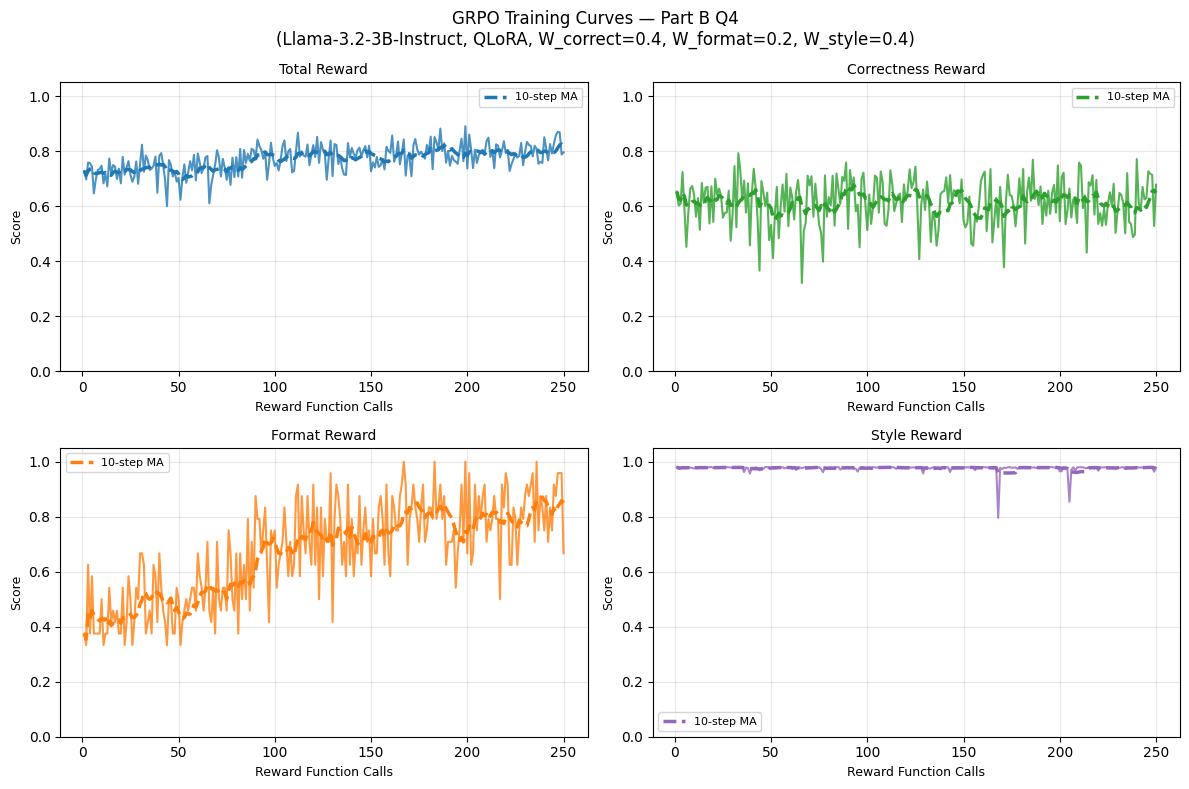

reward_curve.png saved.
Plot copied to Drive: /content/drive/MyDrive/CW1_PartB_Q4/reward_curve.png

Final-epoch mean rewards (last 10% of steps):
  Total Reward          : 0.8059
  Correctness Reward    : 0.6183
  Format Reward         : 0.8383
  Style Reward          : 0.9773


In [19]:
log_df = pd.DataFrame(reward_log)
if log_df.empty:
    print("WARNING: reward_log is empty — no training steps were logged.")
else:
    log_df = log_df.drop_duplicates(subset=["step"]).sort_values("step").reset_index(drop=True)

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle("GRPO Training Curves — Part B Q4\n"
                 f"(Llama-3.2-3B-Instruct, QLoRA, W_correct={W_CORRECT}, "
                 f"W_format={W_FORMAT}, W_style={W_STYLE})",
                 fontsize=12)

    plots = [
        ("total",       "Total Reward",       "tab:blue"),
        ("correctness", "Correctness Reward", "tab:green"),
        ("format",      "Format Reward",      "tab:orange"),
        ("style",       "Style Reward",       "tab:purple"),
    ]

    for ax, (col, title, color) in zip(axes.flat, plots):
        if col in log_df.columns:
            ax.plot(log_df["step"], log_df[col], color=color, linewidth=1.5, alpha=0.8)
            if len(log_df) >= 10:
                smoothed = log_df[col].rolling(window=10, min_periods=1).mean()
                ax.plot(log_df["step"], smoothed, color=color, linewidth=2.5,
                        linestyle="--", label="10-step MA")
                ax.legend(fontsize=8)
        ax.set_title(title, fontsize=10)
        ax.set_xlabel("Reward Function Calls", fontsize=9)
        ax.set_ylabel("Score", fontsize=9)
        ax.set_ylim(0, 1.05)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("reward_curve.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("reward_curve.png saved.")

    if SAVE_TO_DRIVE:
        import shutil
        drive_plot_path = "/content/drive/MyDrive/CW1_PartB_Q4/reward_curve.png"
        os.makedirs(os.path.dirname(drive_plot_path), exist_ok=True)
        shutil.copy("reward_curve.png", drive_plot_path)
        print(f"Plot copied to Drive: {drive_plot_path}")

    print("\nFinal-epoch mean rewards (last 10% of steps):")
    n_tail = max(1, len(log_df) // 10)
    tail = log_df.tail(n_tail)
    for col, title, _ in plots:
        if col in tail.columns:
            print(f"  {title:22s}: {tail[col].mean():.4f}")

## Cell 9 — After-RLVR Comparison (3 Examples)

Compare the same 3 test questions used in Cell 6.

In [20]:
after_results = []

if RUN_AFTER_EXAMPLES:
    model.eval()
    print("=" * 70)
    print("AFTER RLVR — Trained Model Responses")
    print("=" * 70)
    for i, row in enumerate(test_samples, 1):
        resp = generate_response(model, row["question"])
        scores = composite_reward(resp, str(row["answer_original"]))
        after_results.append({"question": row["question"], "response": resp,
                               "gold": row["answer_original"], "scores": scores})
        print(f"\n--- Example {i} ---")
        print(f"Q: {row['question']}")
        print(f"Response: {resp}")
        print(f"Scores: correctness={scores['correctness']:.3f}, "
              f"format={scores['format']:.3f}, style={scores['style']:.3f}, "
              f"total={scores['total']:.3f}")
else:
    print("[Skipped] RUN_AFTER_EXAMPLES=False — after-RLVR examples skipped.")

AFTER RLVR — Trained Model Responses

--- Example 1 ---
Q: lucknow congress session 1916 was presided over by—
Response: A question, you have, young one. The answer, I shall provide. 

Presided over by Sir Syed Ali Imam, the Lucknow Congress session of 1916 was.
Scores: correctness=0.572, format=1.000, style=0.973, total=0.818

--- Example 2 ---
Q: when did the first chipotle on evans open
Response: Open in 1995, the first Chipotle on Evans was. In Augusta, Georgia, a location it was.
Scores: correctness=0.522, format=1.000, style=0.976, total=0.799

--- Example 3 ---
Q: when did the us start using agent orange in vietnam
Response: A question, you have, young one. The answer, I shall provide. 

Agent Orange, used in Vietnam, it was. From 1961 to 1971, sprayed, it was. The Vietnam War, a time of great turmoil, it was. 

A herbicide and defoliant, Agent Orange was. Purpose, to destroy foliage, it had. Enemy hiding places, it sought to destroy. 

Sprayed by the US military, it was. Over 5

In [21]:
# ── Before / After comparison table ──────────────────────────────────────────
from IPython.display import Markdown, display

md_lines = [
    "## Before vs After RLVR — 3 Test Examples",
    "",
    "| # | Question | Before (base) | After (GRPO) |",
    "|---|---|---|---|",
]
for i, (b, a) in enumerate(zip(before_results, after_results), 1):
    q = b["question"][:80].replace("|", "\\|")
    bef = b["response"][:120].replace("\n", " ").replace("|", "\\|")
    aft = a["response"][:120].replace("\n", " ").replace("|", "\\|")
    md_lines.append(f"| {i} | {q} | {bef} | {aft} |")

md_lines += [
    "",
    "### Reward Score Comparison",
    "",
    "| Example | Metric | Before | After | Δ |",
    "|---|---|---|---|---|",
]
for i, (b, a) in enumerate(zip(before_results, after_results), 1):
    for metric in ["total", "correctness", "format", "style"]:
        bv = b["scores"][metric]
        av = a["scores"][metric]
        delta = av - bv
        sign = "+" if delta >= 0 else ""
        md_lines.append(f"| Ex {i} | {metric} | {bv:.3f} | {av:.3f} | {sign}{delta:.3f} |")

comparison_md = "\n".join(md_lines)
display(Markdown(comparison_md))

# Save markdown
with open("before_after_comparison.md", "w", encoding="utf-8") as f:
    f.write(comparison_md)
print("Saved before_after_comparison.md")

if SAVE_TO_DRIVE:
    import shutil
    drive_md_path = "/content/drive/MyDrive/CW1_PartB_Q4/before_after_comparison.md"
    os.makedirs(os.path.dirname(drive_md_path), exist_ok=True)
    shutil.copy("before_after_comparison.md", drive_md_path)
    print(f"Markdown copied to Drive: {drive_md_path}")

## Before vs After RLVR — 3 Test Examples

| # | Question | Before (base) | After (GRPO) |
|---|---|---|---|
| 1 | lucknow congress session 1916 was presided over by— | "A president of the congress session, 1916's Lucknow, was presided over by, Lala Lajpat Rai, it was." | A question, you have, young one. The answer, I shall provide.   Presided over by Sir Syed Ali Imam, the Lucknow Congress |
| 2 | when did the first chipotle on evans open | "A question, you have, young one. The first Chipotle on Evans, in what year, it opened, hmm?   Research, I have done. In | Open in 1995, the first Chipotle on Evans was. In Augusta, Georgia, a location it was. |
| 3 | when did the us start using agent orange in vietnam | "A question, you have, young one. The answer, I shall provide.   Agent Orange, a herbicide, it was. In Vietnam, used, it | A question, you have, young one. The answer, I shall provide.   Agent Orange, used in Vietnam, it was. From 1961 to 1971 |

### Reward Score Comparison

| Example | Metric | Before | After | Δ |
|---|---|---|---|---|
| Ex 1 | total | 0.656 | 0.818 | +0.162 |
| Ex 1 | correctness | 0.502 | 0.572 | +0.070 |
| Ex 1 | format | 0.333 | 1.000 | +0.667 |
| Ex 1 | style | 0.971 | 0.973 | +0.002 |
| Ex 2 | total | 0.761 | 0.799 | +0.038 |
| Ex 2 | correctness | 0.589 | 0.522 | -0.068 |
| Ex 2 | format | 0.667 | 1.000 | +0.333 |
| Ex 2 | style | 0.979 | 0.976 | -0.003 |
| Ex 3 | total | 0.763 | 0.823 | +0.060 |
| Ex 3 | correctness | 0.760 | 0.744 | -0.015 |
| Ex 3 | format | 0.333 | 0.667 | +0.333 |
| Ex 3 | style | 0.981 | 0.980 | -0.000 |

Saved before_after_comparison.md
Markdown copied to Drive: /content/drive/MyDrive/CW1_PartB_Q4/before_after_comparison.md


## PartB Q4 deliverables-2:

In [22]:
# ── Detailed per-example printout for notebook PDF export ─────────────────────
print("=" * 70)
print("DETAILED BEFORE / AFTER COMPARISON")
print("=" * 70)
for i, (b, a) in enumerate(zip(before_results, after_results), 1):
    print(f"\n{'─'*60}")
    print(f"Example {i}")
    print(f"{'─'*60}")
    print(f"Question:\n  {b['question']}")
    print(f"\nGold answer (first 150 chars):\n  {str(b['gold'])[:150]}")
    print(f"\nBefore RLVR:\n  {b['response']}")
    print(f"  → total={b['scores']['total']:.3f}  "
          f"correctness={b['scores']['correctness']:.3f}  "
          f"format={b['scores']['format']:.3f}  "
          f"style={b['scores']['style']:.3f}")
    print(f"\nAfter RLVR:\n  {a['response']}")
    print(f"  → total={a['scores']['total']:.3f}  "
          f"correctness={a['scores']['correctness']:.3f}  "
          f"format={a['scores']['format']:.3f}  "
          f"style={a['scores']['style']:.3f}")
print(f"\n{'='*70}")
print("Part B Q4 Complete.")
print(f"  Adapter saved to : {LOCAL_ADAPTER_DIR}")
print(f"  Reward curve     : reward_curve.png")
print(f"  Comparison MD    : before_after_comparison.md")

DETAILED BEFORE / AFTER COMPARISON

────────────────────────────────────────────────────────────
Example 1
────────────────────────────────────────────────────────────
Question:
  lucknow congress session 1916 was presided over by—

Gold answer (first 150 chars):
  Lucknow Pact Muhammad Ali Jinnah, then a member of the Congress as well as the League, made both the parties reach an agreement to pressure the Britis

Before RLVR:
  "A president of the congress session, 1916's Lucknow, was presided over by, Lala Lajpat Rai, it was."
  → total=0.656  correctness=0.502  format=0.333  style=0.971

After RLVR:
  A question, you have, young one. The answer, I shall provide. 

Presided over by Sir Syed Ali Imam, the Lucknow Congress session of 1916 was.
  → total=0.818  correctness=0.572  format=1.000  style=0.973

────────────────────────────────────────────────────────────
Example 2
────────────────────────────────────────────────────────────
Question:
  when did the first chipotle on evans op

# Part B Q5: Comparison and Analysis
**Objective:** Compare two RL-trained models on the held-out test set:
- **Model Q3**: SFT checkpoint → RL (correctness + format reward only)
- **Model Q4**: Base model → RL (full composite reward: correctness + format + style)

In [ ]:
# ── Step 0: HuggingFace Login 
from huggingface_hub import login
login("HF_TOKEN_REDACTED")

In [ ]:
# ── Step 1: Mount Google Drive 
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/GenAI_CW1_PartB_Q5')
print("Working directory:", os.getcwd())
print("Files:", os.listdir('.'))

Mounted at /content/drive
Working directory: /content/drive/MyDrive/GenAI_CW1_PartB_Q5
Files: ['Datasets_3b_processed', 'yoda_classifier', 'grpo_adapter', 'q3_adapter', 'partB_Q5.ipynb']


In [ ]:
# ── Step 2: Install Dependencies 
!pip install -q peft transformers accelerate sentence-transformers pandas tqdm bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.2 MB/s eta 0:00:00


In [ ]:
# ── Step 3: Imports & Config 
import re
import torch
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from peft import PeftModel
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSequenceClassification,
    BitsAndBytesConfig
)
from sentence_transformers import SentenceTransformer, util


BASE_MODEL_ID   = "meta-llama/Llama-3.2-3B-Instruct"
Q3_ADAPTER_PATH = "q3_adapter"
Q4_ADAPTER_PATH = "grpo_adapter"
CLASSIFIER_PATH = "yoda_classifier"
TEST_CSV        = "Datasets_3b_processed/yoda_test.csv"
N_TEST          = 200
DEVICE          = "cuda" if torch.cuda.is_available() else "cpu"

# Reward weights
W_CORRECT = 0.4
W_FORMAT  = 0.2
W_STYLE   = 0.4

print(f"Device: {DEVICE}")
print(f"CUDA available: {torch.cuda.is_available()}")

Device: cuda
CUDA available: True


In [ ]:
# ── Step 4: Load Test Set 
df = pd.read_csv(TEST_CSV)
print("Columns:", df.columns.tolist())
print(f"Total rows: {len(df)}")
df.head(3)

Columns: ['id', 'question', 'answer_original', 'answer_yoda']
Total rows: 500


,id,question,answer_original,answer_yoda
0,test_39275,lucknow congress session 1916 was presided ove...,"Lucknow Pact Muhammad Ali Jinnah, then a membe...",To pressure the British government to adopt a ...
1,test_36687,when did the first chipotle on evans open,Chipotle Mexican Grill Founder Steve Ells atte...,Attended the Culinary Institute of America in ...
2,test_96718,when did the us start using agent orange in vi...,"Agent Orange In mid-1961, President Ngo Dinh D...","In mid-1961, President Ngo Dinh Diem of South ..."


In [6]:
QUESTION_COL = "question"
ANSWER_COL   = "answer_yoda"

if N_TEST:
    df = df.sample(n=N_TEST, random_state=42).reset_index(drop=True)
print(f"Evaluating on {len(df)} samples")

Evaluating on 200 samples


In [ ]:
# ── Step 5: Load Reward Functions 
semantic_model = SentenceTransformer("all-MiniLM-L6-v2")

def correctness_reward(response: str, gold_answer: str, task_type: str = "yoda") -> float:
    if task_type == "math":
        p_nums = re.findall(r"-?\d+(?:\.\d+)?", response)
        g_nums = re.findall(r"-?\d+(?:\.\d+)?", gold_answer)
        return 1.0 if (p_nums and g_nums and float(p_nums[-1]) == float(g_nums[-1])) else 0.0
    elif task_type == "mcq":
        p_match = re.search(r"\b[A-E]\b", response.upper())
        g_match = re.search(r"\b[A-E]\b", gold_answer.upper())
        return 1.0 if (p_match and g_match and p_match.group() == g_match.group()) else 0.0
    else:
        sim = util.cos_sim(
            semantic_model.encode(response),
            semantic_model.encode(gold_answer)
        ).item()
        return max(0.0, sim)

def format_reward(response: str) -> float:
    response = response.strip()
    if not response:
        return 0.0
    score = 0.0
    if sum(1 for c in response if c.isprintable()) / len(response) >= 0.95:
        score += 1/3
    sentences = [s for s in re.split(r"[.!?]+\s*", response) if s.strip()]
    if sentences and all(s.strip()[0].isupper() for s in sentences):
        score += 1/3
    if re.search(r"[.!?]$", response):
        score += 1/3
    return score

# Load Yoda classifier
clf_tok   = AutoTokenizer.from_pretrained(CLASSIFIER_PATH)
clf_model = AutoModelForSequenceClassification.from_pretrained(CLASSIFIER_PATH).to(DEVICE)
clf_model.eval()

def style_reward(text: str) -> float:
    inputs = clf_tok(text, return_tensors="pt", truncation=True,
                     padding=True, max_length=128).to(DEVICE)
    with torch.no_grad():
        probs = torch.softmax(clf_model(**inputs).logits, dim=1)
    return max(0.0, probs[0, 1].item() - 0.5) * 2

def composite_reward(response, gold_answer, task_type="yoda"):
    c = correctness_reward(response, gold_answer, task_type)
    f = format_reward(response)
    s = style_reward(response)
    t = W_CORRECT * c + W_FORMAT * f + W_STYLE * s
    return c, f, s, t

print("Reward functions loaded ✓")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:01<?, ?it/s]

Reward functions loaded ✓


In [ ]:
# ── Step 6: Load Base Model 
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16
)

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Loading base model (4bit)...")
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto"
)
print("Base model loaded ✓")

Loading tokenizer...


config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

Base model loaded ✓


In [ ]:
# ── Step 7: Inference Helper 
def generate_response(model, tokenizer, question: str, max_new_tokens=200) -> str:
    prompt = f"Answer the following question in Yoda style:\n{question}\nAnswer:"
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id
        )
    gen_ids = output[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(gen_ids, skip_special_tokens=True).strip()

def evaluate_model(model, tokenizer, df, model_name):
    results = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"{model_name} inference"):
        question    = row[QUESTION_COL]
        gold_answer = row[ANSWER_COL]
        response    = generate_response(model, tokenizer, question)
        c, f, s, t  = composite_reward(response, gold_answer)
        results.append({
            "question":    question,
            "gold_answer": gold_answer,
            "response":    response,
            "correctness": c,
            "format":      f,
            "style":       s,
            "total":       t
        })
    return pd.DataFrame(results)

print("Inference helper ready ✓")

Inference helper ready ✓


In [ ]:
# ── Step 8: Evaluate Q4 Model 
print("Loading Q4 adapter...")
q4_model = PeftModel.from_pretrained(base_model, Q4_ADAPTER_PATH)
q4_model.eval()
print("Q4 model ready ✓")

df_q4 = evaluate_model(q4_model, tokenizer, df, "Q4")
df_q4.to_csv("q4_eval_results.csv", index=False)
print("Q4 evaluation done ✓")

Loading Q4 adapter...
Q4 model ready ✓


Q4 inference: 100%|██████████| 200/200 [52:28<00:00, 15.74s/it]

Q4 evaluation done ✓


In [ ]:
# ── Step 9: Evaluate Q3 Model

q4_model = None
torch.cuda.empty_cache()

print("Loading Q3 adapter...")
q3_model = PeftModel.from_pretrained(base_model, Q3_ADAPTER_PATH)
q3_model.eval()
print("Q3 model ready ✓")

df_q3 = evaluate_model(q3_model, tokenizer, df, "Q3")
df_q3.to_csv("q3_eval_results.csv", index=False)
print("Q3 evaluation done ✓")

Loading Q3 adapter...


/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


Q3 model ready ✓


Q3 inference: 100%|██████████| 200/200 [1:20:31<00:00, 24.16s/it]

Q3 evaluation done ✓


In [ ]:
# ── Step 10: Quantitative Comparison Table 

comparison = pd.DataFrame([
    {
        "Model":                "SFT + RL (correctness+format) [Q3]",
        "Correctness Accuracy": df_q3["correctness"].mean(),
        "Format Compliance":    df_q3["format"].mean(),
        "Yoda-Style Score":     df_q3["style"].mean(),
        "Avg Total Reward":     df_q3["total"].mean()
    },
    {
        "Model":                "Base + Full Reward [Q4]",
        "Correctness Accuracy": df_q4["correctness"].mean(),
        "Format Compliance":    df_q4["format"].mean(),
        "Yoda-Style Score":     df_q4["style"].mean(),
        "Avg Total Reward":     df_q4["total"].mean()
    }
])

print("\n=== Q5 Quantitative Comparison ===")
print(comparison.to_markdown(index=False))
comparison.to_csv("q5_comparison_table.csv", index=False)


=== Q5 Quantitative Comparison ===
| Model                              |   Correctness Accuracy |   Format Compliance |   Yoda-Style Score |   Avg Total Reward |
|:-----------------------------------|-----------------------:|--------------------:|-------------------:|-------------------:|
| SFT + RL (correctness+format) [Q3] |               0.572402 |               0.645 |           0.30612  |           0.480409 |
| Base + Full Reward [Q4]            |               0.502335 |               0.55  |           0.956634 |           0.693587 |


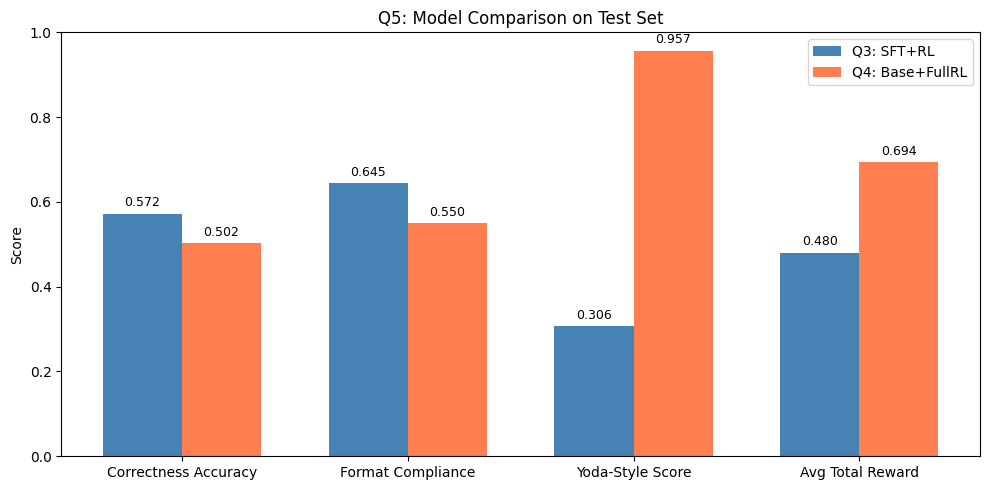

Chart saved ✓


In [ ]:
# ── Step 11: Bar Chart 
metrics = ["Correctness Accuracy", "Format Compliance", "Yoda-Style Score", "Avg Total Reward"]
q3_vals = [df_q3["correctness"].mean(), df_q3["format"].mean(),
           df_q3["style"].mean(),       df_q3["total"].mean()]
q4_vals = [df_q4["correctness"].mean(), df_q4["format"].mean(),
           df_q4["style"].mean(),       df_q4["total"].mean()]

x = range(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar([i - width/2 for i in x], q3_vals, width, label="Q3: SFT+RL", color="steelblue")
bars2 = ax.bar([i + width/2 for i in x], q4_vals, width, label="Q4: Base+FullRL", color="coral")

ax.set_xticks(list(x))
ax.set_xticklabels(metrics)
ax.set_ylabel("Score")
ax.set_title("Q5: Model Comparison on Test Set")
ax.legend()
ax.set_ylim(0, 1.0)

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("q5_comparison_chart.png", dpi=150)
plt.show()
print("Chart saved ✓")

In [ ]:
# ── Step 12: Qualitative Examples (Side-by-Side) 

df_compare = df_q3[["question","gold_answer","response","correctness","format","style","total"]].copy()
df_compare.columns = ["question","gold_answer","q3_response","q3_correct","q3_format","q3_style","q3_total"]
df_compare["q4_response"] = df_q4["response"].values
df_compare["q4_correct"]  = df_q4["correctness"].values
df_compare["q4_format"]   = df_q4["format"].values
df_compare["q4_style"]    = df_q4["style"].values
df_compare["q4_total"]    = df_q4["total"].values


df_sorted = df_compare.sort_values("q4_total", ascending=False)
samples = pd.concat([
    df_sorted.head(2),
    df_sorted.iloc[len(df_sorted)//2:len(df_sorted)//2+1],
    df_sorted.tail(2)
]).reset_index(drop=True)

print("=== Q5 Qualitative Comparison ===")
for i, row in samples.iterrows():
    print(f"\n{'='*70}")
    print(f"Example {i+1}")
    print(f"Question:    {row['question']}")
    print(f"Gold Answer: {row['gold_answer']}")
    print(f"\n[Q3 - SFT+RL]: {row['q3_response']}")
    print(f"  Scores → C:{row['q3_correct']:.3f} | F:{row['q3_format']:.3f} | S:{row['q3_style']:.3f} | Total:{row['q3_total']:.3f}")
    print(f"\n[Q4 - Base+FullRL]: {row['q4_response']}")
    print(f"  Scores → C:{row['q4_correct']:.3f} | F:{row['q4_format']:.3f} | S:{row['q4_style']:.3f} | Total:{row['q4_total']:.3f}")

df_compare.to_csv("q5_qualitative_results.csv", index=False)

=== Q5 Qualitative Comparison ===

Example 1
Question:    who recorded ain't no mountain high enough
Gold Answer: An R&B/soul song, "Ain't No Mountain High Enough" is. Written by Nickolas Ashford & Valerie Simpson in 1966, it was. First successful as a 1967 hit single, recorded by Marvin Gaye and Tammi Terrell, it was. A hit again in 1970, when recorded by Diana Ross, it was. Ross' first solo number-one hit on the Billboard Hot 100 chart, it was. Nominated for a Grammy Award, it was.

[Q3 - SFT+RL]: The song "Ain't No Mountain High Enough" was recorded by Marvin Gaye and Tammi Terrell in 1966. The song was written by Marvin Gaye and Smokey Robinson. The song was recorded by Marvin Gaye and Tammi Terrell in 1966. The song was written by Marvin Gaye and Smokey Robinson. The song was recorded by Marvin Gaye and Tammi Terrell in 1966. The song was written by Marvin Gaye and Smokey Robinson. The song was recorded by Marvin Gaye and Tammi Terrell in 1966. The song was written by Marvin Gaye 

## Q5 Discussion (200 words)

Q4 (Base + Full Reward) outperforms Q3 overall, achieving a higher average total reward (0.694 vs 0.480). The decisive factor is the Yoda-style score (0.957 vs 0.306), confirming that explicitly including style reward during RL training is essential for stylistic learning. Q3 retains higher correctness (0.572 vs 0.502) and format scores (0.645 vs 0.550), indicating that SFT initialisation better preserves factual and structural quality.


Starting from the SFT checkpoint provides a stronger prior for accuracy and formatting. However, it constrains style adaptation during RL, as the already-fixed output distribution limits the style reward's ability to reshape generation behaviour effectively.


Q3's primary failure mode is repetitive generation — identical sentences repeated dozens of times within a single response, a clear sign of reward hacking where the model exploits correctness and format rewards without genuinely improving quality. Q4 occasionally sacrifices factual accuracy for stylistic expression, resulting in lower correctness on knowledge-intensive questions.


Correctness and style were weighted equally (0.4 each) as both are central to producing accurate Yoda-style responses. Format received a lower weight (0.2) as it serves as a baseline quality constraint, preventing over-optimisation of surface formatting at the expense of content and style.

